# Morse Code Decoder - All-in-One Notebook

Object-Oriented Programming, TH Koln (Prof. Dr. Peter Kern).

This notebook contains the complete decoder in one file: audio input, carrier
detection, filtering, element detection, Morse-to-text, the statistical
language model, and both graphical applications.

**This file is generated.** The package under `src/` is the source of truth.
Rebuild with `python scripts/build_notebook.py`. Do not edit the code cells by
hand - the next build overwrites them.

### The signal chain

    audio file -> FrequencyDetector -> SignalProcessor -> MorseDetector
               -> MorseDecoder -> LanguageModel -> text

### What this project does not do

The decoder is signal processing plus a statistical language model. It is not
a neural network, and it reports no confidence score, because a threshold and
a lookup table produce a symbol, not a probability. It decodes recorded
audio files; it is not a streaming receiver, so it reports no latency figure
either.

## 0. Setup

In [1]:
# Set to True and re-run the launcher cells at the bottom to open the GUIs.
# Left False so the whole notebook can run start to finish unattended.
LAUNCH_GUI = False

import os
import io
import sys
import math
import re
import wave
import contextlib
from abc import ABC, abstractmethod
from collections import Counter
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt, hilbert, spectrogram

os.makedirs("audio_samples", exist_ok=True)
print("Python", sys.version.split()[0], "| numpy", np.__version__)

Python 3.12.3 | numpy 2.4.4


# PART 1 - Audio input (Shervin)

From a file or a live device, to a clean on/off envelope ready for decoding.

| Block | Sections | In one sentence |
|---|---|---|
| The Morse alphabet | Morse table | One table, and the reverse built automatically from it |
| Audio input | AudioSource, FileSource, ArraySource, MicrophoneSource, PacedFileSource | One abstract rule, four implementations, and nothing downstream knows which it has |
| Making test audio | Morse audio generator | Text to Morse to sound, so the correct answer is always known |
| Finding the tone | FrequencyDetector | The FFT says which pitch, so the filter knows where to listen |

## 1. Morse table

The single source of truth for character-to-pattern mapping, used by both the decoder and the audio generator.

In [2]:
"""
Single source of truth for the Morse code table.

Used by the decoder (audio -> text). The generator currently has its own
embedded copy; this will be unified in the cleanup phase.
"""

# Forward: character -> Morse code pattern
MORSE_TABLE = {
    'A': '.-',    'B': '-...',  'C': '-.-.',  'D': '-..',   'E': '.',
    'F': '..-.',  'G': '--.',   'H': '....',  'I': '..',    'J': '.---',
    'K': '-.-',   'L': '.-..',  'M': '--',    'N': '-.',    'O': '---',
    'P': '.--.',  'Q': '--.-',  'R': '.-.',   'S': '...',   'T': '-',
    'U': '..-',   'V': '...-',  'W': '.--',   'X': '-..-',  'Y': '-.--',
    'Z': '--..',
    '0': '-----', '1': '.----', '2': '..---', '3': '...--', '4': '....-',
    '5': '.....', '6': '-....', '7': '--...', '8': '---..', '9': '----.',
    '.': '.-.-.-', ',': '--..--', '?': '..--..', '/': '-..-.', '=': '-...-',
}

# Inverse: Morse code pattern -> character
INVERSE_MORSE_TABLE = {code: char for char, code in MORSE_TABLE.items()}

## 2. AudioSource - the input abstraction

An abstract base class. Both input types implement the same four methods, so nothing downstream cares where samples come from.

In [3]:
"""
Abstract base class for audio input sources.

Every audio input must implement this interface
so the rest of the pipeline can consume them uniformly.
"""

from abc import ABC, abstractmethod
import numpy as np


class AudioSource(ABC):
    """Abstract base for audio sources."""

    def __init__(self, sample_rate: int = 44100, chunk_size: int = 1024):
        self.sample_rate = sample_rate
        self.chunk_size = chunk_size
        self._is_running = False

    @abstractmethod
    def start(self) -> None:
        """Open and begin reading from the source."""
        raise NotImplementedError

    @abstractmethod
    def stop(self) -> None:
        """Close the source and release resources."""
        raise NotImplementedError

    @abstractmethod
    def read_chunk(self) -> np.ndarray:
        """
        Read the next chunk of audio samples.

        Returns
        -------
        np.ndarray
            1D array of float32 samples in range [-1.0, 1.0].
        """
        raise NotImplementedError

    @property
    def is_running(self) -> bool:
        return self._is_running

## 3. FileSource

Reads .wav and .mp3 files and hands out fixed-size chunks.

In [4]:
"""
File audio source. Streams audio from .wav or .mp3 files in chunks.
"""

from pathlib import Path
import numpy as np
from scipy.io import wavfile


class FileSource(AudioSource):
    """
    Streams audio from a file in fixed-size chunks.

    .wav files are read via scipy.
    .mp3 (and other compressed formats) are read via soundfile, which uses
    libsndfile and does NOT require ffmpeg.
    """

    def __init__(
        self,
        filepath: str,
        sample_rate: int = 44100,
        chunk_size: int = 1024,
    ):
        super().__init__(sample_rate, chunk_size)
        self.filepath = filepath
        self._position = 0
        self._samples = None

    def start(self) -> None:
        """Load the audio file into memory and prepare for reading."""
        ext = Path(self.filepath).suffix.lower()

        if ext == ".wav":
            rate, data = wavfile.read(self.filepath)
        else:
            # soundfile handles mp3, flac, ogg, etc. via libsndfile (no ffmpeg).
            import soundfile as sf
            data, rate = sf.read(self.filepath)

        data = np.asarray(data)

        # Stereo -> mono
        if data.ndim > 1:
            data = data.mean(axis=1)

        # Normalize to float32 in [-1, 1] based on source dtype
        if data.dtype == np.int16:
            data = data.astype(np.float32) / 32768.0
        elif data.dtype == np.int32:
            data = data.astype(np.float32) / 2147483648.0
        elif data.dtype == np.uint8:
            data = (data.astype(np.float32) - 128.0) / 128.0
        else:
            # soundfile already returns float in [-1, 1]; just ensure float32
            data = data.astype(np.float32)

        self._samples = data
        self.sample_rate = rate
        self._position = 0
        self._is_running = True

    def stop(self) -> None:
        """Release the audio data and reset position."""
        self._is_running = False
        self._position = 0
        self._samples = None

    def read_chunk(self) -> np.ndarray:
        """Return the next chunk of samples. Empty array at EOF."""
        if not self._is_running:
            raise RuntimeError("FileSource not started. Call start() first.")
        if self._samples is None or self._position >= len(self._samples):
            return np.array([], dtype=np.float32)

        end = self._position + self.chunk_size
        chunk = self._samples[self._position:end]
        self._position = end
        return chunk.astype(np.float32)

    @property
    def duration_seconds(self) -> float:
        """Total duration of loaded audio in seconds."""
        if self._samples is None:
            return 0.0
        return len(self._samples) / self.sample_rate

    @property
    def total_samples(self) -> int:
        """Total number of samples in the loaded file."""
        if self._samples is None:
            return 0
        return len(self._samples)

    @property
    def is_finished(self) -> bool:
        """True when all samples have been read."""
        if self._samples is None:
            return True
        return self._position >= len(self._samples)

## 4. ArraySource

The second implementation of the same interface, serving samples that are already in memory. The test suite feeds a generated signal straight into the pipeline through it, with no temporary file on disk. Nothing downstream can tell the two sources apart, which is what the abstract base class is for.

In [5]:
"""
In-memory audio source.

`FileSource` serves samples that live on disk. `ArraySource` serves samples
that are already in memory - a generated test signal, a slice of a longer
recording, or the output of another processing step.

Both are `AudioSource` subclasses, so nothing downstream can tell them apart.
That is the point of the abstract base class: the decoder is written against
the interface, not against a file reader.

The test suite uses this to feed a generated signal straight into the pipeline
without writing a temporary WAV file first.
"""

import numpy as np



class ArraySource(AudioSource):
    """Serve an existing numpy array through the AudioSource interface."""

    def __init__(self, samples: np.ndarray, sample_rate: int = 44100,
                 chunk_size: int = 1024):
        """
        Parameters
        ----------
        samples : np.ndarray
            1D array of float samples, nominally in the range [-1.0, 1.0].
        sample_rate : int
            Sample rate of `samples`, in Hz.
        chunk_size : int
            Number of samples returned per `read_chunk()` call.
        """
        super().__init__(sample_rate=sample_rate, chunk_size=chunk_size)
        self._samples = np.asarray(samples, dtype=np.float32).ravel()
        self._position = 0

    def start(self) -> None:
        """Rewind to the beginning and mark the source as running."""
        self._position = 0
        self._is_running = True

    def stop(self) -> None:
        """Mark the source as stopped. There is nothing to release."""
        self._is_running = False

    def read_chunk(self) -> np.ndarray:
        """
        Return the next `chunk_size` samples.

        Returns a shorter array on the final chunk, and an empty array once
        the data is exhausted - the same contract as FileSource.
        """
        if not self._is_running:
            raise RuntimeError("ArraySource not started. Call start() first.")
        chunk = self._samples[self._position:self._position + self.chunk_size]
        self._position += len(chunk)
        return chunk

    @property
    def duration_seconds(self) -> float:
        """Length of the buffer in seconds."""
        return len(self._samples) / self.sample_rate

    @property
    def total_samples(self) -> int:
        """Number of samples in the buffer."""
        return len(self._samples)

    @property
    def is_finished(self) -> bool:
        """True once every sample has been handed out."""
        return self._position >= len(self._samples)

## 5. MicrophoneSource

The live-input implementation of the same interface. It captures from any recording device the operating system exposes, which includes a virtual audio cable - the path that carries audio from a WebSDR receiver in a browser into this program with no acoustic step and therefore no added noise.

In [6]:
"""
Microphone audio source. Captures live audio via sounddevice.
"""

import queue

import numpy as np


# sounddevice needs the PortAudio system library, which is not present on
# every machine. This class is one of four AudioSource implementations, so a
# missing sound card must not stop a program that only reads files. The
# failure is deferred to the moment capture is actually attempted.
try:
    import sounddevice as sd
    SOUNDDEVICE_AVAILABLE = True
    _IMPORT_ERROR = ""
except Exception as exc:  # pragma: no cover - depends on the host machine
    sd = None
    SOUNDDEVICE_AVAILABLE = False
    _IMPORT_ERROR = str(exc)


def _require_sounddevice() -> None:
    """Raise a clear error if audio capture is not available on this machine."""
    if not SOUNDDEVICE_AVAILABLE:
        raise RuntimeError(
            "Live audio capture is unavailable: " + _IMPORT_ERROR +
            ". Install the sounddevice package and the PortAudio library.")


class MicrophoneSource(AudioSource):
    """
    Captures audio from the system microphone or a virtual audio cable.

    Uses the sounddevice callback API. Each captured block is placed on
    a thread-safe queue and consumed by read_chunk() on the main thread.
    """

    def __init__(
        self,
        sample_rate: int = 44100,
        chunk_size: int = 1024,
        device_id: int = None,
        queue_max_size: int = 100,
        read_timeout: float = 0.0,
    ):
        super().__init__(sample_rate, chunk_size)
        self.device_id = device_id
        # How long read_chunk() waits for data. 0.0 makes it non-blocking,
        # which is what a GUI timer needs; a script can raise it.
        self.read_timeout = read_timeout
        self._queue = queue.Queue(maxsize=queue_max_size)
        self._stream = None

    def _audio_callback(self, indata, frames, time_info, status) -> None:
        """Called by sounddevice on every audio block (runs on its own thread)."""
        if status:
            print(f"Audio callback status: {status}")
        mono = indata[:, 0] if indata.ndim > 1 else indata
        try:
            self._queue.put_nowait(mono.copy())
        except queue.Full:
            pass

    def start(self) -> None:
        """Open the input stream and begin capturing."""
        _require_sounddevice()
        self._stream = sd.InputStream(
            samplerate=self.sample_rate,
            blocksize=self.chunk_size,
            device=self.device_id,
            channels=1,
            dtype="float32",
            callback=self._audio_callback,
        )
        self._stream.start()
        self._is_running = True

    def stop(self) -> None:
        """Close the input stream and drain the queue."""
        if self._stream is not None:
            self._stream.stop()
            self._stream.close()
            self._stream = None
        self._is_running = False
        while not self._queue.empty():
            try:
                self._queue.get_nowait()
            except queue.Empty:
                break

    def read_chunk(self, timeout: float = None) -> np.ndarray:
        """
        Return the next captured chunk, or an empty array if none is ready.

        Takes no required argument, so this matches the AudioSource interface
        and the class can be swapped for any other source. `self.read_timeout`
        controls how long it waits; the default of 0.0 never blocks.
        """
        if not self._is_running:
            raise RuntimeError("MicrophoneSource not started. Call start() first.")
        wait = self.read_timeout if timeout is None else timeout
        try:
            if wait <= 0:
                return self._queue.get_nowait()
            return self._queue.get(timeout=wait)
        except queue.Empty:
            return np.array([], dtype=np.float32)

    @staticmethod
    def list_devices() -> None:
        """Print all available audio devices on this system."""
        _require_sounddevice()
        print(sd.query_devices())

    @staticmethod
    def input_devices() -> list:
        """
        Return [(device_id, name), ...] for every device that can record.

        A virtual audio cable (VB-CABLE, VoiceMeeter) appears here exactly
        like a physical microphone, which is how audio from a WebSDR in the
        browser reaches this program without going through the air.
        """
        _require_sounddevice()
        devices = []
        for index, info in enumerate(sd.query_devices()):
            if info.get("max_input_channels", 0) > 0:
                devices.append((index, info.get("name", f"device {index}")))
        return devices

## 6. PacedFileSource

A file served at the speed the audio actually plays. Ask it for a chunk before the clock has reached it and it returns nothing, exactly as a microphone does. It exists so the streaming decoder can be exercised on a machine with no sound card, and it is the fourth implementation of AudioSource.

In [7]:
"""
Real-time file source.

`FileSource` hands out its samples as fast as they are asked for, which is
right for decoding a recording but wrong for testing a live decoder: the whole
file arrives in milliseconds and nothing is ever "streaming".

`PacedFileSource` releases the same samples at the speed the audio actually
plays. Ask it for a chunk before the audio has caught up and it returns an
empty array, exactly as a microphone does when no new block has been captured
yet.

That makes it a stand-in for a live input:

    source = PacedFileSource("recording.wav")   # behaves like a microphone
    source = MicrophoneSource(device_id=3)      # is a microphone

Both are `AudioSource` subclasses, so `StreamDecoder` and the live window
cannot tell them apart. It is used to test the streaming decoder on a machine
with no sound card, and as a rehearsal path for the live window when no radio
is available.

It does NOT make a file decode "live" in any meaningful sense - the audio is
already known. It exists so the live code path can be exercised.
"""

import time
from pathlib import Path

import numpy as np
from scipy.io import wavfile



class PacedFileSource(AudioSource):
    """Serve a file through the AudioSource interface at real-time speed."""

    def __init__(self, filepath: str, sample_rate: int = 44100,
                 chunk_size: int = 1024, speed: float = 1.0):
        """
        Parameters
        ----------
        filepath : str
            A .wav file, or any format soundfile can read.
        chunk_size : int
            Samples per chunk, matching the live capture block size.
        speed : float
            Playback rate. 1.0 is real time; 2.0 releases audio twice as fast,
            which is useful in tests that should not take a full minute.
        """
        super().__init__(sample_rate, chunk_size)
        self.filepath = filepath
        self.speed = speed
        self._samples = None
        self._position = 0
        self._started_at = None

    def start(self) -> None:
        """Load the file and start the clock."""
        extension = Path(self.filepath).suffix.lower()
        if extension == ".wav":
            rate, data = wavfile.read(self.filepath)
        else:
            import soundfile as sf
            data, rate = sf.read(self.filepath)

        data = np.asarray(data)
        if data.ndim > 1:
            data = data.mean(axis=1)
        if data.dtype == np.int16:
            data = data.astype(np.float32) / 32768.0
        elif data.dtype == np.int32:
            data = data.astype(np.float32) / 2147483648.0
        elif data.dtype == np.uint8:
            data = (data.astype(np.float32) - 128.0) / 128.0
        else:
            data = data.astype(np.float32)

        self._samples = data
        self.sample_rate = rate
        self._position = 0
        self._started_at = time.time()
        self._is_running = True

    def stop(self) -> None:
        """Stop serving samples."""
        self._is_running = False
        self._position = 0
        self._samples = None
        self._started_at = None

    def read_chunk(self) -> np.ndarray:
        """
        Return the next chunk if the clock has reached it, else an empty array.

        Never blocks, so a GUI timer can call it freely.
        """
        if not self._is_running:
            raise RuntimeError("PacedFileSource not started. Call start() first.")
        if self._samples is None or self._position >= len(self._samples):
            return np.array([], dtype=np.float32)

        elapsed = (time.time() - self._started_at) * self.speed
        released = int(elapsed * self.sample_rate)
        if released <= self._position:
            return np.array([], dtype=np.float32)

        end = min(self._position + self.chunk_size, released, len(self._samples))
        chunk = self._samples[self._position:end]
        self._position = end
        return chunk.astype(np.float32)

    @property
    def duration_seconds(self) -> float:
        if self._samples is None:
            return 0.0
        return len(self._samples) / self.sample_rate

    @property
    def total_samples(self) -> int:
        return 0 if self._samples is None else len(self._samples)

    @property
    def is_finished(self) -> bool:
        if self._samples is None:
            return True
        return self._position >= len(self._samples)

## 7. Morse audio generator

Turns text into a clean CW tone. Used to build test material with a known correct answer, which is what makes the accuracy tests below meaningful.

In [8]:
"""
Generate Morse code audio from text and save as a WAV file.

Uses standard PARIS timing:
- 1 unit = 60 / (50 * WPM) seconds
- dit = 1 unit
- dah = 3 units
- intra-letter gap = 1 unit
- inter-letter gap = 3 units
- inter-word gap = 7 units

A short cosine ramp at each tone edge avoids audible clicks.
"""

import os
import numpy as np
from scipy.io import wavfile


MORSE_TABLE = {
    'A': '.-',    'B': '-...',  'C': '-.-.',  'D': '-..',   'E': '.',
    'F': '..-.',  'G': '--.',   'H': '....',  'I': '..',    'J': '.---',
    'K': '-.-',   'L': '.-..',  'M': '--',    'N': '-.',    'O': '---',
    'P': '.--.',  'Q': '--.-',  'R': '.-.',   'S': '...',   'T': '-',
    'U': '..-',   'V': '...-',  'W': '.--',   'X': '-..-',  'Y': '-.--',
    'Z': '--..',
    '0': '-----', '1': '.----', '2': '..---', '3': '...--', '4': '....-',
    '5': '.....', '6': '-....', '7': '--...', '8': '---..', '9': '----.',
    '.': '.-.-.-', ',': '--..--', '?': '..--..', '/': '-..-.', '=': '-...-',
}


def text_to_morse(text: str) -> str:
    """Convert text to a readable Morse string ('.', '-', ' ' between letters, '/' between words)."""
    text = text.upper()
    words = text.split()
    encoded_words = []
    for word in words:
        letters = [MORSE_TABLE[ch] for ch in word if ch in MORSE_TABLE]
        encoded_words.append(' '.join(letters))
    return ' / '.join(encoded_words)


def _generate_tone(num_samples: int, frequency: float, sample_rate: int, amplitude: float) -> np.ndarray:
    """Generate a sine-wave burst with short cosine ramps at start and end."""
    t = np.arange(num_samples) / sample_rate
    wave = amplitude * np.sin(2 * np.pi * frequency * t)

    ramp_samples = min(int(0.005 * sample_rate), num_samples // 4)
    if ramp_samples > 0:
        ramp = 0.5 * (1 - np.cos(np.pi * np.arange(ramp_samples) / ramp_samples))
        wave[:ramp_samples] *= ramp
        wave[-ramp_samples:] *= ramp[::-1]

    return wave.astype(np.float32)


def generate_morse_audio(
    text: str,
    output_path: str = "audio_samples/morse_hello_world.wav",
    wpm: int = 20,
    frequency: float = 700.0,
    sample_rate: int = 44100,
    amplitude: float = 0.5,
) -> None:
    """Generate Morse-code audio from text and save it as a 16-bit PCM WAV file."""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    unit_seconds = 60.0 / (50.0 * wpm)
    unit_samples = int(sample_rate * unit_seconds)

    dit_tone = _generate_tone(unit_samples, frequency, sample_rate, amplitude)
    dah_tone = _generate_tone(unit_samples * 3, frequency, sample_rate, amplitude)
    intra_letter_gap = np.zeros(unit_samples, dtype=np.float32)
    inter_letter_gap = np.zeros(unit_samples * 3, dtype=np.float32)
    inter_word_gap = np.zeros(unit_samples * 7, dtype=np.float32)

    text_clean = text.upper()
    words = text_clean.split()

    pieces = []
    for w_idx, word in enumerate(words):
        if w_idx > 0:
            pieces.append(inter_word_gap)
        letters = [ch for ch in word if ch in MORSE_TABLE]
        for l_idx, letter in enumerate(letters):
            if l_idx > 0:
                pieces.append(inter_letter_gap)
            code = MORSE_TABLE[letter]
            for e_idx, element in enumerate(code):
                if e_idx > 0:
                    pieces.append(intra_letter_gap)
                if element == '.':
                    pieces.append(dit_tone)
                else:
                    pieces.append(dah_tone)

    audio = np.concatenate(pieces) if pieces else np.zeros(0, dtype=np.float32)

    pcm = (audio * 32767).astype(np.int16)
    wavfile.write(output_path, sample_rate, pcm)

    duration = len(audio) / sample_rate
    print(f"Text:      {text}")
    print(f"Morse:     {text_to_morse(text)}")
    print(f"WPM:       {wpm}")
    print(f"Frequency: {frequency} Hz")
    print(f"Duration:  {duration:.2f} s")
    print(f"Saved to:  {output_path}")

## 8. FrequencyDetector

Finds the carrier tone by taking an FFT of the whole recording and picking the dominant bin. This is what lets the decoder work without being told the tone frequency in advance.

In [9]:
"""
Carrier frequency detection for Morse signals.

Before bandpass filtering, we need to know WHERE the Morse tone is in the
frequency spectrum. A hardcoded assumption (e.g. 700 Hz) fails on real-world
audio that may use any tone. This class finds the dominant frequency using
an FFT, so the bandpass filter can be tuned to the actual signal.
"""

import numpy as np


class FrequencyDetector:
    """Detect the dominant (carrier) frequency of an audio signal via FFT."""

    def __init__(
        self,
        sample_rate: int = 44100,
        min_freq: float = 100.0,
        max_freq: float = 3000.0,
    ):
        """
        Parameters
        ----------
        sample_rate : int
            Audio sample rate in Hz.
        min_freq : float
            Lowest frequency to consider as a possible carrier (Hz).
            Rejects low-frequency hum and DC offset.
        max_freq : float
            Highest frequency to consider (Hz). Rejects high-frequency hiss.
        """
        self.sample_rate = sample_rate
        self.min_freq = min_freq
        self.max_freq = max_freq

    def detect(self, signal: np.ndarray) -> float:
        """
        Find the dominant frequency in the signal.

        Computes the magnitude spectrum via FFT, restricts to the plausible
        Morse frequency band [min_freq, max_freq], and returns the frequency
        with the most energy.

        Returns
        -------
        float
            The dominant frequency in Hz. Returns 0.0 for a silent signal.
        """
        if len(signal) == 0 or np.max(np.abs(signal)) < 1e-6:
            return 0.0

        # Real FFT: magnitude spectrum of the signal
        spectrum = np.abs(np.fft.rfft(signal))
        freqs = np.fft.rfftfreq(len(signal), d=1.0 / self.sample_rate)

        # Restrict to the plausible Morse carrier band
        band_mask = (freqs >= self.min_freq) & (freqs <= self.max_freq)
        if not np.any(band_mask):
            return 0.0

        band_spectrum = spectrum[band_mask]
        band_freqs = freqs[band_mask]

        # The frequency with the most energy is the carrier
        peak_index = int(np.argmax(band_spectrum))
        return float(band_freqs[peak_index])

    def get_spectrum(self, signal: np.ndarray) -> tuple:
        """
        Return the full magnitude spectrum for plotting/visualization.

        Returns
        -------
        (freqs, magnitudes) : tuple of np.ndarray
            Frequencies in Hz and their corresponding magnitudes.
        """
        if len(signal) == 0:
            return np.array([]), np.array([])
        spectrum = np.abs(np.fft.rfft(signal))
        freqs = np.fft.rfftfreq(len(signal), d=1.0 / self.sample_rate)
        return freqs, spectrum

## 9. SignalProcessor

Bandpass filter around the carrier, then a Hilbert-transform envelope, then smoothing. The envelope is the on/off pattern the detector reads.

In [10]:
"""
Signal processing for the Morse decoder.

Applies a bandpass filter to isolate the CW (continuous wave) tone
from background noise, then extracts the envelope (amplitude over time)
which reveals the on/off pattern of the Morse code.
"""

import numpy as np
from scipy.signal import butter, sosfiltfilt, hilbert


class SignalProcessor:
    """Bandpass filter + envelope detection for CW Morse signals."""

    def __init__(
        self,
        sample_rate: int = 44100,
        center_frequency: float = 700.0,
        bandwidth: float = 200.0,
        filter_order: int = 4,
        smoothing_ms: float = 20.0,
    ):
        """
        Parameters
        ----------
        sample_rate : int
            Audio sample rate in Hz.
        center_frequency : float
            Center of the bandpass filter, in Hz. Default 700.
        bandwidth : float
            Width of the passband in Hz. Default 200 (so 600-800 Hz).
        filter_order : int
            Butterworth filter order. Higher = sharper but more compute.
        smoothing_ms : float
            Moving-average window length for the envelope, in milliseconds.
        """
        self.sample_rate = sample_rate
        self.center_frequency = center_frequency
        self.bandwidth = bandwidth
        self.filter_order = filter_order
        self.smoothing_ms = smoothing_ms
        self._sos = self._design_bandpass()

    def _design_bandpass(self):
        """Design the Butterworth bandpass filter as second-order sections."""
        nyquist = self.sample_rate / 2.0
        low = (self.center_frequency - self.bandwidth / 2.0) / nyquist
        high = (self.center_frequency + self.bandwidth / 2.0) / nyquist
        return butter(self.filter_order, [low, high], btype="band", output="sos")
    
    def set_center_frequency(self, center_frequency: float) -> None:
        """Retune the bandpass filter to a new center frequency."""
        self.center_frequency = center_frequency
        self._sos = self._design_bandpass()

    def bandpass(self, signal: np.ndarray) -> np.ndarray:
        """Apply zero-phase bandpass filter around the CW frequency."""
        return sosfiltfilt(self._sos, signal)

    def envelope(self, signal: np.ndarray) -> np.ndarray:
        """Extract envelope via Hilbert transform (amplitude over time)."""
        analytic = hilbert(signal)
        return np.abs(analytic)

    def smooth(self, envelope: np.ndarray) -> np.ndarray:
        """Smooth the envelope with a moving-average window."""
        window_samples = max(1, int(self.smoothing_ms * self.sample_rate / 1000.0))
        kernel = np.ones(window_samples) / window_samples
        return np.convolve(envelope, kernel, mode="same")

    def process(self, signal: np.ndarray) -> np.ndarray:
        """Full chain: bandpass -> envelope -> smooth. Returns the smoothed envelope."""
        filtered = self.bandpass(signal)
        env = self.envelope(filtered)
        return self.smooth(env)

# PART 2 - Signal to text (Hanna)

From an envelope to readable characters, at any speed between 10 and 40 WPM.

| Block | Sections | In one sentence |
|---|---|---|
| Cleaning the signal | SignalProcessor | Bandpass filter, then envelope, then smoothing |
| Envelope to elements | MorseDetector | Threshold, run lengths, and finding the dit by the largest gap in the sorted durations |
| Elements to text | MorseDecoder | Table lookup; a pattern that matches nothing becomes `?` |
| Any speed, 10 to 40 WPM | Adaptive decoding | Two passes: measure the speed first, then decode with a window scaled to it |

Hanna also presents the verification and the limits, in Part 4.

## 10. MorseDetector

Thresholds the envelope, measures run lengths, estimates the dit length from the largest gap in the sorted durations, and classifies every element and gap. Speed in words per minute falls out of the measured dit length.

In [11]:
"""
Morse element detector.

Takes a smoothed envelope (from SignalProcessor) and converts it to a
Morse code string of dits ('.'), dahs ('-'), and gaps (' ', '   ').
"""

import numpy as np


class MorseDetector:
    """Detect Morse elements from a smoothed envelope signal."""

    def __init__(
        self,
        sample_rate: int = 44100,
        threshold_ratio: float = 0.3,
        dah_threshold: float = 2.0,
        letter_gap_threshold: float = 2.0,
        word_gap_threshold: float = 5.0,
    ):
        """
        Parameters
        ----------
        sample_rate : int
            Audio sample rate in Hz.
        threshold_ratio : float
            Fraction of envelope peak above which the signal is considered "on".
        dah_threshold : float
            On-period multiple of dit length above which it's classified as a dah.
        letter_gap_threshold : float
            Gap-period multiple of dit length above which it's a letter boundary.
        word_gap_threshold : float
            Gap-period multiple of dit length above which it's a word boundary.
        """
        self.sample_rate = sample_rate
        self.threshold_ratio = threshold_ratio
        self.dah_threshold = dah_threshold
        self.letter_gap_threshold = letter_gap_threshold
        self.word_gap_threshold = word_gap_threshold
        self.dit_samples = None
        self.estimated_wpm = None

    def detect(self, envelope: np.ndarray) -> str:
        """
        Convert smoothed envelope into Morse string.

        Letter boundary = single space. Word boundary = three spaces.

        Example output: ".... . .-.. .-.. ---   .-- --- .-. .-.. -.."

        Returns empty string if signal is silent.
        """
        if len(envelope) == 0 or np.max(envelope) < 1e-6:
            return ""

        # 1. Threshold to binary on/off
        threshold = self.threshold_ratio * np.max(envelope)
        binary = (envelope > threshold).astype(np.int8)

        # 2. Extract run lengths
        on_durations, gap_durations = self._extract_runs(binary)
        if len(on_durations) == 0:
            return ""

        # 3. Estimate dit length and WPM
        self.dit_samples = self._estimate_dit_length(on_durations)
        self.estimated_wpm = self._dit_samples_to_wpm(self.dit_samples)

        # 4. Classify each element and gap
        result = []
        for i, on_dur in enumerate(on_durations):
            if on_dur < self.dah_threshold * self.dit_samples:
                result.append(".")
            else:
                result.append("-")

            if i < len(gap_durations):
                gap = gap_durations[i]
                if gap < self.letter_gap_threshold * self.dit_samples:
                    pass  # intra-letter gap, no separator
                elif gap < self.word_gap_threshold * self.dit_samples:
                    result.append(" ")
                else:
                    result.append("   ")

        return "".join(result)

    def _extract_runs(self, binary: np.ndarray) -> tuple:
        """Extract durations of consecutive 1s (on) and 0s between them (gap)."""
        on_durations = []
        gap_durations = []
        n = len(binary)
        i = 0

        # Skip leading zeros
        while i < n and binary[i] == 0:
            i += 1

        while i < n:
            # Measure an "on" run
            start = i
            while i < n and binary[i] == 1:
                i += 1
            on_durations.append(i - start)

            # Measure the gap that follows (only if there is another "on" after)
            start = i
            while i < n and binary[i] == 0:
                i += 1
            if i < n:
                gap_durations.append(i - start)

        return on_durations, gap_durations

    def _estimate_dit_length(self, on_durations: list) -> int:
        """
        Estimate dit length by sorting on-durations and finding the largest jump.

        Dits cluster around one length, dahs around 3x that length.
        The biggest gap in sorted values separates them.
        """
        durations = np.array(on_durations)
        if len(durations) == 1:
            return int(durations[0])

        sorted_durs = np.sort(durations)
        gaps = np.diff(sorted_durs)
        split_idx = int(np.argmax(gaps))

        dit_group = sorted_durs[:split_idx + 1]
        return int(np.mean(dit_group))

    def _dit_samples_to_wpm(self, dit_samples: int) -> float:
        """Convert dit length in samples to WPM."""
        if dit_samples == 0:
            return 0.0
        dit_seconds = dit_samples / self.sample_rate
        return 60.0 / (50.0 * dit_seconds)

## 11. MorseDecoder

Pattern to character, via the inverse table.

In [12]:
"""
Morse code decoder.

Converts a Morse string (dits, dahs, and gaps) into readable text using
a lookup table.
"""



class MorseDecoder:
    """Convert a Morse-code string to text via lookup table."""

    def __init__(self, unknown_marker: str = "?"):
        """
        Parameters
        ----------
        unknown_marker : str
            Character inserted when an unrecognized Morse pattern is encountered.
        """
        self.unknown_marker = unknown_marker

    def decode(self, morse: str) -> str:
        """
        Decode a Morse string into text.

        Input format:
            - '.' = dit, '-' = dah
            - single space between letters within a word
            - triple space between words

        Example:
            input:  ".... . .-.. .-.. ---   .-- --- .-. .-.. -.."
            output: "HELLO WORLD"

        Unknown patterns become `self.unknown_marker`.
        """
        if not morse:
            return ""

        words = morse.split("   ")
        decoded_words = []
        for word in words:
            letters = word.split(" ")
            decoded_letters = []
            for letter in letters:
                if not letter:
                    continue
                decoded_letters.append(
                    INVERSE_MORSE_TABLE.get(letter, self.unknown_marker)
                )
            decoded_words.append("".join(decoded_letters))

        return " ".join(decoded_words)

## 12. Adaptive decoding

A first pass estimates the dit length, which sets the smoothing window for a second pass. This is what makes one decoder work across 10 to 40 words per minute instead of needing a hand-tuned constant.

In [13]:
"""
Adaptive decoding helper.

Problem this solves
-------------------
The envelope smoothing window is a compromise. A wide window rejects noise but
blurs fast Morse; a narrow window preserves fast Morse but lets noise through.
A single fixed value cannot be right for both 10 WPM (dit = 120 ms) and
40 WPM (dit = 30 ms).

Solution: two passes.
  1. Process once with a moderate window to get a rough estimate of the dit
     length (and therefore the speed).
  2. Choose a smoothing window proportional to that dit (about one quarter of
     it), then re-process and decode with the tuned window.

Measured effect across 10-40 WPM: the reported WPM error drops from roughly
10% at high speeds to under 7% across the whole range, with no loss of noise
immunity, and every speed still decodes exactly.

This uses only the public API of SignalProcessor and MorseDetector.
"""

from dataclasses import dataclass

import numpy as np



# Pass 1 uses this moderate window purely to estimate the dit length.
BOOTSTRAP_SMOOTHING_MS = 15.0

# Pass 2 window = dit_duration / DIT_DIVISOR, clamped to [MIN_MS, MAX_MS].
DIT_DIVISOR = 4.0
MIN_SMOOTHING_MS = 5.0
MAX_SMOOTHING_MS = 30.0


@dataclass
class DecodeResult:
    """Everything the pipeline produced, for display or testing."""
    carrier_hz: float
    smoothing_ms: float
    envelope: np.ndarray
    morse: str
    text: str
    estimated_wpm: float


def adaptive_smoothing_ms(dit_samples: int, sample_rate: int) -> float:
    """Choose a smoothing window proportional to the dit length."""
    if not dit_samples:
        return BOOTSTRAP_SMOOTHING_MS
    dit_ms = dit_samples / sample_rate * 1000.0
    return float(np.clip(dit_ms / DIT_DIVISOR, MIN_SMOOTHING_MS, MAX_SMOOTHING_MS))

# ---------------------------------------------------------------------------
# A known limit on the reported speed
# ---------------------------------------------------------------------------
# WPM is derived from the measured dit length, and that measurement carries a
# bias that depends on the transmitter, not on this code.
#
# Two effects change the width of every element, and they pull opposite ways:
#
#   * The envelope smoothing turns each edge into a ramp. Measuring below half
#     height then reads every element LONGER than it is, by about
#     W * (1 - 2t) samples for a window W at threshold t. The window is
#     proportional to the dit, so this inflates the dit by roughly 10% at any
#     speed, which reads about 9% SLOW.
#
#   * The transmitter's own keying ramp reads every element SHORTER, by an
#     amount set by its rise time, which is unknown to us.
#
# On the audio this project generates, the two nearly cancel: measured error is
# a few percent. On a sharply keyed off-air recording the first effect
# dominates and the speed reads about 9% low - a 25 WPM transmission is
# reported as roughly 23.
#
# Measuring at half amplitude removes the first effect exactly, because
# W * (1 - 2t) is zero at t = 0.5. It cannot remove the second: separating the
# transmitter's rise time from our own smoothing is not possible once the
# envelope has been smoothed, since the smoothing window is several times wider
# than a typical keying ramp.
#
# This affects the REPORTED SPEED ONLY. The decoder compares durations against
# multiples of the dit - two for a dah, five for a word gap - and a
# proportional error in the dit cancels out of those ratios. That is why text
# decodes correctly even when the speed reads a few percent low.





def decode_adaptive(audio: np.ndarray, sample_rate: int,
                    center_frequency: float = None) -> DecodeResult:
    """
    Decode audio using two-pass adaptive smoothing.

    Args:
        audio: mono float samples.
        sample_rate: samples per second.
        center_frequency: carrier in Hz. Detected automatically if None.

    Returns:
        DecodeResult with the carrier, chosen smoothing, envelope, Morse
        string, decoded text, and estimated WPM.
    """
    if center_frequency is None:
        center_frequency = FrequencyDetector(sample_rate=sample_rate).detect(audio)

    # --- Pass 1: rough dit estimate with a moderate window ---
    bootstrap = SignalProcessor(sample_rate=sample_rate,
                                center_frequency=center_frequency,
                                smoothing_ms=BOOTSTRAP_SMOOTHING_MS)
    env1 = bootstrap.process(audio)
    det1 = MorseDetector(sample_rate=sample_rate)
    det1.detect(env1)
    dit1 = getattr(det1, "dit_samples", None)

    smoothing = adaptive_smoothing_ms(dit1, sample_rate)

    # --- Pass 2: decode with the tuned window ---
    processor = SignalProcessor(sample_rate=sample_rate,
                                center_frequency=center_frequency,
                                smoothing_ms=smoothing)
    envelope = processor.process(audio)
    detector = MorseDetector(sample_rate=sample_rate)
    morse = detector.detect(envelope)
    text = MorseDecoder().decode(morse)
    wpm = detector.estimated_wpm if detector.estimated_wpm else 0.0

    return DecodeResult(carrier_hz=float(center_frequency),
                        smoothing_ms=float(smoothing),
                        envelope=envelope,
                        morse=morse,
                        text=text,
                        estimated_wpm=float(wpm))

# PART 3 - Model, streaming and display (Mayank)

Correcting what the decoder got wrong, decoding audio that has not finished
arriving, and putting it on screen.

| Block | Sections | In one sentence |
|---|---|---|
| The language model | Vocabulary, LanguageModel | Character n-grams (n = 3) plus a weighted edit distance over about 4917 words |
| One pipeline | The unified pipeline | Every application and every test calls the same function |
| Timing | Element and character timing | When each element and each character starts and ends |
| Live streaming | StreamDecoder | A rolling window re-decoded several times a second, and why half a second of latency is unavoidable |
| Visualisation | Visualizer | The project's second abstract base class, with three views |

## 13. Vocabulary for the language model

About 4900 common English words plus amateur-radio terms. Frozen in the repository, so nothing is downloaded at run time.

In [14]:
"""Bundled common English words for the Morse language model.

Frozen list of the most common English words (uppercased), used by
LanguageModel for word-level error correction. No runtime download needed.
"""

COMMON_WORDS = [
    'THE', 'TO', 'AND', 'OF', 'IN', 'IS', 'FOR', 'THAT', 'YOU', 'IT', 'ON', 'WITH',
    'THIS', 'WAS', 'BE', 'AS', 'ARE', 'HAVE', 'AT', 'HE', 'NOT', 'BY', 'BUT', 'FROM',
    'MY', 'OR', 'WE', 'AN', 'YOUR', 'ALL', 'SO', 'HIS', 'THEY', 'ME', 'IF', 'ONE',
    'CAN', 'WILL', 'JUST', 'LIKE', 'ABOUT', 'UP', 'OUT', 'WHAT', 'HAS', 'WHEN', 'MORE', 'DO',
    'NO', 'WERE', 'WHO', 'HAD', 'THEIR', 'THERE', 'HER', 'WHICH', 'TIME', 'GET', 'BEEN', 'WOULD',
    'SHE', 'NEW', 'PEOPLE', 'HOW', 'SOME', 'ALSO', 'THEM', 'NOW', 'OTHER', 'ITS', 'OUR', 'THAN',
    'GOOD', 'ONLY', 'AFTER', 'FIRST', 'HIM', 'INTO', 'KNOW', 'SEE', 'TWO', 'MAKE', 'OVER', 'THINK',
    'ANY', 'THEN', 'COULD', 'BACK', 'THESE', 'US', 'WANT', 'BECAUSE', 'GO', 'WELL', 'SAID', 'WAY',
    'MOST', 'MUCH', 'VERY', 'WHERE', 'EVEN', 'SHOULD', 'MAY', 'HERE', 'NEED', 'REALLY', 'DID', 'RIGHT',
    'WORK', 'YEAR', 'YEARS', 'BEING', 'DAY', 'TOO', 'GOING', 'BEFORE', 'OFF', 'WHY', 'MADE', 'STILL',
    'TAKE', 'GOT', 'MANY', 'NEVER', 'THOSE', 'LIFE', 'SAY', 'WORLD', 'DOWN', 'GREAT', 'THROUGH', 'LAST',
    'WHILE', 'BEST', 'SUCH', 'LOVE', 'MAN', 'HOME', 'LONG', 'LOOK', 'SOMETHING', 'USE', 'SAME', 'USED',
    'BOTH', 'EVERY', 'AM', 'COME', 'PART', 'STATE', 'THREE', 'AROUND', 'BETWEEN', 'ALWAYS', 'BETTER', 'FIND',
    'HELP', 'HIGH', 'LITTLE', 'OLD', 'SINCE', 'ANOTHER', 'DOES', 'OWN', 'THINGS', 'UNDER', 'DURING', 'GAME',
    'THING', 'GIVE', 'HOUSE', 'PLACE', 'SCHOOL', 'AGAIN', 'NEXT', 'EACH', 'MR', 'WITHOUT', 'AGAINST', 'END',
    'FOUND', 'MUST', 'SHOW', 'BIG', 'FEEL', 'SURE', 'TEAM', 'EVER', 'FAMILY', 'KEEP', 'MIGHT', 'PLEASE',
    'PUT', 'MONEY', 'FREE', 'SECOND', 'SOMEONE', 'AWAY', 'LEFT', 'NUMBER', 'CITY', 'DAYS', 'LOT', 'NAME',
    'NIGHT', 'PLAY', 'UNTIL', 'COMPANY', 'DOING', 'FEW', 'LET', 'REAL', 'CALLED', 'DIFFERENT', 'HAVING', 'SET',
    'THOUGHT', 'DONE', 'HOWEVER', 'GETTING', 'GOD', 'GOVERNMENT', 'GROUP', 'LOOKING', 'PUBLIC', 'TOP', 'WOMEN', 'BUSINESS',
    'CARE', 'START', 'SYSTEM', 'TIMES', 'WEEK', 'ALREADY', 'ANYTHING', 'CASE', 'NOTHING', 'PERSON', 'TODAY', 'CHANGE',
    'ENOUGH', 'EVERYTHING', 'FULL', 'LIVE', 'MAKING', 'POINT', 'READ', 'TOLD', 'YET', 'BAD', 'FOUR', 'HARD',
    'MEAN', 'ONCE', 'SUPPORT', 'TELL', 'INCLUDING', 'MUSIC', 'POWER', 'SEEN', 'STATES', 'STOP', 'WATER', 'BASED',
    'BELIEVE', 'CALL', 'HEAD', 'MEN', 'NATIONAL', 'SMALL', 'TOOK', 'WHITE', 'CAME', 'FAR', 'JOB', 'SIDE',
    'THOUGH', 'TRY', 'WENT', 'YES', 'ACTUALLY', 'AMERICAN', 'LATER', 'LESS', 'LINE', 'ORDER', 'PARTY', 'RUN',
    'SAYS', 'SERVICE', 'COUNTRY', 'OPEN', 'SEASON', 'THANK', 'CHILDREN', 'EVERYONE', 'GENERAL', 'TRYING', 'UNITED', 'USING',
    'AREA', 'BLACK', 'FOLLOWING', 'LAW', 'MAKES', 'TOGETHER', 'WAR', 'WHOLE', 'CAR', 'FACE', 'FIVE', 'KIND',
    'MAYBE', 'PER', 'PRESIDENT', 'STORY', 'WORKING', 'COURSE', 'GAMES', 'HEALTH', 'HOPE', 'IMPORTANT', 'LEAST', 'MEANS',
    'NEWS', 'WITHIN', 'ABLE', 'BOOK', 'EARLY', 'FRIENDS', 'INFORMATION', 'LOCAL', 'OH', 'POST', 'THANKS', 'VIDEO',
    'YOUNG', 'AGO', 'OTHERS', 'SOCIAL', 'TALK', 'COURT', 'FACT', 'GIVEN', 'GUYS', 'HALF', 'HAND', 'LEVEL',
    'MIND', 'OFTEN', 'SINGLE', 'BECOME', 'BODY', 'COMING', 'CONTROL', 'DEATH', 'FOOD', 'GUY', 'HOURS', 'OFFICE',
    'PAY', 'PROBLEM', 'SOUTH', 'TRUE', 'ALMOST', 'HISTORY', 'KNOWN', 'LARGE', 'LOST', 'RESEARCH', 'ROOM', 'SEVERAL',
    'STARTED', 'TAKING', 'UNIVERSITY', 'WIN', 'WRONG', 'ALONG', 'ANYONE', 'ELSE', 'GIRL', 'JOHN', 'MATTER', 'PRETTY',
    'REMEMBER', 'AIR', 'BIT', 'FRIEND', 'HIT', 'NEEDS', 'NICE', 'PLAYING', 'PROBABLY', 'SAYING', 'UNDERSTAND', 'YEAH',
    'YORK', 'CLASS', 'CLOSE', 'COMES', 'IDEA', 'INTERNATIONAL', 'LOOKS', 'PAST', 'POSSIBLE', 'WANTED', 'CAUSE', 'DUE',
    'HAPPY', 'HUMAN', 'MEMBERS', 'MONTHS', 'MOVE', 'QUESTION', 'SERIES', 'WAIT', 'WOMAN', 'ASK', 'COMMUNITY', 'DATA',
    'LATE', 'LEAVE', 'NORTH', 'SAW', 'SPECIAL', 'WATCH', 'EITHER', 'FUCKING', 'FUTURE', 'LIGHT', 'LOW', 'MILLION',
    'MORNING', 'POLICE', 'SHORT', 'STAY', 'TAKEN', 'AGE', 'BUY', 'DEAL', 'RATHER', 'REASON', 'RED', 'REPORT',
    'SOON', 'THIRD', 'TURN', 'WHETHER', 'AMONG', 'CHECK', 'DEVELOPMENT', 'FORM', 'FURTHER', 'HEART', 'MINUTES', 'MYSELF',
    'SERVICES', 'YOURSELF', 'ACT', 'ALTHOUGH', 'ASKED', 'CHILD', 'FIRE', 'FUN', 'LIVING', 'MAJOR', 'MEDIA', 'PHONE',
    'PLAYERS', 'ART', 'BEHIND', 'BUILDING', 'EASY', 'GONNA', 'MARKET', 'NEAR', 'NON', 'PLAN', 'POLITICAL', 'QUITE',
    'SIX', 'TALKING', 'WEST', 'WORKS', 'ACCORDING', 'AVAILABLE', 'EDUCATION', 'FINAL', 'FORMER', 'FRONT', 'KIDS', 'LIST',
    'READY', 'SOMETIMES', 'SON', 'STREET', 'BRING', 'COLLEGE', 'CURRENT', 'EXAMPLE', 'EXPERIENCE', 'HEARD', 'LONDON', 'MEET',
    'PROGRAM', 'TYPE', 'BABY', 'CHANCE', 'FATHER', 'MARCH', 'PROCESS', 'SONG', 'STUDY', 'WORD', 'ACROSS', 'ACTION',
    'CLEAR', 'GAVE', 'GETS', 'HIMSELF', 'MONTH', 'OUTSIDE', 'SELF', 'STUDENTS', 'WORDS', 'BOARD', 'COST', 'CUT',
    'DR', 'FIELD', 'HELD', 'INSTEAD', 'MAIN', 'MOMENT', 'MOTHER', 'ROAD', 'SEEMS', 'THINKING', 'TOWN', 'WANTS',
    'DE', 'DEPARTMENT', 'ENERGY', 'FIGHT', 'FINE', 'FORCE', 'HEAR', 'ISSUE', 'PLAYED', 'POINTS', 'PRICE', 'RE',
    'REST', 'RESULTS', 'RUNNING', 'SHOWS', 'SPACE', 'SUMMER', 'TERM', 'WIFE', 'AMERICA', 'BEAUTIFUL', 'DATE', 'GOES',
    'KILLED', 'LAND', 'MISS', 'PROJECT', 'SHOT', 'SITE', 'STRONG', 'ACCOUNT', 'CO', 'ESPECIALLY', 'EYES', 'INCLUDE',
    'JUNE', 'PARENTS', 'PERIOD', 'POSITION', 'RECORD', 'SIMILAR', 'TOTAL', 'ABOVE', 'CLUB', 'COMMON', 'DIED', 'FILM',
    'HAPPENED', 'KNEW', 'LEAD', 'LIKELY', 'MILITARY', 'PERFECT', 'PERSONAL', 'SECURITY', 'SHARE', 'ST', 'TV', 'WON',
    'APRIL', 'CENTER', 'COUNTY', 'COUPLE', 'DEAD', 'ENGLISH', 'HAPPEN', 'HOLD', 'INDUSTRY', 'INSIDE', 'ISSUES', 'ONLINE',
    'PLAYER', 'PRIVATE', 'PROBLEMS', 'RETURN', 'RIGHTS', 'SENSE', 'STAR', 'TEST', 'VIEW', 'WEEKS', 'BREAK', 'BRITISH',
    'COMPANIES', 'EVENT', 'HIGHER', 'HOUR', 'MEMBER', 'MIDDLE', 'NEEDED', 'PRESENT', 'RESULT', 'SORRY', 'TAKES', 'TRAINING',
    'WISH', 'ANSWER', 'BOY', 'DESIGN', 'FINALLY', 'GIRLS', 'GOLD', 'GONE', 'GUESS', 'INTEREST', 'JULY', 'KING',
    'LEARN', 'POLICY', 'SOCIETY', 'ADDED', 'AL', 'ALONE', 'AVERAGE', 'BANK', 'BROUGHT', 'CERTAIN', 'CHURCH', 'EAST',
    'HANDS', 'HOT', 'LONGER', 'MEDICAL', 'MOVIE', 'ORIGINAL', 'PARK', 'PERFORMANCE', 'PRESS', 'RECEIVED', 'ROLE', 'SENT',
    'THEMSELVES', 'TRIED', 'WORKED', 'WORTH', 'AREAS', 'BECAME', 'BILL', 'BOOKS', 'COOL', 'DIRECTOR', 'EXACTLY', 'GIVING',
    'GROUND', 'MEETING', 'PROVIDE', 'QUESTIONS', 'RELATIONSHIP', 'SEPTEMBER', 'SOUND', 'SOURCE', 'USUALLY', 'VALUE', 'EVIDENCE', 'FOLLOW',
    'LIVES', 'OFFICIAL', 'OK', 'PRODUCTION', 'RATE', 'READING', 'ROUND', 'SAVE', 'STAND', 'STUFF', 'TAX', 'WHATEVER',
    'AMOUNT', 'BLUE', 'COUNTRIES', 'DAVID', 'DRIVE', 'EAT', 'FALL', 'FAST', 'FEDERAL', 'FEELING', 'FELT', 'GREEN',
    'LEAGUE', 'MANAGEMENT', 'MATCH', 'MODEL', 'PICTURE', 'SIZE', 'STEP', 'TRUST', 'CENTRAL', 'CHANGES', 'ENGLAND', 'FORWARD',
    'GROUPS', 'HEY', 'KEY', 'MOM', 'PAGE', 'PAID', 'RANGE', 'REVIEW', 'SCIENCE', 'TRADE', 'UK', 'UPON',
    'VARIOUS', 'ATTENTION', 'BROTHER', 'CANNOT', 'CHARACTER', 'CHIEF', 'CUP', 'FOOTBALL', 'HATE', 'JAMES', 'LED', 'LOOKED',
    'LOWER', 'NATURAL', 'OCTOBER', 'PROPERTY', 'QUALITY', 'SEND', 'STYLE', 'VOTE', 'AMAZING', 'AUGUST', 'BLOOD', 'CHINA',
    'COMPLETE', 'DOG', 'ECONOMIC', 'HELL', 'INVOLVED', 'ITSELF', 'LANGUAGE', 'LORD', 'NOVEMBER', 'OIL', 'RELATED', 'SERIOUS',
    'STAGE', 'TERMS', 'TITLE', 'ADD', 'ARTICLE', 'ATTACK', 'BORN', 'DAMN', 'DECIDED', 'DECISION', 'ENJOY', 'ENTIRE',
    'FRENCH', 'JANUARY', 'KILL', 'MET', 'PERHAPS', 'POOR', 'RELEASE', 'SITUATION', 'TECHNOLOGY', 'TURNED', 'WEBSITE', 'WRITTEN',
    'CHOICE', 'CODE', 'CONSIDERED', 'CONTINUE', 'COUNCIL', 'COVER', 'CURRENTLY', 'DOOR', 'ELECTION', 'EUROPEAN', 'EVENTS', 'FINANCIAL',
    'FOREIGN', 'HAIR', 'INCREASE', 'LEGAL', 'LOSE', 'MICHAEL', 'PICK', 'RACE', 'SEEM', 'SEVEN', 'SIGN', 'SIMPLE',
    'SIMPLY', 'STAFF', 'SUPER', 'UNION', 'WALK', 'WASHINGTON', 'BED', 'BEGAN', 'BUILT', 'CAREER', 'CHANGED', 'CRAZY',
    'DAILY', 'DAUGHTER', 'DECEMBER', 'DIE', 'DIFFICULT', 'FIGURE', 'HOSPITAL', 'KNOWS', 'LOSS', 'MODERN', 'ONES', 'PAPER',
    'PARTS', 'POPULAR', 'PUBLISHED', 'SAFE', 'STARTING', 'SYSTEMS', 'VERSION', 'VOICE', 'WHOSE', 'WRITING', 'ARMY', 'AUSTRALIA',
    'EARTH', 'FORGET', 'GOAL', 'HUGE', 'INTERNET', 'LISTEN', 'OKAY', 'PRACTICE', 'RULES', 'SEA', 'SIR', 'SUCCESS',
    'TOWARDS', 'WAITING', 'WAYS', 'ACCESS', 'BASE', 'BELOW', 'CREATED', 'DEEP', 'FOLLOWED', 'LA', 'MARK', 'MISSING',
    'OFFER', 'PASS', 'PROFESSIONAL', 'RELEASED', 'RISK', 'SCHOOLS', 'SLEEP', 'TABLE', 'TEN', 'TRUTH', 'BALL', 'BOX',
    'BUILD', 'CARD', 'CASES', 'DARK', 'DISTRICT', 'EUROPE', 'GEORGE', 'INDIA', 'MINE', 'MINISTER', 'NOTE', 'PERCENT',
    'PIECE', 'PRODUCTS', 'RECENT', 'SEEING', 'STRAIGHT', 'VISIT', 'WALL', 'WANNA', 'WROTE', 'ALLOWED', 'BOYS', 'CULTURE',
    'ETC', 'FANS', 'FEBRUARY', 'GIVES', 'GROWTH', 'INCLUDED', 'MARRIED', 'OFFICER', 'PAIN', 'PAUL', 'PLACES', 'RESPECT',
    'RESPONSE', 'RIVER', 'ROCK', 'SHALL', 'SPEAK', 'SPECIFIC', 'STANDARD', 'TONIGHT', 'WRITE', 'ALBUM', 'CENTURY', 'CHARGE',
    'COLD', 'CREATE', 'EFFECT', 'EIGHT', 'EXCEPT', 'EYE', 'FUNNY', 'II', 'LIMITED', 'MOVING', 'NETWORK', 'PEACE',
    'PROVIDED', 'RECENTLY', 'REQUIRED', 'SALES', 'SPENT', 'STORE', 'STUDENT', 'TOMORROW', 'TRACK', 'VIA', 'WATCHING', 'WEIGHT',
    'ADDITION', 'AHEAD', 'ALLOW', 'ANTI', 'ASSOCIATION', 'BEAT', 'BROWN', 'CAPITAL', 'CHINESE', 'COMMITTEE', 'CONFERENCE', 'DIFFERENCE',
    'DOUBLE', 'EXPECT', 'GAS', 'ISLAND', 'MOVED', 'NORMAL', 'PLANS', 'POPULATION', 'POTENTIAL', 'PRESSURE', 'RADIO', 'RUSSIAN',
    'STATION', 'TEXT', 'TREATMENT', 'WESTERN', 'BEGINNING', 'CALIFORNIA', 'CAMPAIGN', 'CERTAINLY', 'COMPLETELY', 'CONTENT', 'CREDIT', 'CROSS',
    'DESCRIBED', 'DESPITE', 'FEMALE', 'FOCUS', 'HI', 'HUSBAND', 'ICE', 'INDIVIDUAL', 'INTERESTING', 'JOIN', 'KEPT', 'LEADING',
    'LOVED', 'MESSAGE', 'MILES', 'NEARLY', 'PARTICULAR', 'PREVIOUS', 'QUICKLY', 'REGION', 'REPORTED', 'SECTION', 'SORT', 'SPEED',
    'TRAVEL', 'CONSIDER', 'CONTACT', 'DROP', 'FAIR', 'FEET', 'JESUS', 'KID', 'LINK', 'POSITIVE', 'SALE', 'THROUGHOUT',
    'TOUR', 'WELCOME', 'ABSOLUTELY', 'ADDITIONAL', 'BEYOND', 'CONDITIONS', 'EARLIER', 'EXTRA', 'FORCES', 'IMMEDIATELY', 'JOBS', 'LEAVING',
    'MINUTE', 'NATURE', 'NUMBERS', 'QUICK', 'SELL', 'SIGNIFICANT', 'STUDIES', 'UNLESS', 'WINNING', 'AGREE', 'CANADA', 'CLEAN',
    'COMPUTER', 'CONSTRUCTION', 'EPISODE', 'FAVORITE', 'INCOME', 'JUSTICE', 'LEVELS', 'MANAGER', 'MOVEMENT', 'PHOTO', 'POSTED', 'SAFETY',
    'SAN', 'SCENE', 'SOLD', 'SOUNDS', 'SPEND', 'STATEMENT', 'SUN', 'TEAMS', 'ABILITY', 'ANNOUNCED', 'ASKING', 'CALLING',
    'COACH', 'COLLECTION', 'CONTINUED', 'COSTS', 'DEFINITELY', 'DESIGNED', 'EXPECTED', 'FRIDAY', 'GUN', 'HAPPENS', 'HEAVY', 'INCLUDES',
    'KNOWLEDGE', 'PARTICULARLY', 'SEARCH', 'SUBJECT', 'TRAIN', 'WIDE', 'WOW', 'AUTHOR', 'CENTRE', 'CLAIM', 'DAD', 'DEVELOPED',
    'FEAR', 'FIT', 'GENERALLY', 'GERMAN', 'GLOBAL', 'GOALS', 'GOTTA', 'HOTEL', 'INTERESTED', 'JUDGE', 'LADY', 'LEADER',
    'LETTER', 'LINES', 'MATERIAL', 'NAMED', 'NOBODY', 'OPPORTUNITY', 'PLUS', 'PRE', 'PRODUCT', 'REGULAR', 'SECRETARY', 'SISTER',
    'STORIES', 'UNIT', 'WORKERS', 'ANNUAL', 'ANYMORE', 'BAR', 'BATTLE', 'BRAIN', 'CONTRACT', 'DEGREE', 'FAMILIES', 'FEATURES',
    'FINISHED', 'FLOOR', 'FRANCE', 'GROWING', 'HURT', 'IMAGE', 'INSURANCE', 'MAJORITY', 'MEANT', 'OPENING', 'OPINION', 'PHYSICAL',
    'PRO', 'REACH', 'RULE', 'SERIOUSLY', 'SPORTS', 'STUPID', 'SUCCESSFUL', 'ACTIVE', 'ADMINISTRATION', 'APPROACH', 'AUSTRALIAN', 'BIGGEST',
    'CANCER', 'CIVIL', 'DANCE', 'DEFENSE', 'DIRECTION', 'INDEPENDENT', 'MASTER', 'NONE', 'REASONS', 'RUSSIA', 'SHIP', 'STOCK',
    'TRUMP', 'WEEKEND', 'WONDER', 'WORST', 'AFRICA', 'AWESOME', 'BAND', 'BEACH', 'CASH', 'CLEARLY', 'COMMERCIAL', 'COMPARED',
    'EFFORT', 'ENDED', 'FAN', 'FIGHTING', 'IMAGINE', 'IMPACT', 'LACK', 'LATEST', 'LEARNING', 'MULTIPLE', 'OLDER', 'OPERATION',
    'ORGANIZATION', 'PASSED', 'PICTURES', 'PROTECT', 'SECRET', 'SENIOR', 'SPRING', 'SUNDAY', 'TELLING', 'WEAR', 'ACTIVITIES', 'ADDRESS',
    'ANALYSIS', 'ANYWAY', 'BOUGHT', 'CALLS', 'CHOOSE', 'CHRISTMAS', 'COLOR', 'COMMISSION', 'COMPETITION', 'DETAILS', 'DIRECT', 'DREAM',
    'EASILY', 'FINISH', 'GRAND', 'INCREASED', 'INDIAN', 'LITERALLY', 'LUCK', 'MARRIAGE', 'NAMES', 'NECESSARY', 'PATIENTS', 'RESOURCES',
    'RICH', 'SKIN', 'SPEAKING', 'SUPPOSED', 'SWEET', 'THUS', 'TOUCH', 'YESTERDAY', 'CAUGHT', 'CLOSED', 'CONGRESS', 'DAMAGE',
    'DIRECTLY', 'DISEASE', 'DOCTOR', 'DOUBT', 'DRINK', 'DRIVING', 'ESTABLISHED', 'FACEBOOK', 'FEELS', 'FISH', 'GERMANY', 'GLAD',
    'GREATER', 'GROW', 'LARGEST', 'MACHINE', 'NOTICE', 'OVERALL', 'PLANNING', 'PROFESSOR', 'PROGRAMS', 'RECORDS', 'REPORTS', 'SHOWN',
    'SIT', 'TRIP', 'ASSOCIATED', 'BASIC', 'CAPTAIN', 'CARRY', 'CARS', 'CRIME', 'EFFECTIVE', 'EFFECTS', 'EXPLAIN', 'FULLY',
    'HIGHLY', 'HOLDING', 'JAPAN', 'LAWS', 'MALE', 'MRS', 'PARTIES', 'PLANT', 'REALITY', 'SMITH', 'SPOT', 'TEXAS',
    'WINTER', 'WORSE', 'ADVICE', 'AGREEMENT', 'AWARD', 'BLOCK', 'BROKEN', 'CAUSED', 'CHALLENGE', 'CHARACTERS', 'CHRISTIAN', 'COMMENT',
    'EQUIPMENT', 'EVENTUALLY', 'HELPED', 'HOLY', 'KILLING', 'LIVED', 'LOTS', 'NATION', 'OTHERWISE', 'PETER', 'PRICES', 'PRIMARY',
    'PURPOSE', 'RATES', 'RESPONSIBLE', 'SHOP', 'SHOWING', 'SICK', 'TEACHER', 'THEORY', 'USES', 'WILLIAM', 'AGENCY', 'AVOID',
    'CAMERA', 'CATCH', 'CELL', 'COAST', 'COMMENTS', 'DRUG', 'ECONOMY', 'ENVIRONMENT', 'EXECUTIVE', 'FOOT', 'HALL', 'MASS',
    'MEANING', 'MISSION', 'NINE', 'OFFICERS', 'OPERATIONS', 'POLITICS', 'POP', 'PRODUCED', 'RAN', 'SATURDAY', 'STATUS', 'THEREFORE',
    'TRIAL', 'TRULY', 'WEATHER', 'ACTIVITY', 'APP', 'APPLICATION', 'CLAIMS', 'COFFEE', 'COMPLEX', 'CONDITION', 'DIVISION', 'EVENING',
    'FLIGHT', 'FREEDOM', 'GOOGLE', 'HEAT', 'HIGHEST', 'INTERVIEW', 'LIBRARY', 'LOCATED', 'LOCATION', 'MURDER', 'OBAMA', 'OFFERED',
    'PUTTING', 'QUEEN', 'SECONDS', 'SHOWED', 'SITTING', 'STANDING', 'STARS', 'WALKING', 'ACCEPT', 'ACTUAL', 'APPEAR', 'ATTEMPT',
    'BROKE', 'CHANNEL', 'DISTANCE', 'EATING', 'EXCHANGE', 'FAT', 'FELL', 'FINDING', 'GLASS', 'LEARNED', 'LOSING', 'MOBILE',
    'NORTHERN', 'OPENED', 'PLACED', 'POWERFUL', 'PRIOR', 'PROTECTION', 'REACHED', 'RECEIVE', 'RELIGIOUS', 'RIDE', 'ROBERT', 'ROYAL',
    'SCREEN', 'SERVE', 'SIGNED', 'SLOW', 'SPECIES', 'SPEECH', 'TRAFFIC', 'TREE', 'TYPES', 'VS', 'WEARING', 'WHOM',
    'WONDERFUL', 'AGREED', 'AIRPORT', 'ANIMALS', 'APPEARS', 'BEGIN', 'BENEFITS', 'BOTTOM', 'CITIES', 'DEMAND', 'ENGINE', 'EVERYBODY',
    'FAMOUS', 'IDEAS', 'INVESTMENT', 'KEEPING', 'LIE', 'NOTES', 'PARTNER', 'PLAYS', 'RAISED', 'RUNS', 'SAD', 'SOLUTION',
    'SONGS', 'SOURCES', 'SOUTHERN', 'SQUARE', 'STOPPED', 'STRUCTURE', 'THOMAS', 'TRADITIONAL', 'TWICE', 'WIND', 'WORRY', 'AMERICANS',
    'APPEARED', 'BECOMES', 'BRAND', 'BUS', 'CENT', 'CHICAGO', 'COUNT', 'COVERED', 'CRITICAL', 'DIGITAL', 'FORCED', 'FOURTH',
    'FRESH', 'LAKE', 'MENTAL', 'MENTIONED', 'MISSED', 'MOSTLY', 'MOUTH', 'OWNER', 'PHOTOS', 'PREVIOUSLY', 'REALIZE', 'REMAIN',
    'SCALE', 'SCORE', 'SEPARATE', 'SMART', 'STARTS', 'SURFACE', 'THROW', 'TOM', 'TOTALLY', 'TWITTER', 'VIEWS', 'WEDDING',
    'ACTING', 'ACTIONS', 'AFRICAN', 'ARMS', 'BENEFIT', 'BUDGET', 'CLICK', 'ESTATE', 'FAILED', 'FAITH', 'FASHION', 'FEATURE',
    'FUND', 'GENERATION', 'HEARING', 'HILL', 'JACK', 'LARGER', 'LOUIS', 'METAL', 'MID', 'PARIS', 'PROFILE', 'PULL',
    'PUSH', 'RETURNED', 'ROSE', 'SEAT', 'SEEMED', 'SEXUAL', 'TARGET', 'UNDERSTANDING', 'VILLAGE', 'AGENT', 'ANIMAL', 'APPLY',
    'AUTHORITY', 'BASIS', 'BECOMING', 'CHRIS', 'DRAW', 'DUDE', 'EMPLOYEES', 'ENTER', 'EX', 'FOLLOWS', 'FOUNDATION', 'GAIN',
    'INDIVIDUALS', 'JAPANESE', 'LEADERS', 'MEMORY', 'PRIME', 'PROJECTS', 'RING', 'RISE', 'SELLING', 'SERVED', 'SILVER', 'SOUL',
    'SPREAD', 'SUPPLY', 'WASTE', 'WEIRD', 'ADULT', 'APPARENTLY', 'ARTIST', 'CHAIRMAN', 'EDITION', 'ENGINEERING', 'GRADE', 'HAPPENING',
    'HEALTHY', 'INSTITUTE', 'METHOD', 'MIKE', 'MONDAY', 'NATIONS', 'OBVIOUSLY', 'OPTION', 'PRISON', 'PROVIDES', 'REMAINS', 'SENATE',
    'SMALLER', 'SOMEBODY', 'STONE', 'STRENGTH', 'USERS', 'WILD', 'WINDOW', 'WINNER', 'ARRIVED', 'BAG', 'BET', 'CAMP',
    'CAST', 'CHRIST', 'CONTINUES', 'CORRECT', 'DANGEROUS', 'ED', 'EXTREMELY', 'FIRM', 'GREATEST', 'HANDLE', 'IMPROVE', 'INDEED',
    'LEAVES', 'MOVIES', 'NEGATIVE', 'PREVENT', 'REMOVED', 'RICHARD', 'SPIRIT', 'TELEVISION', 'TILL', 'TROUBLE', 'USA', 'VIDEOS',
    'ADVANTAGE', 'APART', 'AWARE', 'CAT', 'CUSTOMERS', 'DECIDE', 'DINNER', 'DOLLARS', 'EASTERN', 'FIFTH', 'FUNCTION', 'GIFT',
    'HELPING', 'HERSELF', 'IMPOSSIBLE', 'INFLUENCE', 'ITEMS', 'JOE', 'LOS', 'MARKETING', 'MARY', 'MATERIALS', 'NOR', 'PRODUCE',
    'PROGRESS', 'PROUD', 'REQUIRE', 'SHOOTING', 'SHUT', 'STANDARDS', 'TELLS', 'THINKS', 'VAN', 'WOOD', 'BACKGROUND', 'BIRTH',
    'BRIDGE', 'CARRIED', 'CHARLES', 'CLASSES', 'COMPLETED', 'CONCEPT', 'COPY', 'DEAR', 'DOGS', 'DRUGS', 'EFFORTS', 'GARDEN',
    'HOST', 'HOUSING', 'INC', 'ISRAEL', 'JOURNAL', 'LABOR', 'LEADERSHIP', 'LENGTH', 'LUCKY', 'NEITHER', 'ONTO', 'PATIENT',
    'POSSIBLY', 'PROVE', 'RARE', 'SETTING', 'SKILLS', 'SOFTWARE', 'THOUSANDS', 'TOUGH', 'UNITS', 'AD', 'ALIVE', 'APPLE',
    'BALANCE', 'BIRTHDAY', 'BITCH', 'BOSS', 'CARDS', 'CHANGING', 'CONNECTION', 'DRESS', 'EASIER', 'FELLOW', 'FLORIDA', 'HORSE',
    'KNOWING', 'LIKED', 'MAGIC', 'MANAGED', 'MAP', 'NET', 'OWNED', 'REQUEST', 'STICK', 'TURNS', 'VEHICLE', 'VOLUME',
    'WAKE', 'AID', 'BEAUTY', 'BELIEVED', 'BILLION', 'BUSY', 'BUYING', 'CELLS', 'CONCERNED', 'CONVERSATION', 'CORNER', 'CRIMINAL',
    'CULTURAL', 'DEVELOP', 'DRIVER', 'ENDS', 'EXISTING', 'FARM', 'FILE', 'FIX', 'FLY', 'FRANK', 'GUIDE', 'IMAGES',
    'INVESTIGATION', 'MEXICO', 'OPERATING', 'PAYING', 'PRESENTED', 'RAISE', 'RESPONSIBILITY', 'ROLL', 'SLIGHTLY', 'SUGGEST', 'SURPRISE', 'TECHNICAL',
    'THOUGHTS', 'TREAT', 'UNIQUE', 'VARIETY', 'VIOLENCE', 'WEAPONS', 'YOURS', 'YOUTH', 'APPRECIATE', 'BIGGER', 'BREAKING', 'DISCOVERED',
    'DONT', 'DRY', 'EDGE', 'EVIL', 'EXCITED', 'FOREVER', 'FUNDS', 'HELPS', 'HENRY', 'INJURY', 'IRON', 'LOVELY',
    'MAD', 'MAGAZINE', 'MARTIN', 'MODELS', 'OFFERS', 'ORDERED', 'PARLIAMENT', 'PREPARED', 'REFERENCE', 'RELIGION', 'SITES', 'SOMEWHERE',
    'STATED', 'STRATEGY', 'TEACHERS', 'WEB', 'WINE', 'ACCOUNTS', 'ANGELES', 'ARM', 'AUDIENCE', 'BAY', 'BLOG', 'CLOSER',
    'CORE', 'DEMOCRATIC', 'DESCRIPTION', 'DROPPED', 'EXCELLENT', 'EXIST', 'FIGURES', 'FORMS', 'GUARD', 'HONEST', 'ISSUED', 'JOINED',
    'JONES', 'LEE', 'LIES', 'LIKES', 'MEDICINE', 'MENTION', 'MOUNTAIN', 'NUCLEAR', 'ORDERS', 'PORT', 'PRESENCE', 'REACTION',
    'REDUCE', 'SHOOT', 'SIDES', 'SOLID', 'SPANISH', 'SPORT', 'STEPS', 'STRESS', 'TASTE', 'TEA', 'VICTORY', 'AFTERNOON',
    'ASSISTANT', 'BRITAIN', 'CITIZENS', 'CLASSIC', 'CLOTHES', 'DECISIONS', 'ELECTRIC', 'EMERGENCY', 'ENTERED', 'ENTIRELY', 'FACTS', 'FAILURE',
    'FESTIVAL', 'FLAT', 'FUEL', 'HARRY', 'HELLO', 'HOUSES', 'ILL', 'INITIAL', 'INTRODUCED', 'JOHNSON', 'KICK', 'LINKS',
    'MAIL', 'MASSIVE', 'MATTERS', 'PAIR', 'PICKED', 'PIECES', 'PLANE', 'PLENTY', 'PRINCE', 'PROPER', 'PROVIDING', 'QUARTER',
    'REGIONAL', 'SCOTT', 'SESSION', 'SHAPE', 'SKY', 'TEACHING', 'TOWARD', 'TRANSFER', 'UPPER', 'USEFUL', 'VALLEY', 'WATCHED',
    'WILLING', 'WINDOWS', 'ZONE', 'ACCIDENT', 'ADVANCED', 'ALTERNATIVE', 'ANYWHERE', 'ARTICLES', 'AWARDS', 'BEAR', 'BOAT', 'BRINGING',
    'CAPACITY', 'CHEAP', 'CLIMATE', 'COMMUNITIES', 'DISCUSSION', 'DRINKING', 'DUTY', 'FANTASTIC', 'FEELINGS', 'FLYING', 'GOVERNOR', 'HUNDRED',
    'INDUSTRIAL', 'JOINT', 'MIX', 'MUSEUM', 'OPTIONS', 'PATH', 'PLANTS', 'POLICIES', 'PROMISE', 'PROPOSED', 'PURCHASE', 'RAIN',
    'REMOVE', 'SIGNS', 'SPENDING', 'STEEL', 'STEVE', 'SUPPORTING', 'TERRIBLE', 'TIRED', 'TREATED', 'TURNING', 'VICE', 'WARM',
    'AFRAID', 'ARTS', 'BEER', 'BORDER', 'CANADIAN', 'COMMAND', 'CREW', 'CROWD', 'DATING', 'ELEMENTS', 'ENEMY', 'ENSURE',
    'ENVIRONMENTAL', 'FILLED', 'FIXED', 'FOREST', 'INTELLIGENCE', 'INTENDED', 'LABOUR', 'LIMIT', 'MOON', 'OCEAN', 'POWERS', 'PROFIT',
    'PROOF', 'REPUBLICAN', 'SOLDIERS', 'SUIT', 'WINS', 'APPEARANCE', 'ASIAN', 'ATTORNEY', 'BANKS', 'BEHAVIOR', 'BEN', 'BODIES',
    'BROTHERS', 'BUILDINGS', 'CHAIR', 'CREATING', 'DEBT', 'DOMESTIC', 'EXPENSIVE', 'GREW', 'HISTORICAL', 'HOMES', 'HONESTLY', 'HONOR',
    'IM', 'JUMP', 'LAUNCH', 'LISTED', 'MINIMUM', 'NATIVE', 'NOTED', 'ORIGINALLY', 'PLANNED', 'PM', 'RAY', 'SETS',
    'SUDDENLY', 'SUPREME', 'SURVEY', 'TECH', 'TREES', 'UPDATE', 'USER', 'WRITER', 'YELLOW', 'YOUNGER', 'ANCIENT', 'ATTACKS',
    'CHARGES', 'COMBINED', 'COMMUNICATION', 'CONNECTED', 'CONTAINS', 'DOWNLOAD', 'EMAIL', 'ENDING', 'EXERCISE', 'EXPRESS', 'FLOW', 'FORMED',
    'GIRLFRIEND', 'HERO', 'ILLEGAL', 'INCREASING', 'JOKE', 'LOAN', 'METHODS', 'OFFICIALS', 'PERFORMED', 'PLANET', 'RELATIONSHIPS', 'RESTAURANT',
    'SCOTLAND', 'SELECTED', 'SHARED', 'SHOPPING', 'SOFT', 'STUCK', 'SUGAR', 'SUGGESTED', 'SUPPORTED', 'SURPRISED', 'TAUGHT', 'TRANSPORT',
    'ACCEPTED', 'ADDING', 'AFFAIRS', 'ALLOWS', 'APPEAL', 'APPLIED', 'APPROPRIATE', 'ARTISTS', 'BOSTON', 'CA', 'CONFIRMED', 'DEVICE',
    'DRAMA', 'ENTRY', 'ERA', 'FACTOR', 'FEED', 'GOLDEN', 'GRANT', 'GROWN', 'HEADS', 'HOPING', 'KEEPS', 'LAWYER',
    'LEGS', 'LYING', 'MEASURES', 'MISTAKE', 'MS', 'MUSLIM', 'ORGANIZATIONS', 'PLATFORM', 'POOL', 'PULLED', 'REGARDING', 'RELATIONS',
    'REQUIRES', 'ROUTE', 'SAVED', 'SCHEDULE', 'SCIENTIFIC', 'SHOES', 'SMOKE', 'SQUAD', 'TEACH', 'TESTING', 'TESTS', 'VALUES',
    'WALKED', 'WILLIAMS', 'YA', 'ABUSE', 'ANGRY', 'BUSINESSES', 'CANDIDATE', 'COMFORTABLE', 'CONCERN', 'DEVELOPING', 'DISCUSS', 'ELECTIONS',
    'EMOTIONAL', 'ET', 'EVERYWHERE', 'FACILITIES', 'FALLING', 'FOX', 'GUNS', 'HOLE', 'HOLIDAY', 'INTERESTS', 'INTERNAL', 'IRELAND',
    'ITALIAN', 'ITALY', 'JERSEY', 'LAUGH', 'LEG', 'LETTERS', 'LIBERAL', 'LISTENING', 'LL', 'LOVES', 'LUNCH', 'MAX',
    'MILK', 'PACK', 'PAYMENT', 'PERFORM', 'RECORDED', 'RELATIVELY', 'SECTOR', 'SHARING', 'SNOW', 'STORM', 'STREETS', 'STRIKE',
    'STUDIO', 'SUB', 'WEAK', 'YOUTUBE', 'ACTOR', 'ADVANCE', 'APARTMENT', 'ASIA', 'CHAIN', 'CHAPTER', 'COMMITTED', 'CONFIDENCE',
    'COOK', 'CUTE', 'EQUAL', 'FAKE', 'FINANCE', 'FOCUSED', 'HITS', 'IDENTITY', 'JOURNEY', 'KITCHEN', 'KOREA', 'LEADS',
    'MAINTAIN', 'MEASURE', 'MM', 'NUMEROUS', 'OWNERS', 'POSTS', 'PROPERTIES', 'QUIET', 'REVEALED', 'SPECIFICALLY', 'SPLIT', 'TASK',
    'TAXES', 'TAYLOR', 'TWENTY', 'URBAN', 'ACTS', 'AFFECTED', 'AIRCRAFT', 'APPLICATIONS', 'APPROVED', 'APPROXIMATELY', 'ARGUMENT', 'ARRESTED',
    'CLAIMED', 'CONFLICT', 'CONSIDERING', 'CORPORATE', 'DEBATE', 'DETERMINED', 'DISTRIBUTION', 'DOCUMENTS', 'ESCAPE', 'EXTENDED', 'FACTORS', 'FASTER',
    'FAULT', 'FILL', 'FILMS', 'FLOWERS', 'FRIENDLY', 'LADIES', 'LAY', 'LIGHTS', 'MILLIONS', 'MIXED', 'PHASE', 'PROPERLY',
    'PURE', 'REDUCED', 'REQUIREMENTS', 'RESIDENTS', 'REVENUE', 'SAM', 'SAT', 'SECURE', 'SMILE', 'STRANGE', 'TALENT', 'TEMPERATURE',
    'THOUSAND', 'TONY', 'TROOPS', 'TRUCK', 'VOTES', 'AH', 'AUTHORITIES', 'BASICALLY', 'BESIDES', 'BIRD', 'BLAME', 'BOB',
    'BOWL', 'CAUSES', 'CHICKEN', 'COLLECTED', 'CONTEXT', 'COVERAGE', 'DETERMINE', 'DISPLAY', 'DYING', 'ELECTED', 'EXAMPLES', 'EXPERIENCED',
    'FALLS', 'FALSE', 'FIRED', 'FORGOT', 'FUNDING', 'IDENTIFIED', 'III', 'INCREDIBLE', 'INSPIRED', 'LAUNCHED', 'MA', 'MEAT',
    'MINISTRY', 'MODE', 'NECK', 'NOTICED', 'NOVEL', 'OBVIOUS', 'PASSING', 'POSITIONS', 'REMAINING', 'SCORED', 'SHIRT', 'SHOTS',
    'SLOWLY', 'STADIUM', 'STORES', 'SURGERY', 'TRADING', 'TUESDAY', 'VISION', 'WHENEVER', 'WORRIED', 'ZERO', 'ALEX', 'ALLOWING',
    'BEGINS', 'CHAMPION', 'CHARGED', 'CREAM', 'CRISIS', 'DANIEL', 'DELIVERED', 'EDITOR', 'ESTIMATED', 'EU', 'GIANT', 'IRAN',
    'JAIL', 'JIM', 'KINGDOM', 'LITERATURE', 'MAYOR', 'MINOR', 'MOMENTS', 'OPPOSITE', 'ORANGE', 'OURSELVES', 'PAGES', 'REMAINED',
    'SELECTION', 'SERVING', 'SIGNAL', 'STREAM', 'STRUGGLE', 'SUICIDE', 'TALKED', 'THEME', 'THURSDAY', 'TINY', 'TYPICALLY', 'UN',
    'UNFORTUNATELY', 'USUAL', 'VEHICLES', 'VIRGINIA', 'VOTED', 'VOTING', 'WALLS', 'WAVE', 'ALCOHOL', 'ASSEMBLY', 'BREAKFAST', 'BRIGHT',
    'BRINGS', 'CAPABLE', 'CARRYING', 'CHOSEN', 'COMBINATION', 'CONSERVATIVE', 'CUSTOMER', 'CUTTING', 'DESIRE', 'DESTROYED', 'DRAFT', 'DRUNK',
    'ESSENTIAL', 'FAIL', 'FAMILIAR', 'FINDS', 'GRANTED', 'GUILTY', 'HUMANS', 'HUNDREDS', 'ID', 'IMPROVED', 'JEWISH', 'LARGELY',
    'LAUGHING', 'MARKETS', 'MEDIUM', 'OHIO', 'OPPORTUNITIES', 'PAPERS', 'PERFECTLY', 'RECOMMEND', 'REFERRED', 'RELEVANT', 'SEEK', 'SENDING',
    'SOLO', 'SPOKE', 'STANDS', 'TALKS', 'TICKET', 'UNABLE', 'UPSET', 'WING', 'ANSWERS', 'BIRDS', 'BOMB', 'CREATIVE',
    'CYCLE', 'DEALING', 'DIRECTED', 'DON', 'EDUCATIONAL', 'ENTERTAINMENT', 'EXTREME', 'FACILITY', 'FIELDS', 'GOODS', 'HANG', 'HOLDS',
    'INFO', 'MAINLY', 'MAXIMUM', 'NEWSPAPER', 'OFFERING', 'PAINTING', 'REPUBLIC', 'RESERVE', 'RETURNS', 'ROW', 'SALT', 'SCARED',
    'SCOTTISH', 'SHARES', 'STATISTICS', 'SWITCH', 'TERRITORY', 'THREAT', 'TICKETS', 'WALES', 'ADULTS', 'AFFECT', 'APPOINTED', 'ARMED',
    'ASIDE', 'ASSISTANCE', 'BELL', 'BLOW', 'BOND', 'BOYFRIEND', 'CAREFUL', 'CIRCUMSTANCES', 'COMMUNICATIONS', 'CONCERNS', 'CONTROLLED', 'CORPORATION',
    'CRY', 'DANGER', 'DEALS', 'DELIVERY', 'DESERVE', 'DEVICES', 'DOLLAR', 'DREAMS', 'EMPTY', 'ENJOYED', 'EXPLAINED', 'FACES',
    'FOLKS', 'FUCKED', 'GENDER', 'INSTANCE', 'KIM', 'KINDA', 'MATCHES', 'MILE', 'MOTION', 'MOVES', 'NICK', 'PACIFIC',
    'PRIZE', 'REALIZED', 'REASONABLE', 'RECEIVING', 'REGISTER', 'RESOLUTION', 'RURAL', 'RYAN', 'SAVING', 'SEES', 'SINGING', 'SPAIN',
    'TOOLS', 'TYPICAL', 'UNIVERSE', 'WARNING', 'WARS', 'WEDNESDAY', 'ADMIT', 'ATTITUDE', 'BRANCH', 'BRAZIL', 'CONDUCTED', 'DECADES',
    'DEDICATED', 'DEFINITION', 'DRAWING', 'FAVOR', 'FLAG', 'FRAME', 'GUEST', 'HA', 'HEAVEN', 'INDEPENDENCE', 'INSTITUTIONS', 'JACKSON',
    'KISS', 'LOAD', 'PLOT', 'POSSIBILITY', 'RANDOM', 'RECOVERY', 'RENT', 'REPLACE', 'REPRESENT', 'REVIEWS', 'SCENES', 'SEEKING',
    'SENATOR', 'SENTENCE', 'TEETH', 'TIPS', 'TRAINED', 'UNDERSTOOD', 'ACADEMIC', 'ACADEMY', 'ACCURATE', 'ACHIEVE', 'ADAM', 'AFFORD',
    'ANDREW', 'ASSUME', 'BBC', 'BOTTLE', 'BUNCH', 'CATEGORY', 'CHAT', 'CHEESE', 'CHEMICAL', 'CLINTON', 'COMPETITIVE', 'DETAIL',
    'DIET', 'EM', 'FAVOURITE', 'FRUIT', 'HARDER', 'INDEX', 'ITEM', 'LANE', 'MESS', 'NAVY', 'NORMALLY', 'OCCURRED',
    'OPPOSITION', 'PARENT', 'PERMANENT', 'PERSONALLY', 'PLEASURE', 'PREFER', 'PROGRAMME', 'REPRESENTATIVE', 'SCHEME', 'SHIFT', 'STOOD', 'STORAGE',
    'TANK', 'TEND', 'TIGHT', 'TRANSPORTATION', 'ULTIMATELY', 'UNLIKE', 'WEEKLY', 'YARD', 'ANYBODY', 'ASSETS', 'BASKETBALL', 'BUTTON',
    'CANDIDATES', 'COMBAT', 'CONSTITUTION', 'CONSUMER', 'COUNTER', 'CREATION', 'CROWN', 'CRYING', 'DC', 'DEFINED', 'DEPENDING', 'DEPRESSION',
    'DESCRIBE', 'DRIVERS', 'EL', 'EMPLOYMENT', 'EXCLUSIVE', 'EXCUSE', 'EXPERT', 'FREQUENTLY', 'GOLF', 'GRACE', 'HOPEFULLY', 'IDENTIFY',
    'IMPORTANCE', 'KEVIN', 'LAID', 'LATTER', 'MANUFACTURING', 'MINING', 'OBJECT', 'PARTNERS', 'PATTERN', 'PERFORMING', 'PERSONNEL', 'PERSPECTIVE',
    'PREGNANT', 'PREMIER', 'PROMOTE', 'REVOLUTION', 'ROOMS', 'SEVERE', 'SLEEPING', 'SUPPOSE', 'TOOL', 'TOURNAMENT', 'TURKEY', 'VE',
    'VICTIM', 'VICTIMS', 'AGENTS', 'AMAZON', 'ARREST', 'ATTEND', 'BAN', 'BRILLIANT', 'CARBON', 'CATHOLIC', 'CHOSE', 'CIRCLE',
    'CONCERT', 'CRASH', 'DECLARED', 'DELIVER', 'DEPTH', 'DEPUTY', 'DIRTY', 'DOCTORS', 'EARNED', 'ELECTRONIC', 'ERROR', 'EXISTENCE',
    'EXPERIENCES', 'EXPRESSION', 'FACTORY', 'HEADED', 'INTERIOR', 'JOY', 'JR', 'LEGISLATION', 'MAINTENANCE', 'MANNER', 'MATE', 'MATT',
    'NEARBY', 'NOISE', 'ORIGIN', 'PAKISTAN', 'PANEL', 'PERSONALITY', 'PLATE', 'PRACTICES', 'PREPARE', 'RELIEF', 'REPLACED', 'RESISTANCE',
    'RETAIL', 'RICE', 'ROADS', 'ROOF', 'SHAME', 'SHIPS', 'SOMEWHAT', 'STAYING', 'STRONGER', 'SURELY', 'TIP', 'UPDATED',
    'WRITERS', 'ABSOLUTE', 'ADVERTISING', 'AGENCIES', 'BASEBALL', 'BATHROOM', 'BIBLE', 'CABLE', 'CALM', 'CHAMPIONSHIP', 'CHECKED', 'CLIENT',
    'CONSTANT', 'DA', 'DATES', 'DEGREES', 'DEMOCRATS', 'DOORS', 'DRIVEN', 'DUMB', 'EMPIRE', 'EXCITING', 'EXPANSION', 'HEAVILY',
    'HIDE', 'INCIDENT', 'IRISH', 'LINKED', 'MANAGE', 'MESSAGES', 'MICHIGAN', 'MULTI', 'NFL', 'POLITICIANS', 'PRINT', 'QUIT',
    'REFUSED', 'REPORTING', 'SIGHT', 'SIGNIFICANTLY', 'SING', 'SOVIET', 'WEAPON', 'WET', 'WIDELY', 'WORLDWIDE', 'AGES', 'ANNIVERSARY',
    'ATTRACTIVE', 'BIKE', 'BROAD', 'BURN', 'CAKE', 'CAUSING', 'CLOSELY', 'CONSTANTLY', 'CONTEST', 'DEATHS', 'DEPENDS', 'DRAWN',
    'FEES', 'FRANCISCO', 'HAHA', 'HARDLY', 'HAT', 'HEIGHT', 'HIDDEN', 'HONG', 'INVITED', 'LETTING', 'LOUD', 'MANCHESTER',
    'MARINE', 'MOTOR', 'OFFICIALLY', 'PC', 'PEAK', 'PORTION', 'POUNDS', 'PRINCESS', 'PROTEIN', 'PUTS', 'RAW', 'REFORM',
    'REGIONS', 'REPRESENTED', 'RESPOND', 'RETIREMENT', 'SAMPLE', 'SEATS', 'SECONDARY', 'SOLAR', 'SOMEHOW', 'STAYED', 'SUFFERING', 'SYDNEY',
    'TRIES', 'ULTIMATE', 'UNKNOWN', 'WILSON', 'WONDERING', 'ATTACHED', 'ATTACKED', 'AUTOMATICALLY', 'BALLS', 'BATTERY', 'BILLS', 'BLIND',
    'BREATH', 'BRIEF', 'CAROLINA', 'CHEST', 'CONDUCT', 'DEBUT', 'DECADE', 'DESTROY', 'DIFFERENCES', 'EDWARD', 'ENGAGED', 'EXPERTS',
    'EXPRESSED', 'EXTERNAL', 'FANTASY', 'FT', 'GRAB', 'HOLLYWOOD', 'IMMEDIATE', 'INTRODUCTION', 'JOSEPH', 'LICENSE', 'PAINT', 'PILOT',
    'PINK', 'PRESIDENTIAL', 'PRINCIPAL', 'RECOGNIZE', 'RECOGNIZED', 'REGISTERED', 'REGULARLY', 'REPRESENTATIVES', 'RISING', 'SEASONS', 'SHIPPING', 'SINGER',
    'SMOKING', 'STEAM', 'SUFFERED', 'SURVIVE', 'TALL', 'THATS', 'THEATRE', 'THERAPY', 'WITNESS', 'ADOPTED', 'AIM', 'CAMPUS',
    'CAP', 'CHANCES', 'CHILDHOOD', 'CLINICAL', 'CLUBS', 'COMEDY', 'COMMANDER', 'COMPARISON', 'COVERS', 'DAN', 'DEFEAT', 'DEFENCE',
    'DEMOCRACY', 'DETAILED', 'ENTITLED', 'EXACT', 'EXPOSED', 'FED', 'FEE', 'INJURED', 'JAN', 'JORDAN', 'KINDS', 'LETS',
    'LOANS', 'LOCK', 'MUSICAL', 'NOSE', 'OBJECTS', 'OPPOSED', 'ORGANIZED', 'PLASTIC', 'PROTECTED', 'PURPOSES', 'QUOTE', 'RECORDING',
    'SEMI', 'STATEMENTS', 'SUSPECT', 'SWEAR', 'TECHNIQUES', 'TIE', 'TIM', 'TREND', 'VALUABLE', 'WEALTH', 'WISE', 'YARDS',
    'AGED', 'APPROVAL', 'ASPECTS', 'ATTEMPTS', 'BREAD', 'BURNING', 'CHAMPIONS', 'CONTAIN', 'CONVENTION', 'DANCING', 'DOCUMENT', 'EGGS',
    'EMPLOYEE', 'EN', 'ENGINEER', 'EQUIVALENT', 'FACING', 'FAIRLY', 'FINGERS', 'FORD', 'FOUNDED', 'FUNCTIONS', 'GANG', 'GRADUATE',
    'GREEK', 'HANGING', 'INNER', 'ISLANDS', 'LE', 'LIFT', 'MARKED', 'MEMORIES', 'MILLER', 'MONTHLY', 'MOUNTAINS', 'NEIGHBORHOOD',
    'OPERATE', 'OUTSTANDING', 'PERMISSION', 'RACING', 'RECOMMENDED', 'REGULATIONS', 'REPLY', 'REPUBLICANS', 'RID', 'ROMAN', 'SCIENTISTS', 'SHOULDER',
    'SHOWER', 'SOLUTIONS', 'SONS', 'STATIONS', 'STEPHEN', 'TOWER', 'TRADITION', 'VISITED', 'VISUAL', 'WHEEL', 'ZEALAND', 'ACHIEVED',
    'ADMITTED', 'APPOINTMENT', 'AUTHORS', 'BARELY', 'BC', 'BUSH', 'CABINET', 'CELEBRATE', 'CHALLENGES', 'CHOCOLATE', 'COAL', 'COLOUR',
    'CONTEMPORARY', 'CRITICISM', 'DAVIS', 'DNA', 'EFFECTIVELY', 'ERIC', 'EXTENSIVE', 'FACED', 'FILED', 'FORMATION', 'FOUGHT', 'GAINED',
    'GALLERY', 'HIGHWAY', 'HISTORIC', 'HUNT', 'IMPROVEMENT', 'INCH', 'INITIALLY', 'JUNIOR', 'JURY', 'KONG', 'KOREAN', 'MARKS',
    'MONSTER', 'OBTAINED', 'OLYMPIC', 'PHILOSOPHY', 'PRIDE', 'PROMISED', 'REPEAT', 'RETURNING', 'RIDING', 'ROUGH', 'SANTA', 'SETTLEMENT',
    'SMELL', 'SOUGHT', 'SPEAKER', 'STUDIED', 'SUGGESTS', 'SURROUNDING', 'TONE', 'TOPIC', 'TORONTO', 'UNIVERSAL', 'VAST', 'VISITORS',
    'WANTING', 'AUTO', 'CONSISTENT', 'CONTINUING', 'EARN', 'EXISTS', 'FINGER', 'GREY', 'GUITAR', 'HEADING', 'HOWARD', 'IGNORE',
    'INVOLVING', 'LATIN', 'LEWIS', 'MEAL', 'MEANWHILE', 'MEETINGS', 'NATURALLY', 'NECESSARILY', 'OFFICES', 'PANTS', 'PARTNERSHIP', 'PAYMENTS',
    'PERCENTAGE', 'POCKET', 'PRACTICAL', 'PRIMARILY', 'PROVED', 'RAPE', 'REGARDLESS', 'RELATIVE', 'REPRESENTS', 'RESCUE', 'RESULTING', 'RUSH',
    'SARAH', 'SESSIONS', 'SHARP', 'SIMON', 'SOCCER', 'STABLE', 'STRUCTURES', 'SUPPLIES', 'SYMPTOMS', 'TEMPORARY', 'TESTED', 'TRICK',
    'ATTENDED', 'AUDIO', 'BONE', 'BRIAN', 'BULLSHIT', 'CHAMBER', 'CHART', 'CIRCUIT', 'CLOTHING', 'COMPLICATED', 'CONFUSED', 'CONSEQUENCES',
    'DEFEND', 'DIVIDED', 'ELIZABETH', 'EVERYDAY', 'EXTENT', 'FISHING', 'FORMAT', 'GAP', 'GATE', 'GOTTEN', 'HARM', 'HEALTHCARE',
    'HOUSEHOLD', 'IMMIGRATION', 'IMPRESSIVE', 'JEWS', 'JOINING', 'KILLER', 'LESSON', 'LIMITS', 'LOVING', 'LTD', 'MANAGERS', 'MEMBERSHIP',
    'MIAMI', 'MIRROR', 'MOUNT', 'NIGHTS', 'OCCUR', 'PARKING', 'PROPOSAL', 'PROVINCE', 'PURCHASED', 'RECOGNITION', 'REPUTATION', 'ROLLING',
    'SHORTLY', 'SITUATIONS', 'STRONGLY', 'TEARS', 'TECHNIQUE', 'THIN', 'TIED', 'ACCUSED', 'ADVENTURE', 'ARGUE', 'ASSESSMENT', 'ATMOSPHERE',
    'AWFUL', 'BEDROOM', 'BELIEF', 'BOUND', 'BREAKS', 'CAREFULLY', 'CATS', 'CEO', 'CHOICES', 'CLOSING', 'CLOUD', 'COLORADO',
    'COLORS', 'CONTRAST', 'COURSES', 'COURTS', 'DONALD', 'DREW', 'EGG', 'ELEMENT', 'ELSEWHERE', 'ESTABLISH', 'EXTENSION', 'FILES',
    'FOUNDER', 'GEAR', 'GEORGIA', 'HILLS', 'HIP', 'HITTING', 'INCREASES', 'INFRASTRUCTURE', 'JASON', 'LOCATIONS', 'LOOSE', 'MACHINES',
    'MORAL', 'OFFENSIVE', 'PA', 'PACKAGE', 'POINTED', 'POVERTY', 'PROCESSES', 'PROCESSING', 'QUALIFIED', 'RAILWAY', 'REACHING', 'RIDICULOUS',
    'SENSITIVE', 'SERVER', 'SHOCK', 'SILENCE', 'SOLDIER', 'SUPERIOR', 'SUPPORTERS', 'THICK', 'THREW', 'TONS', 'TRANSITION', 'VIOLENT',
    'VOTERS', 'WASH', 'ACID', 'ACTRESS', 'ADMINISTRATIVE', 'ALAN', 'ALONGSIDE', 'ANGEL', 'ANXIETY', 'BABIES', 'BARS', 'BONUS',
    'CASTLE', 'CHARITY', 'CLIENTS', 'COMPARE', 'CONTAINED', 'COOKING', 'COVERING', 'CURIOUS', 'DIRECTORS', 'DISCOVERY', 'DISCUSSED', 'DUKE',
    'EGYPT', 'ENCOURAGE', 'ENFORCEMENT', 'FEATURING', 'FINALS', 'FLASH', 'FORMAL', 'FORMULA', 'FORT', 'GOVERNMENTS', 'GRAY', 'GROSS',
    'HORSES', 'HUNGRY', 'INFORMED', 'INNOCENT', 'JEFF', 'LOSSES', 'LUKE', 'MAC', 'MATH', 'MINDS', 'MISTAKES', 'MYSTERY',
    'NETWORKS', 'OLYMPICS', 'PALACE', 'PASSES', 'PENALTY', 'PET', 'PHONES', 'PHOTOGRAPHY', 'PRODUCING', 'PROTEST', 'PUBLICATION', 'RATING',
    'REFER', 'RESPECTIVELY', 'ROME', 'SCHEDULED', 'SELECT', 'SILENT', 'SPOKEN', 'SUCCESSFULLY', 'SUFFER', 'TEMPLE', 'TRACKS', 'TRAIL',
    'UNCLE', 'UNUSUAL', 'WATERS', 'WOODS', 'YO', 'ARRIVAL', 'ASKS', 'ASSAULT', 'AWARENESS', 'BADLY', 'BATH', 'CAPTURED',
    'CHASE', 'COMPONENTS', 'CONCRETE', 'DAVE', 'DEEPLY', 'EXPECTATIONS', 'EXPLANATION', 'EXPOSURE', 'FEATURED', 'FICTION', 'GUARANTEE', 'HAPPINESS',
    'HARRIS', 'HEARTS', 'HORRIBLE', 'IDEAL', 'ILLINOIS', 'INJURIES', 'ISLAMIC', 'JIMMY', 'KELLY', 'LEGEND', 'LIEUTENANT', 'MINI',
    'MOOD', 'MUSCLE', 'MUSLIMS', 'PASSION', 'PICKING', 'PLEASED', 'PROCEDURE', 'PRODUCER', 'PUSHING', 'RANK', 'REPLACEMENT', 'RETIRED',
    'ROLES', 'SAND', 'SAVINGS', 'SETTLED', 'SHADOW', 'SINGLES', 'TAG', 'TAPE', 'THREAD', 'VICTORIA', 'VISITING', 'WAGE',
    'WINGS', 'ANDY', 'AVENUE', 'BAGS', 'BEATING', 'BELIEVES', 'BLOCKS', 'BORING', 'CHARLIE', 'CHECKING', 'CLOCK', 'COMMISSIONER',
    'COMMITMENT', 'CONFIDENT', 'CONTAINING', 'COPIES', 'CRIMES', 'CUSTOM', 'DENIED', 'DESK', 'DRINKS', 'EAR', 'ELECTRICITY', 'EPISODES',
    'FARMERS', 'FBI', 'GROUNDS', 'GYM', 'HELPFUL', 'HORROR', 'IPHONE', 'IRAQ', 'LABEL', 'LIVERPOOL', 'LOCKED', 'NAKED',
    'NY', 'OPENS', 'OUTPUT', 'PERSONS', 'PITCH', 'PIZZA', 'PLAIN', 'PUSHED', 'RAISING', 'REAR', 'REVEAL', 'ROMANTIC',
    'SCORES', 'SISTERS', 'SPEAKS', 'STAGES', 'STRATEGIC', 'SWIMMING', 'WELFARE', 'WINNERS', 'WIRE', 'WORKER', 'AFTERWARDS', 'ALRIGHT',
    'ANDROID', 'ANGER', 'ARCHITECTURE', 'ASSIST', 'ATTEMPTED', 'BEHALF', 'BELT', 'CAPTURE', 'CENTERS', 'CEREMONY', 'COMIC', 'COPS',
    'CUTS', 'DALLAS', 'DESIGNER', 'DIAMOND', 'DISAPPOINTED', 'DRESSED', 'ECONOMICS', 'EFFICIENT', 'ELECTRICAL', 'EMPLOYED', 'ENJOYING', 'ENTERING',
    'ESSENTIALLY', 'ESTABLISHMENT', 'EXPECTING', 'EXPLAINS', 'FLOWER', 'GHOST', 'GUESTS', 'HANDED', 'HOCKEY', 'HOUSTON', 'HUNTING', 'INDUSTRIES',
    'ISLAM', 'JANE', 'JUDGES', 'KIT', 'LAB', 'LANGUAGES', 'MAPS', 'MIN', 'MORGAN', 'MOSCOW', 'NA', 'NERVOUS',
    'NEWLY', 'ODD', 'OP', 'ORDINARY', 'PARTICIPATE', 'PHILADELPHIA', 'PRAYER', 'PRINCIPLES', 'RACIST', 'RARELY', 'REFERENCES', 'SEXY',
    'SKILL', 'SOIL', 'SOLVE', 'STOMACH', 'STRUCK', 'STUDYING', 'SUCK', 'SUPPORTS', 'TRASH', 'UGLY', 'VEGAS', 'VIRUS',
    'WALKER', 'WHOEVER', 'AMOUNTS', 'ANTHONY', 'ARTHUR', 'ASPECT', 'BANNED', 'BOOST', 'BUREAU', 'COLONEL', 'COMFORT', 'CONTROLS',
    'COUSIN', 'CRACK', 'DECK', 'DEMANDS', 'DIES', 'DRAGON', 'DRAMATIC', 'DUST', 'DUTCH', 'ENGINEERS', 'EVOLUTION', 'FOODS',
    'HIRED', 'ILLNESS', 'INSPIRATION', 'INSTITUTION', 'KINGS', 'KNIFE', 'LATELY', 'LOWEST', 'MEMORIAL', 'MEXICAN', 'MINORITY', 'MUM',
    'OPINIONS', 'PATTERNS', 'PRESENTS', 'PRIORITY', 'PROMOTION', 'RAIL', 'READERS', 'REMOTE', 'REPAIR', 'ROOT', 'SAINT', 'STEAL',
    'STOLEN', 'TELEPHONE', 'THO', 'TITLES', 'TRANS', 'UPS', 'VOL', 'WHEREAS', 'ABANDONED', 'ACQUIRED', 'ACTORS', 'ALEXANDER',
    'ALLIANCE', 'ANNOYING', 'AP', 'BID', 'BRO', 'BUDDY', 'BURIED', 'BUTTER', 'CARES', 'COLUMBIA', 'CONCLUSION', 'CONFIRM',
    'CONGRATULATIONS', 'CONTRACTS', 'CONVINCED', 'CRAP', 'CRYSTAL', 'DEAN', 'DECENT', 'DECLINE', 'DELAY', 'DESCRIBES', 'DESERT', 'DOWNTOWN',
    'ELITE', 'ENEMIES', 'FORGOTTEN', 'FORTH', 'GODS', 'HIRE', 'HOP', 'HOPES', 'INSANE', 'INSTALLED', 'ISRAELI', 'LANDING',
    'LAYER', 'MANAGING', 'MARRY', 'NAH', 'NOWHERE', 'NURSE', 'OBTAIN', 'ORGANIC', 'OWNERSHIP', 'PARTICIPANTS', 'PENNSYLVANIA', 'POETRY',
    'POT', 'PRAY', 'PRINTED', 'RECALL', 'RUGBY', 'SAKE', 'SHEET', 'SIGNING', 'SMOOTH', 'SPIRITUAL', 'STOPS', 'STRING',
    'SUDDEN', 'SWEDEN', 'SYRIA', 'THROWING', 'THROWN', 'VACATION', 'ABROAD', 'ARAB', 'ASSIGNED', 'ASSOCIATE', 'ASSUMED', 'ATLANTIC',
    'BENCH', 'BOTHER', 'BROADCAST', 'BYE', 'CAMBRIDGE', 'CITIZEN', 'CLEANING', 'COMPETE', 'CONSISTS', 'CONSUMERS', 'CONTRIBUTED', 'CRICKET',
    'CRITICS', 'DAMAGED', 'DISASTER', 'DISCOVER', 'DISNEY', 'ENTRANCE', 'EQUALLY', 'FALLEN', 'FIGURED', 'FITNESS', 'FRANCIS', 'FRIENDSHIP',
    'GARY', 'HANDLING', 'IDIOT', 'INTENSE', 'KEYS', 'LAWYERS', 'LIFETIME', 'LIQUID', 'MAKEUP', 'MEDAL', 'MORTGAGE', 'NARRATIVE',
    'NARROW', 'NBA', 'OBSERVED', 'OCCASIONALLY', 'PAN', 'PHYSICS', 'POSTING', 'POTENTIALLY', 'REDUCTION', 'REFLECT', 'REFUSE', 'RESEARCHERS',
    'RESOURCE', 'ROGER', 'ROSS', 'SCIENCES', 'SEATTLE', 'SERVES', 'SHELL', 'SILLY', 'SUBSEQUENT', 'TOWNS', 'TRANSLATION', 'VISIBLE',
    'YEP', 'ADDS', 'ALLEN', 'AMENDMENT', 'ANGLE', 'ARIZONA', 'ARRIVE', 'BELONG', 'BERLIN', 'BISHOP', 'CHANNELS', 'CLARK',
    'COMMONLY', 'CONNECT', 'DEFENSIVE', 'DESIGNS', 'EFFICIENCY', 'ENTERPRISE', 'EXPERIMENT', 'FEB', 'FEMALES', 'FINDINGS', 'FIRMS', 'FORUM',
    'GIFTS', 'GRASS', 'HENCE', 'INCREASINGLY', 'INCREDIBLY', 'IV', 'JAY', 'JOURNALIST', 'KICKED', 'LESSONS', 'LISTS', 'MAINTAINED',
    'MILL', 'MO', 'OCCASION', 'OXFORD', 'PACE', 'PASSENGER', 'PEN', 'POPE', 'POSSESSION', 'PP', 'RACES', 'RAPID',
    'REGULATION', 'RESIDENT', 'ROCKS', 'SHAPED', 'SIXTH', 'SPIN', 'STYLES', 'SUBJECTS', 'SUCKS', 'SUITABLE', 'THIRTY', 'VALID',
    'VITAL', 'WHILST', 'AGRICULTURE', 'ALLEGED', 'ANNA', 'ATLANTA', 'BANDS', 'CHRISTIANS', 'COLLECT', 'COMMERCE', 'COP', 'CREEK',
    'CURRENCY', 'EMOTIONS', 'EXHIBITION', 'FRAUD', 'FUNERAL', 'GENUINE', 'GORDON', 'HONEY', 'HONOUR', 'HOOK', 'HUNTER', 'IMMIGRANTS',
    'IMPROVING', 'INSTRUCTIONS', 'INTRODUCE', 'KANSAS', 'KM', 'LANDS', 'LEGACY', 'LOG', 'MATTHEW', 'MERELY', 'MONITOR', 'NOV',
    'PATRICK', 'PHIL', 'PRISONERS', 'PROGRAMMING', 'PUBLISHING', 'RATIO', 'REGRET', 'REJECTED', 'REMIND', 'RESORT', 'RESULTED', 'REVERSE',
    'ROUTINE', 'SCARY', 'SEED', 'SETTLE', 'SIN', 'SPELL', 'SUMMARY', 'SURVIVAL', 'SWORD', 'TONGUE', 'WARD', 'WAVES',
    'WAYNE', 'ACHIEVEMENT', 'ANDERSON', 'ARGUED', 'ASLEEP', 'AUSTIN', 'AUTOMATIC', 'BEGUN', 'BEHAVIOUR', 'CD', 'CENTS', 'COAT',
    'COMPREHENSIVE', 'CONSENT', 'DADDY', 'DESTRUCTION', 'DIEGO', 'DISEASES', 'DIVORCE', 'DOC', 'DROVE', 'EARS', 'ENGAGE', 'EXTRAORDINARY',
    'FATE', 'FREQUENCY', 'GAMING', 'GENE', 'GLORY', 'HEADQUARTERS', 'HERITAGE', 'INITIATIVE', 'INTERVIEWS', 'JEAN', 'JUICE', 'LANDSCAPE',
    'LOGIC', 'MEETS', 'MELBOURNE', 'MICROSOFT', 'OBJECTIVE', 'ORGANISATION', 'PRIVACY', 'PROCEDURES', 'PROFITS', 'REDUCING', 'REGARD', 'REPRESENTING',
    'RESIDENCE', 'ROUGHLY', 'SALARY', 'SCORING', 'SCRIPT', 'SEARCHING', 'SECTIONS', 'STRIP', 'SURROUNDED', 'THREATENED', 'TRANSFERRED', 'TUBE',
    'UNIVERSITIES', 'WALTER', 'WISCONSIN', 'WRITES', 'AMBASSADOR', 'ANN', 'APPS', 'AWARDED', 'BANKING', 'BREAST', 'CANT', 'CARTER',
    'CHELSEA', 'CHEMISTRY', 'CONCLUDED', 'CONSUMPTION', 'CORRUPTION', 'COTTON', 'CROSSED', 'DETROIT', 'DISCOUNT', 'DOZEN', 'ENGINES', 'EPIC',
    'EXCEPTION', 'EXIT', 'EXPAND', 'FANCY', 'GORGEOUS', 'GRATEFUL', 'HEROES', 'HOLES', 'IMPRESSION', 'INCHES', 'INDICATE', 'INPUT',
    'JOHNNY', 'JOSH', 'KNOCK', 'LEATHER', 'LIPS', 'LUXURY', 'LYRICS', 'MANUFACTURERS', 'MASTERS', 'MOVEMENTS', 'OCT', 'OPERATED',
    'OUGHT', 'OUTCOME', 'PAINTED', 'POLL', 'PREFERRED', 'PULLING', 'RANKED', 'REFERRING', 'REMOVAL', 'REP', 'REPORTER', 'RIO',
    'RISKS', 'ROB', 'SCREAMING', 'SEPT', 'SEQUENCE', 'SINGAPORE', 'STRETCH', 'TEAR', 'TENNIS', 'TERRORIST', 'THEATER', 'TIES',
    'TWELVE', 'VERSIONS', 'VIRGIN', 'VOICES', 'WISHES', 'WOLF', 'ABSENCE', 'AGRICULTURAL', 'ASSHOLE', 'ATE', 'ATHLETES', 'BEARS',
    'BLUES', 'BOXES', 'BRUCE', 'BULL', 'CAMERAS', 'COMMONWEALTH', 'CONTRIBUTE', 'CONTRIBUTION', 'CONTRIBUTIONS', 'COUPLES', 'DELICIOUS', 'DENY',
    'DESERVES', 'EASE', 'EXTEND', 'FAME', 'FLOOD', 'GENERATED', 'GENETIC', 'GLASSES', 'IMPRESSED', 'INDICATED', 'INSTANT', 'INVESTORS',
    'INVOLVES', 'KATE', 'KILLS', 'LIBERTY', 'MARIA', 'MINISTERS', 'MONITORING', 'OCCURS', 'PASSENGERS', 'PHOTOGRAPHS', 'PRINCIPLE', 'PRODUCERS',
    'PROGRESSIVE', 'PUNISHMENT', 'RALLY', 'RAPIDLY', 'READER', 'REPRESENTATION', 'RESTAURANTS', 'REVEALS', 'ROOTS', 'SAMPLES', 'SHOPS', 'SUM',
    'SWING', 'TAIL', 'TEXTS', 'TWIN', 'UPCOMING', 'VETERANS', 'ALERT', 'ARENA', 'ARGUMENTS', 'AUG', 'BILLY', 'BOOM',
    'BOOTS', 'BRAVE', 'CLAIMING', 'COLUMN', 'COMMIT', 'COMPENSATION', 'COMPOSITION', 'COMPUTERS', 'CONSERVATION', 'CONSTITUTIONAL', 'CROSSING', 'DEFENDING',
    'DENSITY', 'DI', 'DIFFICULTY', 'DROPPING', 'DROPS', 'ELEMENTARY', 'ETHNIC', 'EXPENSES', 'FLEET', 'FOSTER', 'FUCKIN', 'FUNDAMENTAL',
    'GEN', 'GENIUS', 'GREATLY', 'GUIDANCE', 'HOSPITALS', 'INFECTION', 'INSTAGRAM', 'INTENTION', 'IOWA', 'JOKES', 'KNEE', 'MECHANICAL',
    'NIGERIA', 'PARKS', 'PARTICIPATION', 'PERIODS', 'PRECIOUS', 'PREGNANCY', 'PREMIUM', 'PREPARING', 'PRETEND', 'PRIEST', 'PROMINENT', 'PROVEN',
    'RADICAL', 'REMEMBERED', 'REQUESTED', 'RESIDENTIAL', 'REWARD', 'RINGS', 'ROBIN', 'RUSSELL', 'SATELLITE', 'SHAKE', 'SHORE', 'SPOTS',
    'STATS', 'STRUGGLING', 'SUBSTANTIAL', 'TEEN', 'TEMPERATURES', 'TRANSMISSION', 'TRAP', 'UNIFORM', 'WILDLIFE', 'WOODEN', 'ADS', 'AGGRESSIVE',
    'ANNE', 'ANSWERED', 'APPARENT', 'BANG', 'BLAST', 'BONES', 'BRANDS', 'CENTURIES', 'COMMUNIST', 'COMPLAINT', 'COMPONENT', 'CONNECTIONS',
    'COURAGE', 'CURE', 'DEL', 'DESPERATE', 'DIVERSITY', 'DUTIES', 'ENCOURAGED', 'EVE', 'FACULTY', 'FEEDBACK', 'FIGHTER', 'FROZEN',
    'GUARDS', 'HIDING', 'HUMANITY', 'IAN', 'IL', 'INNOVATION', 'INSTRUMENTS', 'INVEST', 'JACKET', 'JUSTIN', 'LEGISLATIVE', 'LISTING',
    'MANUAL', 'MOTHERS', 'MURDERED', 'NURSING', 'OCCUPIED', 'ONGOING', 'OPERATOR', 'PAINFUL', 'POUND', 'PREPARATION', 'PUNCH', 'PURPLE',
    'RAILROAD', 'REGISTRATION', 'RELEASES', 'RICK', 'ROMANCE', 'SUBMITTED', 'SUFFICIENT', 'SURVIVED', 'SUSPENDED', 'TECHNOLOGIES', 'TISSUE', 'TRAILER',
    'TRENDS', 'TRIALS', 'UKRAINE', 'UNDERGROUND', 'VERSUS', 'VIRTUAL', 'WALKS', 'WOUNDED', 'ALI', 'AMONGST', 'ANNOUNCEMENT', 'ARRANGED',
    'ARSENAL', 'ATTENDING', 'ATTRACTED', 'BIOLOGICAL', 'BITE', 'BLOCKED', 'BOARDS', 'BURNED', 'CATEGORIES', 'CHECKS', 'CHIP', 'CONCERNING',
    'DARE', 'DATABASE', 'DEFINE', 'DISCRIMINATION', 'DISORDER', 'DISTRIBUTED', 'DISTRICTS', 'DOCUMENTARY', 'DOMAIN', 'DYNAMIC', 'EDITED', 'ENGAGEMENT',
    'EXPLORE', 'FAVOUR', 'FEWER', 'FOOTAGE', 'GIANTS', 'GRAVE', 'HAMILTON', 'IMPLEMENTATION', 'INDIANA', 'INVESTIGATE', 'JAZZ', 'JON',
    'JONATHAN', 'LABORATORY', 'LAWRENCE', 'LINCOLN', 'LITERARY', 'MASK', 'MASSACHUSETTS', 'MIDNIGHT', 'MINNESOTA', 'MOUSE', 'OSCAR', 'PACKED',
    'PIANO', 'PRAISE', 'PRESENTATION', 'PSYCHOLOGY', 'RELATION', 'RESTRICTIONS', 'ROCKET', 'RUIN', 'SAUDI', 'SEAN', 'SEC', 'SECRETS',
    'SLAVE', 'STABILITY', 'STEADY', 'STONES', 'SYMBOL', 'TERMINAL', 'TOILET', 'TREATY', 'TRIPLE', 'UNLIKELY', 'UPDATES', 'VIETNAM',
    'VIEWED', 'AFFAIR', 'AGENDA', 'BAT', 'BOW', 'CALENDAR', 'CAPE', 'COLLECTIVE', 'CONVERSATIONS', 'COOPERATION', 'CRAFT', 'DARKNESS',
    'DEEPER', 'DEVIL', 'EDIT', 'ENABLE', 'EQUITY', 'ESTIMATES', 'FAILING', 'FINISHING', 'FORTUNE', 'GATES', 'GOODBYE', 'GRAHAM',
    'HARDWARE', 'HILLARY', 'HURTS', 'INTELLECTUAL', 'INVITE', 'INVOLVEMENT', 'KENTUCKY', 'MADRID', 'MI', 'NUTS', 'OREGON', 'PARTLY',
    'PETITION', 'PHRASE', 'PHYSICALLY', 'PROTECTING', 'RACIAL', 'RATED', 'REGIME', 'RIVERS', 'ROUNDS', 'RULED', 'SA', 'SAUCE',
    'SEAL', 'SEPARATED', 'SHIELD', 'SIMILARLY', 'SLIDE', 'STEM', 'SUMMIT', 'TALENTED', 'THROAT', 'TIGER', 'TOUCHED', 'TOY',
    'VISITS', 'WARRIORS', 'WISDOM', 'ACCOUNTING', 'ALIEN', 'ATTACKING', 'AWKWARD', 'BEAST', 'BEEF', 'CANDY', 'CARRIER', 'CELEBRATION',
    'CELEBRITY', 'CERTIFICATE', 'CITED', 'CLAY', 'COACHING', 'COLLEAGUES', 'CONSTRUCTED', 'DATED', 'DEC', 'DEFAULT', 'DELHI', 'DERIVED',
    'DIALOGUE', 'DISABLED', 'DISTINCT', 'DRAG', 'EDUCATED', 'ELIGIBLE', 'ESTIMATE', 'EXECUTION', 'EXISTED', 'FIFTY', 'FOLLOWERS', 'FOOL',
    'FRAMEWORK', 'FRANCHISE', 'FUNDED', 'FURNITURE', 'GENERATIONS', 'GUARANTEED', 'INTEGRATED', 'INTELLIGENT', 'INTERACTION', 'JET', 'JOURNALISTS', 'LIFESTYLE',
    'LIGHTING', 'LISA', 'LOOP', 'MALL', 'MP', 'OVERSEAS', 'PERFORMANCES', 'PHILIPPINES', 'POLISH', 'RECOMMENDATIONS', 'RECOVER', 'REGARDED',
    'RELAX', 'RELIABLE', 'RELY', 'REMARKABLE', 'RESPONSES', 'RULING', 'SACRIFICE', 'SE', 'SOLE', 'STOPPING', 'STRATEGIES', 'SUCCEED',
    'TABLES', 'TALE', 'TARGETS', 'TIMING', 'TON', 'VOLUNTEERS', 'WITNESSES', 'WORE', 'WORSHIP', 'WORTHY', 'ACTED', 'ALARM',
    'BASS', 'BLOODY', 'BREATHING', 'BUTT', 'CHARACTERISTICS', 'CNN', 'COLLABORATION', 'CON', 'CONSIDERATION', 'COUNTS', 'CREATES', 'CRUCIAL',
    'DAUGHTERS', 'DEPENDENT', 'DISCUSSIONS', 'DRIVES', 'DUAL', 'EDINBURGH', 'EQUIPPED', 'EXPANDED', 'EXPERIMENTAL', 'FEEDING', 'FILTER', 'GALAXY',
    'GLOBE', 'GRADES', 'GREECE', 'GULF', 'HIGHLIGHTS', 'HOPED', 'INTENT', 'INVOLVE', 'JUDGMENT', 'KENNEDY', 'KNIGHT', 'LARRY',
    'LAS', 'LOGO', 'MALAYSIA', 'MATURE', 'MOORE', 'NAZI', 'NETHERLANDS', 'ODDS', 'PEACEFUL', 'PHILIP', 'PHOTOGRAPHER', 'PIN',
    'PREVENTION', 'PRINTING', 'PROMOTING', 'PUBLICLY', 'PUMP', 'REPEATED', 'REPLIED', 'REQUESTS', 'REVENGE', 'SATISFIED', 'SEEDS', 'SIGNALS',
    'SLIP', 'SPACES', 'SPARE', 'SPECIALIST', 'STOCKS', 'STRANGER', 'SUBMIT', 'SURPRISING', 'TAP', 'THOMPSON', 'THREATS', 'TOURISM',
    'TURKISH', 'VOLUNTEER', 'ACCEPTABLE', 'ALLIES', 'ATTEMPTING', 'AUCTION', 'BONDS', 'CHALLENGING', 'CHAOS', 'CHURCHES', 'CLEVELAND', 'CM',
    'COMPOSED', 'CONCENTRATION', 'COPPER', 'CORP', 'CORPS', 'COUNTING', 'CREDITS', 'DAWN', 'DISPUTE', 'EARNINGS', 'EDITING', 'EXECUTED',
    'FIRING', 'FITS', 'FREQUENT', 'GARDENS', 'GATHERED', 'HILARIOUS', 'HUH', 'IGNORED', 'IMPROVEMENTS', 'INVESTMENTS', 'ISIS', 'MARGIN',
    'MARS', 'MARYLAND', 'MECHANISM', 'MODERATE', 'MURRAY', 'OKLAHOMA', 'OPERA', 'OVERCOME', 'PARALLEL', 'PASSAGE', 'PIT', 'PSYCHOLOGICAL',
    'PUBLICATIONS', 'QUEST', 'RADIATION', 'SHOCKED', 'SIZED', 'STROKE', 'STUNNING', 'TANKS', 'TOKYO', 'TOPICS', 'TRAINS', 'TRAVELING',
    'TREATING', 'TUNE', 'UTILITY', 'VESSEL', 'WEED', 'WHEREVER', 'ACQUISITION', 'ADDRESSED', 'ALABAMA', 'ALICE', 'ANGELS', 'ANIME',
    'ANNOUNCE', 'AUTUMN', 'BACKED', 'BARRY', 'BOLD', 'BORDERS', 'BREATHE', 'CAMERON', 'CHOOSING', 'CLASSICAL', 'CLASSIFIED', 'CLIP',
    'COACHES', 'COINS', 'CONCEPTS', 'CONSPIRACY', 'CONTROVERSY', 'CONVINCE', 'COOPER', 'DISAPPEARED', 'EH', 'ENCOUNTER', 'EQUALITY', 'EXAM',
    'EXAMINATION', 'FAILS', 'FEDERATION', 'FI', 'FISCAL', 'GUARDIAN', 'HD', 'HOMELESS', 'INSTRUMENT', 'INTERVENTION', 'JERRY', 'LOVER',
    'MAINSTREAM', 'MENU', 'MISSOURI', 'MOUNTED', 'MUTUAL', 'NOPE', 'OCCASIONS', 'OFFENSE', 'ORAL', 'PANIC', 'PAYS', 'PEOPLES',
    'PURSUE', 'REALISE', 'REFUGEES', 'REMOVING', 'REQUIREMENT', 'RESPONDED', 'RIP', 'RUINED', 'SCOPE', 'SEGMENT', 'SPECTRUM', 'STAYS',
    'TED', 'TERROR', 'UH', 'VA', 'VENTURE', 'VIRTUALLY', 'WAITED', 'WARREN', 'WORN', 'YEA', 'AC', 'ACCOMPANIED',
    'ADAMS', 'AIDS', 'AIMED', 'ALPHA', 'APPROACHES', 'ARGUING', 'ARRANGEMENT', 'BELIEFS', 'BOATS', 'BOUNDARIES', 'BRICK', 'BROOKLYN',
    'COLLEGES', 'CONSIDERABLE', 'CONVENTIONAL', 'DANNY', 'DES', 'DESIGNATED', 'DVD', 'EMPEROR', 'EMPLOYERS', 'ENORMOUS', 'ERRORS', 'FOCUSING',
    'FORGIVE', 'GAINS', 'GARAGE', 'GATHERING', 'GUIDELINES', 'HANDLED', 'HOSTED', 'INDIANS', 'INDONESIA', 'INQUIRY', 'INSPECTOR', 'JUMPED',
    'KHAN', 'LI', 'LION', 'LOADED', 'LONELY', 'MAINTAINING', 'MEASURED', 'MERCY', 'NEVERTHELESS', 'NEWSPAPERS', 'OUTER', 'OXYGEN',
    'PIPE', 'PISSED', 'POEM', 'POWDER', 'POWERED', 'PROMISES', 'QUOTES', 'RACISM', 'RATINGS', 'READS', 'RECOVERED', 'REFERS',
    'ROY', 'RUDE', 'SCREW', 'SEVENTH', 'SHELTER', 'SIGNATURE', 'SOONER', 'SPIDER', 'STEWART', 'STRIKES', 'SUGGESTING', 'SUITS',
    'TOYS', 'TRACKING', 'TRIBUTE', 'TRIGGER', 'VARY', 'VENUE', 'WAGES', 'WELLS', 'WHEELS', 'YE', 'ABC', 'ABORTION',
    'ACCURACY', 'ALBERT', 'APPLYING', 'ARTIFICIAL', 'BELONGS', 'BENEATH', 'BITCOIN', 'BULLET', 'BURNS', 'CARL', 'CELEBRATED', 'CONSISTENTLY',
    'CONVERSION', 'COPYRIGHT', 'COUNTIES', 'DEMOCRAT', 'DEPOSIT', 'DESTINATION', 'DIRT', 'DIVERSE', 'DIVINE', 'EMAILS', 'ER', 'EXCLUSIVELY',
    'EXPORT', 'FASTEST', 'FORMERLY', 'FUNCTIONAL', 'GATHER', 'GRANDFATHER', 'HABIT', 'HARVARD', 'INDICATES', 'ISOLATED', 'JEALOUS', 'KNOCKED',
    'LANDED', 'LAUGHED', 'LAURA', 'LAZY', 'MAMA', 'MARSHALL', 'MITCHELL', 'MODIFIED', 'MUNICIPAL', 'NAVAL', 'NEIGHBORS', 'NELSON',
    'NEUTRAL', 'NOBLE', 'OLDEST', 'PAT', 'PICKS', 'POLAND', 'POPULARITY', 'PROFESSIONALS', 'PUSSY', 'REACTIONS', 'RELATE', 'ROBOT',
    'SACRED', 'SECURITIES', 'SHOE', 'SPEAKERS', 'SPRINGS', 'SPY', 'STEVEN', 'SUGGESTIONS', 'SUPPLIED', 'SUSAN', 'SUSPENSION', 'TERRORISM',
    'TERRY', 'TOXIC', 'TREASURY', 'TUNNEL', 'UNIONS', 'UPGRADE', 'WARRANT', 'WIDER', 'WOUND', 'AARON', 'ACTIVELY', 'AFGHANISTAN',
    'AI', 'APPLIES', 'ARRANGEMENTS', 'ASSET', 'ASSUMING', 'BACKING', 'BAKER', 'BARCELONA', 'BLESSED', 'BRAZILIAN', 'BRUSH', 'BURDEN',
    'CAMPBELL', 'CARRIES', 'CASUAL', 'CERTIFIED', 'CHARTER', 'CHEF', 'CIVILIAN', 'COALITION', 'COCK', 'COMPLAIN', 'COMPLAINTS', 'CONTROVERSIAL',
    'DENVER', 'DESCRIBING', 'DIFFERENTLY', 'DIRECTIONS', 'DISCIPLINE', 'DISCUSSING', 'DISGUSTING', 'DJ', 'DOMINANT', 'EARNING', 'EMMA', 'ESSAY',
    'EXPENSE', 'EXPLAINING', 'FURTHERMORE', 'GRAPHIC', 'GREG', 'HEALING', 'HIRING', 'HOSTS', 'IMPLEMENTED', 'INSTANTLY', 'INVASION', 'JACOB',
    'JUMPING', 'LAPTOP', 'LEGENDARY', 'LEO', 'MAKER', 'MARGARET', 'MARIO', 'OPPONENTS', 'OUTDOOR', 'PALM', 'PARKER', 'PHOTOGRAPH',
    'POLE', 'PUB', 'QUARTERS', 'QUEENSLAND', 'RANGERS', 'RANKS', 'RECEPTION', 'RECIPE', 'REGULATORY', 'REVIEWED', 'ROLLS', 'RUBBER',
    'SECURED', 'SERIAL', 'SETTINGS', 'SHED', 'SNAKE', 'SPONSORED', 'STEALING', 'STRICT', 'SUBSEQUENTLY', 'SUBSTANCE', 'SUGGESTION', 'SWITZERLAND',
    'SYNDROME', 'TASKS', 'TRIPS', 'ULTRA', 'UNEXPECTED', 'USAGE', 'UTAH', 'WORLDS', 'ACCIDENTALLY', 'AFFORDABLE', 'AMATEUR', 'APPEALS',
    'ARGENTINA', 'BALTIMORE', 'BATMAN', 'BEARING', 'BEATS', 'BIN', 'BIOLOGY', 'BOBBY', 'BRIEFLY', 'CANAL', 'CANCELLED', 'CHARLOTTE',
    'CHEAPER', 'CHRISTOPHER', 'CLIMB', 'COMPETING', 'COMPLETION', 'CRUISE', 'CUSTODY', 'DELETE', 'DEMONSTRATED', 'DEPARTURE', 'DEVELOPERS', 'DEVELOPMENTS',
    'DIG', 'EAGLES', 'EMPLOYER', 'EVANS', 'EXPLOSION', 'FEVER', 'FLUID', 'FOLK', 'GENERATE', 'GOP', 'HANDSOME', 'HO',
    'HOLIDAYS', 'HOTELS', 'IMAGINATION', 'INTEGRATION', 'INTEGRITY', 'INTERPRETATION', 'LEAF', 'LEGITIMATE', 'LIGHTNING', 'LOADS', 'LONGEST', 'MAGICAL',
    'MILLS', 'MOTIVATION', 'NASTY', 'OLIVER', 'OUTFIT', 'PENSION', 'PERMIT', 'PERRY', 'PLATES', 'PLEASANT', 'PORTRAIT', 'PRODUCTIVE',
    'REMINDS', 'RESERVES', 'RON', 'SAFELY', 'SHIRTS', 'SHORTER', 'SLIGHT', 'SOCIALIST', 'STREAMING', 'SUE', 'TARGETED', 'TENSION',
    'THAILAND', 'THEORIES', 'TOUCHING', 'TRANSACTIONS', 'TWIST', 'UGH', 'UNEMPLOYMENT', 'UNITY', 'USELESS', 'VIEWERS', 'WINDS', 'WOKE',
]

## 14. LanguageModel

The statistical layer. Word-level correction by weighted edit distance, where substitutions that are common Morse confusions cost less, plus a character n-gram model that scores how English-like a candidate is. It is deliberately conservative: it never rewrites a word that is already valid.

In [15]:
"""
Intelligent decoding layer for the Morse Code Decoder.

The LanguageModel sits AFTER the MorseDecoder. The decoder turns audio into
text, but on imperfect signals it makes small errors (e.g. a '0' where an 'O'
belongs, or one wrong letter from a timing glitch). This layer corrects those
errors using statistics of the English language plus amateur-radio vocabulary.

This is the only machine-learning / statistical component in the project. It is
trained on TEXT, never on audio. It implements the assignment's "intelligent
interpretation layer": probabilistic correction using N-grams, trained on
typical Morse conversations including prosigns (CQ, DE, K, AR, SK) and common
abbreviations.

Two cooperating layers:

  1. Word-level correction
     - Known words (English vocabulary + ham-radio terms) are kept as-is.
     - Unknown words are matched to the closest known word using a weighted
       edit distance. Substitutions that are common Morse confusions
       (0<->O, 1<->I, 5<->S, ...) cost less, so the model prefers the
       correction the signal most likely intended.

  2. Character-level N-gram model
     - Trained on the same text, it scores how "English-like" any string is.
     - Used to rank candidates and to avoid changing text that already looks
       like valid language.

Design choice: the model is CONSERVATIVE. It never changes a word that is
already valid, and only corrects an unknown word when a clearly-close known
word exists. This avoids the classic failure where a corrector "fixes" correct
but uncommon words into common ones.
"""

import re
import math
from collections import Counter

try:
    # Bundled in the package: ~4900 common English words, frozen (no download).
    pass  # import dropped: one-notebook build
except Exception:  # pragma: no cover - fallback for flat layouts
    try:
        from language_words_data import COMMON_WORDS
    except Exception:
        COMMON_WORDS = []


# Amateur-radio prosigns and common abbreviations (the assignment asks for these).
HAM_TERMS = [
    "CQ", "DE", "QSO", "QTH", "QRZ", "QSL", "QRM", "QRN", "QSY", "QRP",
    "RST", "WX", "RIG", "ANT", "PSE", "TNX", "TU", "FB", "OM", "YL",
    "AR", "SK", "KN", "BT", "DX", "UR", "HR", "ES", "GM", "GE", "GN",
    "GA", "73", "88", "K", "R", "N", "AS", "WPM", "AGN", "CPY", "RPT",
    # Distress and safety. SOS is the most famous Morse sequence there is;
    # leaving it out meant a real SOS was "corrected" into SON.
    "SOS", "MAYDAY", "PAN", "DISTRESS", "EMERGENCY", "RESCUE",
]

# Domain words worth always recognising (project + common test content).
DOMAIN_WORDS = [
    "MORSE", "DECODER", "DECODE", "SIGNAL", "STATION", "FREQUENCY",
    "MICROSOFT", "PLATFORM", "COMPUTERS", "COMPUTER", "ANTENNA", "PYTHON",
]

# Valid one-letter words that must never be "corrected" into something longer.
PROTECTED_SHORT = {"A", "I", "K", "R", "N"}

# Common substitution confusions in Morse decoding (digit <-> similar letter).
# These cost less in the edit distance, so the model favours the likely intent.
CHEAP_SUBSTITUTIONS = {
    ("0", "O"), ("O", "0"),
    ("1", "I"), ("I", "1"), ("1", "L"), ("L", "1"),
    ("5", "S"), ("S", "5"),
    ("8", "B"), ("B", "8"),
    ("2", "Z"), ("Z", "2"),
    ("6", "G"), ("G", "6"), ("9", "G"),
    ("4", "H"), ("7", "T"),
}
CHEAP_COST = 0.3

# The decoder writes "?" when a Morse pattern matches nothing in the table, so
# a "?" is a KNOWN-UNKNOWN letter, not punctuation. Matching it against any
# real letter therefore costs little: the position is already flagged as
# doubtful, and the surrounding letters carry the evidence.
UNKNOWN_MARKER = "?"
WILDCARD_COST = 0.3

# A token that is mostly question marks carries too little information to
# correct. "??" would sit within reach of dozens of two-letter words.
MAX_UNKNOWN_FRACTION = 0.4


class LanguageModel:
    """
    Statistical correction layer for decoded Morse text.

    Usage:
        lm = LanguageModel()
        clean = lm.correct("HELL0 W0RLD")   # -> "HELLO WORLD"
    """

    def __init__(self, extra_words=None, correction_threshold: float = 0.95):
        """
        Args:
            extra_words: optional iterable of domain words to always treat as
                valid (e.g. names, call signs).
            correction_threshold: only correct an unknown word if a known word
                exists within this weighted distance. Lower = more cautious.

        Why the default is 0.95 and not 1.0
        -----------------------------------
        This model exists to repair the errors a MORSE DECODER makes, not to
        spell-check English. Those errors have a known shape:

            * a digit read as a letter, or the reverse (cost 0.3)
            * a pattern the decoder could not name at all, written "?" (0.3)

        An ordinary substitution - any letter for any other letter - costs 1.0,
        and no plausible Morse mis-decode looks like that. Sitting the
        threshold just below 1.0 means such an edit is never accepted, while
        up to three Morse-shaped edits still are (3 x 0.3 = 0.9).

        This matters because the vocabulary holds about 4,900 words and English
        has far more. With a threshold above 1.0, ANY correctly decoded word
        that happened to be missing from the list, and that sat one letter away
        from a word that was present, would be silently rewritten:

            SOS      -> SON        (SOS was not in the vocabulary)
            SINKING  -> SINGING    (SINKING was not in the vocabulary)

        Both were decoded perfectly. The model broke them. Below 1.0 it leaves
        an unfamiliar word alone unless it has a Morse-specific reason to
        change it, which is the correct default for a decoder aid.
        """
        self.correction_threshold = correction_threshold
        self._word_freq = Counter()
        self._build_vocabulary(extra_words or [])
        self._build_char_ngrams()

    # ---------- training (from bundled text) ----------

    def _build_vocabulary(self, extra_words):
        """Assign a frequency weight to every known word."""
        n = len(COMMON_WORDS)
        # Earlier in the common-words list = more frequent = higher weight.
        for rank, word in enumerate(COMMON_WORDS):
            self._word_freq[word] = max(1, n - rank)
        # Ham-radio terms get a strong weight so prosigns win ties.
        for term in HAM_TERMS:
            self._word_freq[term] = max(self._word_freq.get(term, 0), 3000)
        # Domain words (project + common test content).
        for term in DOMAIN_WORDS:
            self._word_freq[term] = max(self._word_freq.get(term, 0), 2500)
        # Caller-supplied domain words.
        for word in extra_words:
            w = word.upper()
            self._word_freq[w] = max(self._word_freq.get(w, 0), 2000)
        self.vocabulary = set(self._word_freq)

    def _build_char_ngrams(self, n: int = 3):
        """Build a character trigram model over the vocabulary."""
        self._n = n
        self._trigrams = Counter()
        for word, count in self._word_freq.items():
            for g in self._char_ngrams(word):
                self._trigrams[g] += count
        self._total_trigrams = sum(self._trigrams.values())
        self._vocab_trigrams = len(self._trigrams)

    def _char_ngrams(self, word):
        s = "^" + word + "$"
        return [s[i:i + self._n] for i in range(len(s) - self._n + 1)]

    # ---------- scoring ----------

    def englishness(self, word: str) -> float:
        """
        Average log-probability of the word's character trigrams.
        Higher (closer to 0) = more English-like. Used to compare candidates.
        """
        grams = self._char_ngrams(word.upper())
        if not grams:
            return -999.0
        score = 0.0
        for g in grams:
            p = (self._trigrams.get(g, 0) + 1) / (self._total_trigrams + self._vocab_trigrams)
            score += math.log(p)
        return score / len(grams)

    def _weighted_distance(self, a: str, b: str) -> float:
        """Edit distance where known Morse confusions cost less than 1."""
        if abs(len(a) - len(b)) > 2:
            return 99.0
        m, n = len(a), len(b)
        dp = [[0.0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if a[i - 1] == b[j - 1]:
                    cost = 0.0
                elif UNKNOWN_MARKER in (a[i - 1], b[j - 1]):
                    cost = WILDCARD_COST
                elif (a[i - 1], b[j - 1]) in CHEAP_SUBSTITUTIONS:
                    cost = CHEAP_COST
                else:
                    cost = 1.0
                dp[i][j] = min(dp[i - 1][j] + 1.0,
                               dp[i][j - 1] + 1.0,
                               dp[i - 1][j - 1] + cost)
        return dp[m][n]

    # ---------- correction ----------

    def correct_word(self, word: str) -> str:
        """
        Correct a single token, keeping any punctuation attached to it.

        "THIS," is corrected as "THIS" and the comma is put back, so the model
        never silently deletes punctuation the decoder got right.

        A "?" is treated as part of the word, not as punctuation: it marks a
        Morse pattern the decoder could not identify, so "?ROGRAM" is a
        seven-letter word with one unknown letter and should become "PROGRAM".
        """
        if not word:
            return word
        upper = word.upper()
        match = re.fullmatch(r"([^A-Z0-9?]*)([A-Z0-9?]+)([^A-Z0-9?]*)", upper)
        if not match:
            # Punctuation only, or punctuation inside the token. Leave it be.
            return upper
        prefix, core, suffix = match.groups()
        return prefix + self._correct_core(core) + suffix

    def _correct_core(self, w: str) -> str:
        """Correct a bare alphanumeric token. Valid words are never changed."""
        if w in self.vocabulary:
            return w
        # Too many unknown letters to correct responsibly.
        unknowns = w.count(UNKNOWN_MARKER)
        if unknowns and unknowns > MAX_UNKNOWN_FRACTION * len(w):
            return w
        # A number is not a misspelled word. Several digits are one cheap
        # substitution away from a letter (4 and H, 0 and O), so without this
        # guard "40" becomes "HO" at a cost of only 0.6. Tokens that mix
        # letters and digits are still corrected, so "M0RSE" -> "MORSE" works.
        if w.replace(UNKNOWN_MARKER, '').isdigit() and unknowns == 0:
            return w
        # Regular plurals and third-person verbs are valid even though only
        # the singular is stored, so JUMPS must not be "corrected" to JUMP.
        if len(w) > 3 and w.endswith("S") and w[:-1] in self.vocabulary:
            return w
        # Protect valid one-letter words and very short tokens: correcting a
        # single character into a longer word does more harm than good.
        if len(w) <= 1 or w in PROTECTED_SHORT:
            return w
        candidates = []
        for cand in self.vocabulary:
            if abs(len(cand) - len(w)) > 1:
                continue
            d = self._weighted_distance(w, cand)
            if d < self.correction_threshold:
                candidates.append((d, cand))
        if not candidates:
            return w
        best_d = min(d for d, _ in candidates)
        shortlist = [c for d, c in candidates if d == best_d]
        # Tie-break with the character n-gram model first, word frequency second.
        return max(shortlist, key=lambda c: (self.englishness(c), self._word_freq[c]))

    def correct(self, text: str) -> str:
        """
        Correct a full decoded message. Preserves word order and punctuation;
        uppercases the output, because Morse has no case.
        """
        if not text:
            return text
        tokens = text.upper().split()
        if not tokens:
            return text
        return " ".join(self.correct_word(t) for t in tokens)

    # ---------- introspection (useful for the report / demo) ----------

    @property
    def vocabulary_size(self) -> int:
        return len(self.vocabulary)

    def explain(self, word: str):
        """
        Return (original, corrected, changed) for a single word, for showing
        the model's effect in a demo or test.
        """
        corrected = self.correct_word(word)
        return word.upper(), corrected, (corrected != word.upper())

## 15. The unified pipeline

One function that every GUI, script and cell calls. Because there is a single entry point, the adaptive smoothing and the language model apply everywhere automatically.

In [16]:
"""
Unified decode pipeline.

Single entry point every part of the application uses to turn audio into text.
It runs the full chain in order:

    frequency detection -> adaptive filtering/envelope -> Morse detection
    -> Morse-to-text -> language-model correction

and returns BOTH the raw decoded text and the corrected text, plus the
detector and threshold so a GUI can compute per-character timing for a
synchronised playback reveal.

Because every GUI, script, and notebook calls this one function, the adaptive
smoothing and the language model are applied everywhere automatically.

The LanguageModel is built once at module load and reused.
"""

from dataclasses import dataclass

import numpy as np



_LANGUAGE_MODEL = None


def get_language_model() -> LanguageModel:
    """Return the shared LanguageModel, building it on first use."""
    global _LANGUAGE_MODEL
    if _LANGUAGE_MODEL is None:
        _LANGUAGE_MODEL = LanguageModel()
    return _LANGUAGE_MODEL


@dataclass
class PipelineResult:
    """The complete output of the decode pipeline."""
    carrier_hz: float
    smoothing_ms: float
    estimated_wpm: float
    envelope: np.ndarray
    morse: str
    raw_text: str            # decoder output, before language correction
    corrected_text: str      # after language-model correction
    was_corrected: bool
    detector: MorseDetector  # the detector used (has dit_samples etc.)
    threshold_ratio: float


def decode_pipeline(audio: np.ndarray, sample_rate: int,
                    center_frequency: float = None,
                    threshold_ratio: float = 0.30,
                    apply_correction: bool = True) -> PipelineResult:
    """
    Run the full decode pipeline (adaptive smoothing + language correction).

    Returns a PipelineResult with raw text, corrected text, the envelope used,
    and the detector (so callers can compute per-character timing).
    """
    if center_frequency is None:
        center_frequency = FrequencyDetector(sample_rate=sample_rate).detect(audio)

    # --- Pass 1: rough dit estimate with a moderate window ---
    bootstrap = SignalProcessor(sample_rate=sample_rate,
                                center_frequency=center_frequency,
                                smoothing_ms=BOOTSTRAP_SMOOTHING_MS)
    env1 = bootstrap.process(audio)
    det1 = MorseDetector(sample_rate=sample_rate, threshold_ratio=threshold_ratio)
    det1.detect(env1)
    dit1 = getattr(det1, "dit_samples", None)

    smoothing = adaptive_smoothing_ms(dit1, sample_rate)

    # --- Pass 2: decode with the tuned window ---
    processor = SignalProcessor(sample_rate=sample_rate,
                                center_frequency=center_frequency,
                                smoothing_ms=smoothing)
    envelope = processor.process(audio)
    detector = MorseDetector(sample_rate=sample_rate, threshold_ratio=threshold_ratio)
    morse = detector.detect(envelope)
    raw_text = MorseDecoder().decode(morse)
    wpm = detector.estimated_wpm if detector.estimated_wpm else 0.0

    # --- Language-model correction ---
    if apply_correction and raw_text:
        corrected = get_language_model().correct(raw_text)
    else:
        corrected = raw_text

    return PipelineResult(
        carrier_hz=float(center_frequency),
        smoothing_ms=float(smoothing),
        estimated_wpm=float(wpm),
        envelope=envelope,
        morse=morse,
        raw_text=raw_text,
        corrected_text=corrected,
        was_corrected=(corrected != raw_text),
        detector=detector,
        threshold_ratio=threshold_ratio,
    )

## 16. Element and character timing

MorseDetector answers what was sent; this module answers when. It reports the start and end of every dit and dah, and of every decoded character. The file dashboard uses it to reveal text in step with playback, and the streaming decoder uses it to work out which characters are new.

In [17]:
"""
Timing extraction for decoded Morse.

`MorseDetector` answers "what did the operator send". This module answers
"when". It walks the same thresholded envelope and reports, in seconds:

  * `element_segments()`  - every dit and dah, with a start and an end
  * `character_events()`  - every decoded character, with the Morse pattern
                            that produced it

Both were previously written inline inside the GUIs, once per application.
They live here so the file dashboard, the live stream decoder and the tests
all measure timing the same way.

All times are in seconds. `offset_seconds` shifts them onto an absolute
timeline, which is what the streaming decoder needs: its buffer holds only
the last few seconds of audio, but characters must be reported against the
time since the stream started.
"""

from dataclasses import dataclass

import numpy as np



@dataclass
class ElementSegment:
    """A single dit or dah, located in time."""
    start_seconds: float
    end_seconds: float
    kind: str  # "dit" or "dah"

    @property
    def duration_seconds(self) -> float:
        return self.end_seconds - self.start_seconds


@dataclass
class CharacterEvent:
    """One decoded character, located in time."""
    start_seconds: float
    end_seconds: float
    character: str
    morse: str  # "" for a word space


def _binary_envelope(envelope: np.ndarray, detector) -> np.ndarray:
    """Threshold the envelope exactly the way MorseDetector does."""
    threshold = detector.threshold_ratio * np.max(envelope)
    return (envelope > threshold).astype(np.int8)


def element_segments(envelope: np.ndarray, detector, sample_rate: int,
                     offset_seconds: float = 0.0) -> list:
    """
    Return every on-period in the envelope, classified as a dit or a dah.

    This is the raw detector output: elements that never resolve into a
    character are still reported, which is what the Morse timeline draws.
    """
    dit = getattr(detector, "dit_samples", None)
    if not dit or len(envelope) == 0 or np.max(envelope) <= 0:
        return []

    binary = _binary_envelope(envelope, detector)
    dah_threshold = getattr(detector, "dah_threshold", 2.0)

    segments = []
    total = len(binary)
    index = 0
    while index < total:
        if binary[index] == 1:
            start = index
            while index < total and binary[index] == 1:
                index += 1
            kind = "dit" if (index - start) < dah_threshold * dit else "dah"
            segments.append(ElementSegment(
                start_seconds=offset_seconds + start / sample_rate,
                end_seconds=offset_seconds + index / sample_rate,
                kind=kind))
        else:
            index += 1
    return segments


def character_events(envelope: np.ndarray, detector, sample_rate: int,
                     offset_seconds: float = 0.0) -> list:
    """
    Return every decoded character with the time its last element ended.

    A word space is reported as a `CharacterEvent` whose character is " "
    and whose morse is "". Unrecognised patterns decode to "?", matching
    `MorseDecoder`.
    """
    dit = getattr(detector, "dit_samples", None)
    if not dit or len(envelope) == 0 or np.max(envelope) <= 0:
        return []

    binary = _binary_envelope(envelope, detector)
    dah_threshold = getattr(detector, "dah_threshold", 2.0)
    letter_gap = getattr(detector, "letter_gap_threshold", 2.0) * dit
    word_gap = getattr(detector, "word_gap_threshold", 5.0) * dit

    events = []
    pattern = []
    pattern_start = None
    total = len(binary)

    index = 0
    while index < total and binary[index] == 0:
        index += 1

    def flush(end_sample):
        """Turn the collected dits and dahs into one character event."""
        nonlocal pattern_start
        if not pattern:
            return
        text = "".join(pattern)
        events.append(CharacterEvent(
            start_seconds=offset_seconds + pattern_start / sample_rate,
            end_seconds=offset_seconds + end_sample / sample_rate,
            character=INVERSE_MORSE_TABLE.get(text, "?"),
            morse=text))
        pattern.clear()
        pattern_start = None

    while index < total:
        start = index
        while index < total and binary[index] == 1:
            index += 1
        if pattern_start is None:
            pattern_start = start
        on_length = index - start
        pattern.append("." if on_length < dah_threshold * dit else "-")
        letter_end = index

        start = index
        while index < total and binary[index] == 0:
            index += 1
        gap = index - start

        if index >= total:
            # Trailing silence: the character is complete.
            flush(letter_end)
            break
        if gap >= word_gap:
            flush(letter_end)
            # The space is timestamped at the END of the gap, where the next
            # character begins. Event times therefore increase strictly, which
            # is what the streaming decoder relies on to know what it has
            # already emitted.
            events.append(CharacterEvent(
                start_seconds=offset_seconds + letter_end / sample_rate,
                end_seconds=offset_seconds + index / sample_rate,
                character=" ", morse=""))
        elif gap >= letter_gap:
            flush(letter_end)

    return events

## 17. StreamDecoder - decoding a live stream

The file decoder waits for a complete recording; a live stream never ends. This class keeps a rolling window of the most recent audio, re-decodes it a few times a second, and emits only the characters that have settled. It is what makes real-time decoding possible without changing any of the signal processing above.

In [18]:
"""
Real-time streaming Morse decoder.

The file decoder waits for a complete recording. A live stream never ends, so
this class decodes continuously from a rolling buffer of the most recent
audio.

Why a rolling buffer is necessary
---------------------------------
Two parts of the decoder need context, not just the current instant:

  * the on/off threshold is a fraction of the loudest point in the envelope
  * the dit length is estimated by clustering all the element durations

A single 1024-sample block (about 23 ms) contains neither. Keeping the last
few seconds gives both, and lets the existing `decode_pipeline` run unchanged
on that window.

How new characters are identified
---------------------------------
Every decode re-reads the whole buffer, so most of what it returns has already
been reported. Two rules decide what is genuinely new:

  1. **Settled.** A character is only emitted once at least `settle_seconds`
     of audio follows it. A character is not finished until the gap after it
     proves it is finished, so emitting immediately would report a `T` that is
     about to become a `TE`. This is the source of the decoder's latency, and
     it is real: text appears roughly half a second after it is sent.

  2. **Newer than the last one.** Character times are absolute - measured from
     the moment the stream started, not from the start of the buffer - so a
     character already emitted is recognised even after the buffer has slid
     past it.

Threading
---------
`feed()` is cheap and only appends to the buffer. `poll()` does the decoding
and is expensive. They are separated so a caller can feed from the audio
thread and poll from a worker thread without the GUI stalling. A lock guards
the buffer.

Known limitation
----------------
The dit-length estimate needs both dits and dahs inside the window to find the
boundary between them. A window containing only dits (a long run of `E`s)
cannot be scaled reliably. In normal traffic the mix arrives well within a
few seconds.
"""

import threading

import numpy as np



# Enough audio to estimate a dit length before the first decode is attempted.
MIN_AUDIO_SECONDS = 2.0

# Below this peak amplitude the window is treated as silence and skipped.
SILENCE_PEAK = 1e-4

# A CW signal is a single steady tone, so nearly all of its energy sits within
# a narrow band around one frequency. Noise spreads its energy everywhere.
# `carrier_quality` measures the fraction of 100-3000 Hz energy lying within
# CARRIER_BAND_HZ of the strongest bin. Measured values:
#
#     empty band, receiver noise         0.12
#     Morse buried in heavy noise        0.65
#     Morse in moderate noise            0.83
#     clean Morse                        0.99
#
# Below MIN_CARRIER_QUALITY the window is not decoded at all. Without this the
# decoder locks onto whatever bin is loudest in the noise, watches it wander,
# and reports the characters that wandering produces - text that looks like a
# decode but means nothing.
CARRIER_BAND_HZ = 60.0
MIN_CARRIER_QUALITY = 0.35

# Settle time is scaled to the measured speed: a character is emitted once
# this many dit lengths of audio have followed it. A word gap is 7 dits, so 8
# guarantees the following gap has been seen in full.
SETTLE_DITS = 8.0
MIN_SETTLE_SECONDS = 0.20
MAX_SETTLE_SECONDS = 1.50

# Elements older than this are dropped from the display history.
ELEMENT_HISTORY_SECONDS = 120.0


class StreamDecoder:
    """
    Decode Morse from a continuous audio stream.

    Usage:
        decoder = StreamDecoder(sample_rate=44100)
        while streaming:
            decoder.feed(source.read_chunk())
            new_text = decoder.poll()
            if new_text:
                print(new_text, end="")
    """

    def __init__(self, sample_rate: int = 44100,
                 window_seconds: float = 8.0,
                 decode_interval_seconds: float = 0.6,
                 threshold_ratio: float = 0.30,
                 apply_correction: bool = True):
        """
        Parameters
        ----------
        sample_rate : int
            Sample rate of the incoming audio, in Hz.
        window_seconds : float
            How much recent audio to keep and decode. Longer gives a better
            speed estimate; shorter costs less per decode.
        decode_interval_seconds : float
            Minimum audio between decodes. The decode itself takes roughly
            30 ms per second of buffer, so this sets the CPU load.
        threshold_ratio : float
            Passed straight to MorseDetector.
        apply_correction : bool
            Correct completed words with the language model as they finish.
        """
        self.sample_rate = sample_rate
        self.window_seconds = window_seconds
        self.decode_interval_seconds = decode_interval_seconds
        self.threshold_ratio = threshold_ratio
        self.apply_correction = apply_correction

        self._lock = threading.Lock()
        self._detector = FrequencyDetector(sample_rate=sample_rate)
        self.reset()

    # ------------------------------------------------------------------ state

    def reset(self) -> None:
        """Clear the buffer and all decoded output."""
        with self._lock:
            self._buffer = np.zeros(0, dtype=np.float32)
            self._buffer_start_sample = 0   # absolute index of _buffer[0]
            self._total_samples = 0         # samples ever received
            self._samples_since_decode = 0

        self.text = ""
        self.events = []                    # CharacterEvent actually emitted
        self.carrier_hz = 0.0
        self.estimated_wpm = 0.0
        self.elements = []                  # ElementSegment, absolute times
        self.envelope = None                # envelope of the last decode
        self.envelope_start_seconds = 0.0
        self.character_latency_seconds = 0.0  # how late the newest character was
        self.carrier_quality = 0.0          # 0 = noise, 1 = a single pure tone
        self.peak_hz = 0.0                  # strongest frequency, decoded or not
        self.signal_present = False         # is there a CW signal worth decoding?
        self._last_emitted_start = -1e9
        self._word_cache = {}
        self.decode_count = 0

    @property
    def stream_seconds(self) -> float:
        """Seconds of audio received since the stream started."""
        return self._total_samples / self.sample_rate

    @property
    def corrected_text(self) -> str:
        """Decoded text with completed words passed through the language model."""
        if not self.apply_correction or not self.text:
            return self.text
        parts = self.text.split(" ")
        finished, current = parts[:-1], parts[-1]
        model = get_language_model()
        out = []
        for word in finished:
            if not word:
                out.append(word)
                continue
            if word not in self._word_cache:
                self._word_cache[word] = model.correct_word(word)
            out.append(self._word_cache[word])
        out.append(current)
        return " ".join(out)

    def recent_audio(self, seconds: float) -> tuple:
        """
        Return (samples, start_seconds) for the most recent `seconds` of audio.

        Used by the display, which draws the same window the decoder sees.
        """
        with self._lock:
            if len(self._buffer) == 0:
                return np.zeros(0, dtype=np.float32), 0.0
            wanted = int(seconds * self.sample_rate)
            samples = self._buffer[-wanted:] if wanted < len(self._buffer) else self._buffer
            start_sample = self._buffer_start_sample + (len(self._buffer) - len(samples))
            return samples.copy(), start_sample / self.sample_rate

    # ------------------------------------------------------------------ input

    def feed(self, chunk: np.ndarray) -> None:
        """
        Add a block of samples. Cheap: appends and trims, nothing else.

        Safe to call from an audio thread while another thread polls.
        """
        if chunk is None or len(chunk) == 0:
            return
        chunk = np.asarray(chunk, dtype=np.float32).ravel()
        with self._lock:
            self._buffer = np.concatenate([self._buffer, chunk])
            self._total_samples += len(chunk)
            self._samples_since_decode += len(chunk)

            # Drop anything older than the window, remembering how far the
            # buffer has slid so absolute times stay correct.
            max_samples = int(self.window_seconds * self.sample_rate)
            excess = len(self._buffer) - max_samples
            if excess > 0:
                self._buffer = self._buffer[excess:]
                self._buffer_start_sample += excess

    # ---------------------------------------------------------------- decoding

    def poll(self, force: bool = False) -> str:
        """
        Decode if enough new audio has arrived, and return newly settled text.

        Returns an empty string when there is nothing new. This is the
        expensive call - run it from a worker thread in a GUI.
        """
        with self._lock:
            enough_new = (self._samples_since_decode
                          >= self.decode_interval_seconds * self.sample_rate)
            if not force and not enough_new:
                return ""
            if len(self._buffer) < MIN_AUDIO_SECONDS * self.sample_rate:
                return ""
            buffer = self._buffer.copy()
            buffer_start_seconds = self._buffer_start_sample / self.sample_rate
            self._samples_since_decode = 0

        peak = float(np.max(np.abs(buffer))) if len(buffer) else 0.0
        if peak < SILENCE_PEAK:
            self.carrier_quality = 0.0
            self.signal_present = False
            return ""

        # Refuse to decode noise. See MIN_CARRIER_QUALITY above.
        self.carrier_quality = self._carrier_quality(buffer)
        self.signal_present = self.carrier_quality >= MIN_CARRIER_QUALITY
        if not self.signal_present:
            return ""

        # Skip the window if no plausible carrier is present. Without this the
        # bandpass filter would be asked for a negative cutoff on silence.
        carrier = self._detector.detect(buffer)
        if carrier <= 0.0:
            return ""

        try:
            result = decode_pipeline(buffer, self.sample_rate,
                                     center_frequency=carrier,
                                     threshold_ratio=self.threshold_ratio,
                                     apply_correction=False)
        except Exception:
            # A malformed window must never kill the stream.
            return ""

        self.decode_count += 1
        self.carrier_hz = result.carrier_hz
        self.estimated_wpm = result.estimated_wpm
        self.envelope = result.envelope
        self.envelope_start_seconds = buffer_start_seconds

        buffer_end_seconds = buffer_start_seconds + len(buffer) / self.sample_rate
        settle = self._settle_seconds(result.detector)
        cutoff = buffer_end_seconds - settle

        self._update_elements(result, buffer_start_seconds)

        events = character_events(result.envelope, result.detector,
                                  self.sample_rate,
                                  offset_seconds=buffer_start_seconds)

        # Successive windows measure the same character a few milliseconds
        # apart, because the threshold moves with the window's peak. Comparing
        # start times with half a dit of tolerance is far wider than that
        # jitter and far narrower than the gap between two real characters.
        tolerance = 0.5 * self._dit_seconds(result.detector)

        new_text = []
        for event in events:
            if event.end_seconds > cutoff:
                break                      # not settled yet, and neither is anything after it
            if event.start_seconds <= self._last_emitted_start + tolerance:
                continue                   # already reported on an earlier decode
            self._last_emitted_start = event.start_seconds
            if event.character == " " and not self.text and not new_text:
                continue                   # never start the output with a space
            new_text.append(event.character)
            self.events.append(event)
            # How far behind the live edge this character was reported. This
            # is the real latency: the wait needed for the following gap to
            # prove the character had ended.
            self.character_latency_seconds = buffer_end_seconds - event.end_seconds

        emitted = "".join(new_text)
        self.text += emitted
        return emitted

    def _dit_seconds(self, detector) -> float:
        """Measured dit length in seconds, or a safe default."""
        dit_samples = getattr(detector, "dit_samples", None)
        if not dit_samples:
            return MIN_SETTLE_SECONDS / SETTLE_DITS
        return dit_samples / self.sample_rate

    def _carrier_quality(self, buffer) -> float:
        """
        How concentrated the spectrum is around its strongest frequency.

        Returns roughly 1.0 for a pure tone and roughly 0.1 for band noise.
        Also records the strongest frequency in `peak_hz`, so the display can
        show where the energy is even when the window is too noisy to decode.
        That reading is what makes the panel usable as a tuning aid.
        """
        window = np.hanning(len(buffer))
        magnitude = np.abs(np.fft.rfft(buffer * window))
        freqs = np.fft.rfftfreq(len(buffer), 1.0 / self.sample_rate)
        band = (freqs >= 100.0) & (freqs <= 3000.0)
        magnitude, freqs = magnitude[band], freqs[band]
        total = float(np.sum(magnitude ** 2))
        if total <= 0:
            return 0.0
        peak_freq = freqs[int(np.argmax(magnitude))]
        self.peak_hz = float(peak_freq)
        near = np.abs(freqs - peak_freq) <= CARRIER_BAND_HZ
        return float(np.sum(magnitude[near] ** 2) / total)

    def _settle_seconds(self, detector) -> float:
        """How long to wait after a character before trusting it is complete."""
        dit_seconds = self._dit_seconds(detector)
        return float(np.clip(SETTLE_DITS * dit_seconds,
                             MIN_SETTLE_SECONDS, MAX_SETTLE_SECONDS))

    def _update_elements(self, result, buffer_start_seconds: float) -> None:
        """Merge this window's dits and dahs into the display history."""
        segments = element_segments(result.envelope, result.detector,
                                    self.sample_rate,
                                    offset_seconds=buffer_start_seconds)
        if not segments:
            return
        known_end = self.elements[-1].end_seconds if self.elements else -1.0
        # Half a dit of tolerance stops the same element being added twice when
        # consecutive windows disagree slightly about where it ended.
        tolerance = 0.5 * (segments[0].duration_seconds or 0.01)
        for segment in segments:
            if segment.end_seconds > known_end + tolerance:
                self.elements.append(segment)

        oldest = self.stream_seconds - ELEMENT_HISTORY_SECONDS
        if oldest > 0:
            self.elements = [s for s in self.elements if s.end_seconds >= oldest]

## 18. Visualizer

Oscilloscope, FFT and waterfall views behind one abstract interface.

In [19]:
"""
Signal visualization for the Morse decoder.

Provides an abstract Visualizer base class and three concrete views:
  - OscilloscopeView : time-domain waveform
  - FFTView          : frequency spectrum (single FFT of the whole signal)
  - WaterfallView    : spectrogram (frequency content over time)

Each view follows the same interface so they can be used interchangeably,
mirroring the AudioSource design.
"""

from abc import ABC, abstractmethod
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram


class Visualizer(ABC):
    """Abstract base for signal visualizations."""

    def __init__(self, sample_rate: int = 44100):
        self.sample_rate = sample_rate

    @abstractmethod
    def render(self, signal: np.ndarray, ax=None):
        """
        Draw the visualization for the given signal.

        Parameters
        ----------
        signal : np.ndarray
            The audio samples to visualize.
        ax : matplotlib axes, optional
            Axes to draw on. If None, a new figure and axes are created.

        Returns
        -------
        matplotlib axes
            The axes the visualization was drawn on.
        """
        raise NotImplementedError

    def _get_axes(self, ax):
        """Return the given axes, or create a new figure+axes if None."""
        if ax is None:
            _, ax = plt.subplots(figsize=(12, 4))
        return ax


class OscilloscopeView(Visualizer):
    """Time-domain waveform view."""

    def render(self, signal: np.ndarray, ax=None):
        ax = self._get_axes(ax)
        time = np.arange(len(signal)) / self.sample_rate
        ax.plot(time, signal, color="#1f77b4", linewidth=0.5)
        ax.set_title("Oscilloscope (time domain)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, alpha=0.3)
        return ax


class FFTView(Visualizer):
    """Frequency-spectrum view (single FFT of the entire signal)."""

    def __init__(self, sample_rate: int = 44100, max_display_freq: float = 2000.0):
        super().__init__(sample_rate)
        self.max_display_freq = max_display_freq

    def render(self, signal: np.ndarray, ax=None):
        ax = self._get_axes(ax)
        if len(signal) == 0:
            ax.set_title("FFT spectrum (no signal)")
            return ax

        spectrum = np.abs(np.fft.rfft(signal))
        freqs = np.fft.rfftfreq(len(signal), d=1.0 / self.sample_rate)

        mask = freqs <= self.max_display_freq
        ax.plot(freqs[mask], spectrum[mask], color="#9467bd", linewidth=0.8)

        # Mark the dominant frequency
        if np.any(mask) and np.max(spectrum[mask]) > 0:
            peak_idx = int(np.argmax(spectrum[mask]))
            peak_freq = freqs[mask][peak_idx]
            ax.axvline(
                peak_freq, color="#d62728", linestyle="--", linewidth=1.0,
                label=f"Peak: {peak_freq:.0f} Hz",
            )
            ax.legend(loc="upper right")

        ax.set_title("FFT spectrum (frequency domain)")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Magnitude")
        ax.grid(True, alpha=0.3)
        return ax


class WaterfallView(Visualizer):
    """Spectrogram view: frequency content over time (the 'waterfall')."""

    def __init__(self, sample_rate: int = 44100, max_display_freq: float = 2000.0):
        super().__init__(sample_rate)
        self.max_display_freq = max_display_freq

    def render(self, signal: np.ndarray, ax=None):
        ax = self._get_axes(ax)
        if len(signal) == 0:
            ax.set_title("Waterfall (no signal)")
            return ax

        freqs, times, sxx = spectrogram(
            signal,
            fs=self.sample_rate,
            nperseg=1024,
            noverlap=512,
        )

        # Limit the frequency range we display
        mask = freqs <= self.max_display_freq
        freqs = freqs[mask]
        sxx = sxx[mask, :]

        # For long files the spectrogram has tens of thousands of time
        # columns; rendering all of them freezes the GUI. Subsample the
        # columns down to a manageable number for display.
        max_columns = 800
        if sxx.shape[1] > max_columns:
            step = sxx.shape[1] // max_columns
            sxx = sxx[:, ::step]
            times = times[::step]

        # Convert power to decibels for better visual contrast.
        sxx_db = 10 * np.log10(sxx + 1e-12)

        # shading="auto" is faster than "gouraud" and avoids the freeze.
        mesh = ax.pcolormesh(times, freqs, sxx_db, shading="auto", cmap="viridis")
        ax.set_title("Waterfall (spectrogram)")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        plt.colorbar(mesh, ax=ax, label="Power (dB)")
        return ax

# PART 4 - Results and demonstrations

Everything above is definitions. Everything below actually runs.

| Section | Presented by |
|---|---|
| Run the pipeline end to end | Hanna |
| The five pipeline views | Mayank |
| Accuracy across the speed range | Hanna |
| What the language model does | Mayank |
| Application 1 - MorseViewApp | Mayank |
| Decoding a live stream | Mayank |
| Application 2 - DashboardApp | Mayank |
| Summary, requirements and limits | Hanna |

## 19. Run the pipeline end to end

Generate audio from a known sentence, decode it, and compare. Because the
input text is known, the output can be checked rather than admired.

In [20]:
DEMO_TEXT = "MORSE DECODER WORKING"
DEMO_PATH = "audio_samples/notebook_demo.wav"

generate_morse_audio(DEMO_TEXT, DEMO_PATH, wpm=20, frequency=700)

source = FileSource(filepath=DEMO_PATH, chunk_size=1024)
source.start()
chunks = []
while not source.is_finished:
    chunk = source.read_chunk()
    if len(chunk) > 0:
        chunks.append(chunk)
source.stop()
audio = np.concatenate(chunks)
sample_rate = source.sample_rate

result = decode_pipeline(audio, sample_rate)

print("carrier detected :", round(result.carrier_hz), "Hz")
print("speed estimated  :", round(result.estimated_wpm, 1), "WPM")
print("smoothing chosen :", round(result.smoothing_ms, 1), "ms")
print()
print("raw decode       :", result.raw_text)
print("after correction :", result.corrected_text)
print("expected         :", DEMO_TEXT)
print()
print("match:", result.corrected_text.strip() == DEMO_TEXT)

Text:      MORSE DECODER WORKING
Morse:     -- --- .-. ... . / -.. . -.-. --- -.. . .-. / .-- --- .-. -.- .. -. --.
WPM:       20
Frequency: 700 Hz
Duration:  11.46 s
Saved to:  audio_samples/notebook_demo.wav


carrier detected : 700 Hz
speed estimated  : 19.6 WPM
smoothing chosen : 15.3 ms

raw decode       : MORSE DECODER WORKING
after correction : MORSE DECODER WORKING
expected         : MORSE DECODER WORKING

match: True


## 20. The five pipeline views as static figures

The same five views the live dashboard scrolls: waveform, envelope with the
detected elements shaded, spectrum with the detected carrier marked, waterfall,
and the element timeline. Static here so the figures survive in the saved
notebook.

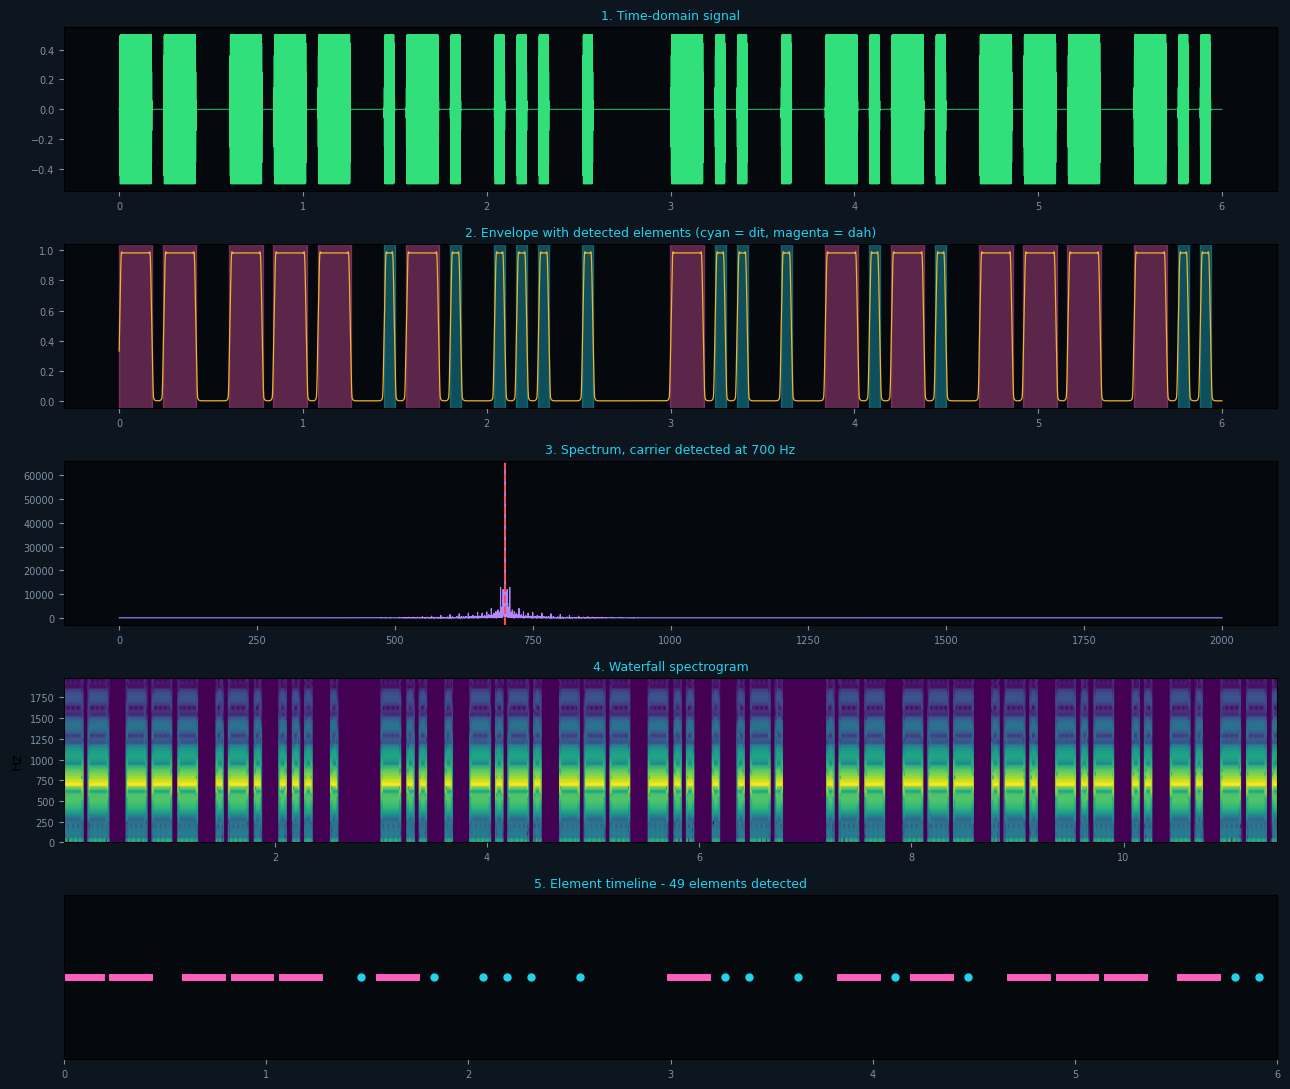

dits 24 | dahs 25 | elements 49


In [21]:
def element_segments(envelope, detector, sample_rate):
    """Every on-period in the envelope, as (start_s, end_s, kind).

    Read straight from the detector output, so elements that never resolve
    into a character are still present.
    """
    dit = getattr(detector, "dit_samples", None)
    if not dit:
        return []
    binary = (envelope > detector.threshold_ratio * np.max(envelope)).astype(np.int8)
    dah_threshold = getattr(detector, "dah_threshold", 2.0)
    segments, index, total = [], 0, len(binary)
    while index < total:
        if binary[index] == 1:
            start = index
            while index < total and binary[index] == 1:
                index += 1
            kind = "dit" if (index - start) < dah_threshold * dit else "dah"
            segments.append((start / sample_rate, index / sample_rate, kind))
        else:
            index += 1
    return segments


segments = element_segments(result.envelope, result.detector, sample_rate)
times = np.arange(len(audio)) / sample_rate
view = (times >= 0) & (times <= min(6.0, times[-1]))

figure, axes = plt.subplots(5, 1, figsize=(13, 11))
figure.patch.set_facecolor("#0d151e")

axes[0].plot(times[view], audio[view], color="#31e07a", linewidth=0.6)
axes[0].set_title("1. Time-domain signal")

envelope_norm = result.envelope / (np.max(result.envelope) + 1e-9)
axes[1].plot(times[view], envelope_norm[view], color="#f0b429", linewidth=0.9)
for start, end, kind in segments:
    if start > 6.0:
        break
    axes[1].axvspan(start, end, color="#22d3ee" if kind == "dit" else "#ff5fbf", alpha=0.35)
axes[1].set_title("2. Envelope with detected elements (cyan = dit, magenta = dah)")

spectrum = np.abs(np.fft.rfft(audio))
frequencies = np.fft.rfftfreq(len(audio), 1 / sample_rate)
band = frequencies <= 2000
axes[2].plot(frequencies[band], spectrum[band], color="#b388ff", linewidth=0.8)
axes[2].axvline(result.carrier_hz, color="#ff4d4d", linestyle="--")
axes[2].set_title(f"3. Spectrum, carrier detected at {result.carrier_hz:.0f} Hz")

freq_axis, time_axis, values = spectrogram(audio, fs=sample_rate, nperseg=1024, noverlap=512)
band = freq_axis <= 2000
axes[3].imshow(10 * np.log10(values[band, :] + 1e-12), aspect="auto", origin="lower",
               cmap="viridis",
               extent=[time_axis[0], time_axis[-1], freq_axis[band][0], freq_axis[band][-1]])
axes[3].set_title("4. Waterfall spectrogram")
axes[3].set_ylabel("Hz")

for start, end, kind in segments:
    if kind == "dit":
        axes[4].plot([(start + end) / 2], [0.5], marker="o", markersize=5, color="#22d3ee")
    else:
        axes[4].plot([start, end], [0.5, 0.5], linewidth=5, color="#ff5fbf")
axes[4].set_ylim(0, 1)
axes[4].set_yticks([])
axes[4].set_xlim(0, min(6.0, times[-1]))
axes[4].set_title(f"5. Element timeline - {len(segments)} elements detected")

for axis in axes:
    axis.set_facecolor("#05090d")
    axis.tick_params(colors="#7d93a8", labelsize=7)
    axis.title.set_color("#22d3ee")
    axis.title.set_size(9)

plt.tight_layout()
plt.show()

dits = sum(1 for _, _, kind in segments if kind == "dit")
dahs = len(segments) - dits
print(f"dits {dits} | dahs {dahs} | elements {len(segments)}")

## 21. Accuracy across the speed range

One decoder, no per-speed tuning. Every row generates fresh audio at that
speed and decodes it back.

In [22]:
PHRASE = "THE QUICK BROWN FOX"
rows = []
for wpm in range(10, 41, 5):
    path = f"audio_samples/_sweep_{wpm}.wav"
    with contextlib.redirect_stdout(io.StringIO()):   # the generator is chatty
        generate_morse_audio(PHRASE, path, wpm=wpm, frequency=700)

    source = FileSource(filepath=path, chunk_size=1024)
    source.start()
    pieces = []
    while not source.is_finished:
        chunk = source.read_chunk()
        if len(chunk) > 0:
            pieces.append(chunk)
    source.stop()

    outcome = decode_pipeline(np.concatenate(pieces), source.sample_rate)
    rows.append((wpm, round(outcome.estimated_wpm, 1), outcome.corrected_text.strip(),
                 outcome.corrected_text.strip() == PHRASE))

print()
print(f"{'set':>5} {'measured':>9}  {'ok':<5} decoded")
print("-" * 60)
for target, measured, text, correct in rows:
    print(f"{target:>5} {measured:>9}  {str(correct):<5} {text}")
print("-" * 60)
print(f"{sum(1 for r in rows if r[3])}/{len(rows)} correct")

for wpm in range(10, 41, 5):        # tidy up the scratch audio
    temp = f"audio_samples/_sweep_{wpm}.wav"
    if os.path.exists(temp):
        os.remove(temp)


  set  measured  ok    decoded
------------------------------------------------------------
   10       9.4  True  THE QUICK BROWN FOX
   15      14.4  True  THE QUICK BROWN FOX
   20      19.6  True  THE QUICK BROWN FOX
   25      25.0  True  THE QUICK BROWN FOX
   30      30.5  True  THE QUICK BROWN FOX
   35      36.4  True  THE QUICK BROWN FOX
   40      42.5  True  THE QUICK BROWN FOX
------------------------------------------------------------
7/7 correct


## 22. What the language model does

The correction layer is the one statistical component. It is trained on text,
never on audio. Below it is given text with the kind of errors a marginal
signal produces.

In [23]:
model = get_language_model()
print("vocabulary size:", model.vocabulary_size)
print()
for damaged in ["M0RSE DEC0DER", "THE QU1CK BR0WN F0X", "CQ CQ DE DL1ABC", "HELLO WORLD"]:
    print(f"{damaged:<22} ->  {model.correct(damaged)}")
print()
print("Note: the model is conservative by design. It leaves valid words alone,")
print("and it can still be wrong on names and unusual words - see the word-level")
print("substitutions above before trusting it on unfamiliar text.")

vocabulary size: 4920

M0RSE DEC0DER          ->  MORSE DECODER


THE QU1CK BR0WN F0X    ->  THE QUICK BROWN FOX
CQ CQ DE DL1ABC        ->  CQ CQ DE DL1ABC
HELLO WORLD            ->  HELLO WORLD

Note: the model is conservative by design. It leaves valid words alone,
and it can still be wrong on names and unusual words - see the word-level
substitutions above before trusting it on unfamiliar text.


## 23. Application 1 - MorseViewApp

The main decoding window: load a file, decode, and watch the text appear in
step with playback.

This cell opens a separate window and blocks the notebook kernel until that
window is closed. Set `LAUNCH_GUI = True` in the setup cell first.

### Source

In [24]:
"""
Morse Code Decoder - "Morse View" style single-window GUI (file input).

Layout inspired by classic Morse decoder tools (e.g. Mitov Morse View):
  - Input source     : load an audio file (.wav / .mp3)
  - Decoder controller: Play + Decode / Stop, Clear
  - Decoder settings  : threshold, bandpass low/high, smoothing
                        (AUTOMATIC by default; optional overrides)
  - Stream view       : green-on-black on/off waveform with a moving playback
                        cursor that tracks the audio position
  - Decoder output    : RAW decoded text (revealed in sync with playback),
                        CORRECTED text (language model), and the Morse string

Decoding uses the unified decode_pipeline: automatic carrier detection,
two-pass adaptive smoothing (so 10-40 WPM all decode well), and the N-gram
language model for error correction. The GUI shows both the raw decode and the
corrected text side by side.

Flow:
  1. Load a file   -> the waveform is shown (no playback yet).
  2. Play + Decode -> audio plays; the decoded text appears gradually in time
                      with the sound; a vertical cursor sweeps the waveform;
                      the corrected text and Morse fill in.
  3. Stop          -> freezes where it is.

Run from the project root:
    python -m src.app_view
"""

import os
import tkinter as tk
from tkinter import ttk, filedialog, messagebox

import numpy as np
import matplotlib
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

try:
    import sounddevice as sd
    SOUNDDEVICE_AVAILABLE = True
except Exception:
    SOUNDDEVICE_AVAILABLE = False


VIEW_GREEN = "#00FF00"
VIEW_DGREEN = "#1a4d1a"
VIEW_MGREEN = "#00AA00"
VIEW_CURSOR = "#FF4444"
VIEW_BLACK = "#000000"


class MorseViewApp:
    """Single-window file decoder: settings, stream view w/ cursor, sync reveal, correction."""

    def __init__(self, root: tk.Tk):
        self.root = root
        self.root.title("Morse Code Decoder - Morse View")
        self.root.geometry("1150x900")

        self.sample_rate = 44100
        self.audio = None

        # decode results (computed on Play / load)
        self.full_decoded = ""       # raw decoded text
        self.full_corrected = ""     # language-model corrected text
        self.full_morse = ""
        self.char_times = []
        self.duration_s = 0.0
        self.carrier = 0.0
        self.wpm = 0.0
        self.smoothing_ms = 0.0
        self.was_corrected = False
        self.last_envelope = None

        # playback state
        self.is_playing = False
        self.play_start_ms = None
        self._play_id = None
        self._cursor_line = None
        self._stream_ax = None
        self._resume_pos_s = 0.0     # where to resume playback from (seconds)
        self._decoded_once = False   # whether the current audio is already decoded

        self._build_ui()

    # ---------- UI ----------

    def _build_ui(self):
        top = ttk.Frame(self.root, padding=8)
        top.pack(fill=tk.X)

        src = ttk.LabelFrame(top, text="Input source", padding=8)
        src.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 8))
        ttk.Button(src, text="Load audio file...", command=self.on_load_file).pack(fill=tk.X, pady=2)
        self.file_label = ttk.Label(src, text="(no file)", width=28)
        self.file_label.pack(anchor=tk.W, pady=2)

        ctrl = ttk.LabelFrame(top, text="Decoder controller", padding=8)
        ctrl.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 8))
        self.play_button = ttk.Button(ctrl, text="Play + Decode", command=self.on_play, state=tk.DISABLED)
        self.play_button.pack(fill=tk.X, pady=2)
        self.stop_button = ttk.Button(ctrl, text="Stop", command=self.on_stop, state=tk.DISABLED)
        self.stop_button.pack(fill=tk.X, pady=2)
        ttk.Button(ctrl, text="Clear", command=self.on_clear).pack(fill=tk.X, pady=2)
        self.status_label = ttk.Label(ctrl, text="Load a file, then Play + Decode.", width=34, wraplength=240)
        self.status_label.pack(anchor=tk.W, pady=6)

        setp = ttk.LabelFrame(top, text="Decoder settings (auto by default)", padding=8)
        setp.pack(side=tk.LEFT, fill=tk.Y)
        self.auto_var = tk.BooleanVar(value=True)
        ttk.Checkbutton(setp, text="Automatic (recommended)", variable=self.auto_var,
                        command=self._toggle_auto).grid(row=0, column=0, columnspan=2, sticky=tk.W)
        self.correct_var = tk.BooleanVar(value=True)
        ttk.Checkbutton(setp, text="Language correction",
                        variable=self.correct_var).grid(row=1, column=0, columnspan=2, sticky=tk.W)
        self.threshold_var = tk.StringVar(value="0.30")
        self.bp_low_var = tk.StringVar(value="auto")
        self.bp_high_var = tk.StringVar(value="auto")
        rows = [("Threshold (0-1):", self.threshold_var),
                ("Bandpass low (Hz):", self.bp_low_var),
                ("Bandpass high (Hz):", self.bp_high_var)]
        self._setting_entries = []
        for i, (lbl, var) in enumerate(rows, start=2):
            ttk.Label(setp, text=lbl).grid(row=i, column=0, sticky=tk.W, pady=1)
            e = ttk.Entry(setp, textvariable=var, width=10)
            e.grid(row=i, column=1, sticky=tk.W, padx=4, pady=1)
            self._setting_entries.append(e)
        self._toggle_auto()

        mid = ttk.Frame(self.root, padding=8)
        mid.pack(fill=tk.BOTH, expand=True)
        self.figure = Figure(figsize=(11, 3.4), dpi=88, facecolor=VIEW_BLACK)
        self.canvas = FigureCanvasTkAgg(self.figure, master=mid)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        self._draw_empty_stream()

        out = ttk.Frame(self.root, padding=8)
        out.pack(fill=tk.X)
        ttk.Label(out, text="Raw decoded text (as detected):").pack(anchor=tk.W)
        self.text_output = tk.Text(out, height=2, wrap=tk.WORD, font=("Consolas", 12))
        self.text_output.pack(fill=tk.X, pady=(0, 6))
        self.text_output.configure(state=tk.DISABLED)

        ttk.Label(out, text="Corrected text (language model):").pack(anchor=tk.W)
        self.corrected_output = tk.Text(out, height=2, wrap=tk.WORD, font=("Consolas", 14))
        self.corrected_output.pack(fill=tk.X, pady=(0, 6))
        self.corrected_output.configure(state=tk.DISABLED)

        ttk.Label(out, text="Morse view:").pack(anchor=tk.W)
        self.morse_output = tk.Text(out, height=2, wrap=tk.WORD, font=("Consolas", 11))
        self.morse_output.pack(fill=tk.X)
        self.morse_output.configure(state=tk.DISABLED)

    def _toggle_auto(self):
        state = tk.DISABLED if self.auto_var.get() else tk.NORMAL
        for e in self._setting_entries:
            e.config(state=state)

    # ---------- input ----------

    def on_load_file(self):
        path = filedialog.askopenfilename(
            title="Select an audio file",
            filetypes=[("Audio files", "*.wav *.mp3"), ("All files", "*.*")])
        if not path:
            return
        try:
            self.audio, self.sample_rate = self._load_audio(path)
        except Exception as exc:
            self._fail(f"Could not read file: {exc}")
            return
        if len(self.audio) == 0:
            self._fail("File loaded but had no audio.")
            return
        name = os.path.basename(path)
        self.file_label.config(text=name)
        self.duration_s = len(self.audio) / self.sample_rate
        self._resume_pos_s = 0.0      # new file -> start fresh
        self._decoded_once = False    # new file -> needs decoding
        self._clear_text()
        self._draw_stream(self.audio)
        self.status_label.config(text=f"Loaded {name}. Click Play + Decode.")
        self.play_button.config(state=tk.NORMAL if SOUNDDEVICE_AVAILABLE else tk.DISABLED)
        self.stop_button.config(state=tk.DISABLED)
        if not SOUNDDEVICE_AVAILABLE:
            self._decode_static()

    # ---------- decode (via unified pipeline) ----------

    def _run_pipeline(self):
        """Decode self.audio with the unified pipeline; store all results."""
        result = decode_pipeline(
            self.audio, self.sample_rate,
            center_frequency=self._manual_carrier(),
            threshold_ratio=self._threshold(),
            apply_correction=self.correct_var.get(),
        )
        self.carrier = result.carrier_hz
        self.smoothing_ms = result.smoothing_ms
        self.wpm = result.estimated_wpm
        self.last_envelope = result.envelope
        self.full_morse = result.morse
        self.full_decoded = result.raw_text
        self.full_corrected = result.corrected_text
        self.was_corrected = result.was_corrected
        self.char_times = self._compute_char_times(result.envelope, result.detector)

    def _decode_static(self):
        """Decode and show the full result without playback (fallback)."""
        try:
            self._run_pipeline()
        except Exception as exc:
            self._fail(f"Decoding failed: {exc}")
            return
        self._draw_stream(self.audio, self.last_envelope)
        if not self.full_morse:
            self.status_label.config(text=f"No Morse found (carrier {self.carrier:.0f} Hz).")
            return
        self._set_text(self.text_output, self.full_decoded)
        self._set_text(self.corrected_output, self.full_corrected)
        self._set_text(self.morse_output, self.full_morse)
        self._status_summary()

    def _compute_char_times(self, envelope, detector):
        dit = getattr(detector, "dit_samples", None)
        if not dit:
            return []
        threshold = detector.threshold_ratio * np.max(envelope)
        binary = (envelope > threshold).astype(np.int8)
        dah_thr = getattr(detector, "dah_threshold", 2.0)
        letter_gap = getattr(detector, "letter_gap_threshold", 2.0) * dit
        word_gap = getattr(detector, "word_gap_threshold", 5.0) * dit
        n = len(binary); i = 0; char_times = []; current = []
        while i < n and binary[i] == 0:
            i += 1

        def flush(end):
            if not current:
                return
            ch = INVERSE_MORSE_TABLE.get("".join(current), "?")
            char_times.append((end / self.sample_rate, ch))
            current.clear()

        while i < n:
            s = i
            while i < n and binary[i] == 1:
                i += 1
            on_len = i - s
            current.append("." if on_len < dah_thr * dit else "-")
            letter_end = i
            s = i
            while i < n and binary[i] == 0:
                i += 1
            gap_len = i - s
            if i >= n:
                flush(letter_end); break
            if gap_len >= word_gap:
                flush(letter_end); char_times.append((letter_end / self.sample_rate, " "))
            elif gap_len >= letter_gap:
                flush(letter_end)
        return char_times

    def _status_summary(self):
        extra = f", smoothing {self.smoothing_ms:.0f}ms"
        corr = "  (corrected)" if self.was_corrected else ""
        self.status_label.config(
            text=f"Carrier {self.carrier:.0f} Hz, ~{self.wpm:.1f} WPM{extra}.{corr}")

    # ---------- playback ----------

    def on_play(self):
        if self.audio is None or not SOUNDDEVICE_AVAILABLE or self.is_playing:
            return

        # Decode only once per loaded file. On resume we reuse the decode.
        if not self._decoded_once:
            self._clear_text()
            self.status_label.config(text="Decoding...")
            self.root.update_idletasks()
            try:
                self._run_pipeline()
            except Exception as exc:
                self._fail(f"Decoding failed: {exc}")
                return
            self._draw_stream(self.audio, self.last_envelope)
            if not self.full_morse:
                self.status_label.config(text=f"No Morse found (carrier {self.carrier:.0f} Hz).")
                return
            self._decoded_once = True

        # During playback, only the RAW text reveals in sync with the audio.
        # The corrected text is filled in at the end (see _finish_playback),
        # so the viewer sees the raw decode first, then the cleaned-up result.
        self.is_playing = True
        self.play_button.config(state=tk.DISABLED)
        self.stop_button.config(state=tk.NORMAL)

        # Resume from where we stopped (or from the start if at the beginning).
        start_s = self._resume_pos_s
        if start_s >= self.duration_s - 0.05:
            start_s = 0.0  # was at/near the end -> restart from beginning
        start_sample = int(start_s * self.sample_rate)

        sd.stop()
        sd.play(self.audio[start_sample:], self.sample_rate)
        # Offset the reveal clock so elapsed time reflects the resume point.
        self.play_start_ms = self._now_ms() - int(start_s * 1000)
        self._reveal_tick()

    def _reveal_tick(self):
        if not self.is_playing:
            return
        elapsed = (self._now_ms() - self.play_start_ms) / 1000.0
        revealed = "".join(ch for (t, ch) in self.char_times if t <= elapsed)
        self._set_text(self.text_output, revealed)
        if self.duration_s > 0:
            frac = min(1.0, elapsed / self.duration_s)
            self._set_text(self.morse_output, self.full_morse[:int(frac * len(self.full_morse))])
        self._move_cursor(elapsed)
        self.status_label.config(text=f"Playing... {elapsed:.1f} / {self.duration_s:.1f} s")
        if elapsed >= self.duration_s:
            self._finish_playback()
            return
        self._play_id = self.root.after(80, self._reveal_tick)

    def _finish_playback(self):
        self.is_playing = False
        if self._play_id is not None:
            self.root.after_cancel(self._play_id)
            self._play_id = None
        if SOUNDDEVICE_AVAILABLE:
            sd.stop()
        self._resume_pos_s = 0.0  # finished -> next Play starts from the beginning
        self._set_text(self.text_output, self.full_decoded)
        self._set_text(self.corrected_output, self.full_corrected)
        self._set_text(self.morse_output, self.full_morse)
        self._move_cursor(self.duration_s)
        self.play_button.config(state=tk.NORMAL if SOUNDDEVICE_AVAILABLE else tk.DISABLED)
        self.stop_button.config(state=tk.DISABLED)
        self._status_summary()

    def on_stop(self):
        if not self.is_playing:
            return
        self.is_playing = False
        if self._play_id is not None:
            self.root.after_cancel(self._play_id)
            self._play_id = None
        if SOUNDDEVICE_AVAILABLE:
            sd.stop()
        # Remember where we stopped, so Play resumes from here.
        self._resume_pos_s = (self._now_ms() - self.play_start_ms) / 1000.0
        self.play_button.config(state=tk.NORMAL if SOUNDDEVICE_AVAILABLE else tk.DISABLED)
        self.stop_button.config(state=tk.DISABLED)
        self.status_label.config(text=f"Stopped at {self._resume_pos_s:.1f} s. Play to resume.")

    # ---------- decode parameters ----------

    def _manual_carrier(self):
        """Return a manual carrier if the user set one, else None (auto-detect)."""
        if self.auto_var.get():
            return None
        try:
            lo = float(self.bp_low_var.get()); hi = float(self.bp_high_var.get())
            return (lo + hi) / 2.0
        except ValueError:
            return None

    def _threshold(self):
        if self.auto_var.get():
            return 0.30
        try:
            return float(self.threshold_var.get())
        except ValueError:
            return 0.30

    # ---------- stream view ----------

    def _draw_empty_stream(self):
        self.figure.clear()
        ax = self.figure.add_subplot(111, facecolor=VIEW_BLACK)
        ax.text(0.5, 0.5, "Stream view", color=VIEW_GREEN, ha="center", va="center", fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_color(VIEW_MGREEN)
        self._stream_ax = ax
        self._cursor_line = None
        self.canvas.draw()

    def _draw_stream(self, audio, envelope=None):
        self.figure.clear()
        ax = self.figure.add_subplot(111, facecolor=VIEW_BLACK)
        sr = self.sample_rate
        if envelope is not None:
            sig = envelope / (np.max(envelope) + 1e-9)
        else:
            sig = np.abs(audio) / (np.max(np.abs(audio)) + 1e-9)
        max_points = 8000
        step = max(1, len(sig) // max_points)
        sig_ds = sig[::step]
        t = np.arange(len(sig_ds)) * step / sr
        ax.plot(t, sig_ds, color=VIEW_GREEN, linewidth=0.9)
        ax.grid(True, color=VIEW_DGREEN, linewidth=0.6)
        ax.set_xlabel("Time (s)", color=VIEW_GREEN)
        ax.set_ylabel("Level", color=VIEW_GREEN)
        ax.tick_params(colors=VIEW_GREEN)
        ax.set_title("Stream view", color=VIEW_GREEN, fontsize=12)
        ax.set_xlim(0, max(t[-1] if len(t) else 1, 1))
        for s in ax.spines.values():
            s.set_color(VIEW_MGREEN)
        self.figure.tight_layout(pad=1.5)
        self._stream_ax = ax
        self._cursor_line = ax.axvline(x=0, color=VIEW_CURSOR, linewidth=1.5)
        self._cursor_line.set_visible(False)
        self.canvas.draw()

    def _move_cursor(self, t_seconds):
        if self._cursor_line is None or self._stream_ax is None:
            return
        self._cursor_line.set_visible(True)
        self._cursor_line.set_xdata([t_seconds, t_seconds])
        self.canvas.draw_idle()

    # ---------- helpers ----------

    def on_clear(self):
        if self.is_playing:
            self.on_stop()
        self._clear_text()
        self.audio = None
        self._resume_pos_s = 0.0
        self._decoded_once = False
        self.file_label.config(text="(no file)")
        self.status_label.config(text="Cleared. Load a file.")
        self.play_button.config(state=tk.DISABLED)
        self.stop_button.config(state=tk.DISABLED)
        self._draw_empty_stream()

    def _clear_text(self):
        self._set_text(self.text_output, "")
        self._set_text(self.corrected_output, "")
        self._set_text(self.morse_output, "")

    def _fail(self, message):
        self._clear_text()
        self.status_label.config(text=f"FAILED: {message}")
        messagebox.showerror("Error", message)

    def _set_text(self, widget, text):
        widget.configure(state=tk.NORMAL)
        widget.delete("1.0", tk.END)
        widget.insert(tk.END, text)
        widget.configure(state=tk.DISABLED)

    def _now_ms(self):
        return self.root.tk.call("clock", "milliseconds")

    def _load_audio(self, path):
        source = FileSource(filepath=path, chunk_size=1024)
        source.start()
        sr = source.sample_rate
        chunks = []
        while not source.is_finished:
            c = source.read_chunk()
            if len(c) > 0:
                chunks.append(c)
        source.stop()
        if not chunks:
            return np.array([], dtype=np.float32), sr
        return np.concatenate(chunks), sr

In [25]:
if LAUNCH_GUI:
    root = tk.Tk()
    MorseViewApp(root)
    root.mainloop()
else:
    print("LAUNCH_GUI is False - set it to True in the setup cell to open this window.")

LAUNCH_GUI is False - set it to True in the setup cell to open this window.


## 24. Decoding a live stream

Everything above decodes a complete recording. This section decodes audio
*while it arrives*, which is what a live input requires.

`PacedFileSource` releases a file at the speed it actually plays, so it stands
in for a microphone or a virtual audio cable: same interface, same block size,
same "nothing is ready yet" behaviour. The decoder has no idea it is not
listening to a radio.

Watch the timestamps in the output: text appears while the stream is still
running, not at the end.

In [26]:
from src.audio.paced_file_source import PacedFileSource
from src.processing.stream_decoder import StreamDecoder

STREAM_TEXT = "CQ DE MORSE DECODER K"
stream_path = "audio_samples/notebook_stream.wav"
generate_morse_audio(STREAM_TEXT, output_path=stream_path, wpm=20, sample_rate=44100)

# 6x real time so the notebook does not take a minute to run.
source = PacedFileSource(stream_path, chunk_size=1024, speed=6.0)
decoder = StreamDecoder(sample_rate=44100)

source.start()
updates = []
while not source.is_finished:
    chunk = source.read_chunk()
    if len(chunk):
        decoder.feed(chunk)
        new_text = decoder.poll()
        if new_text:
            updates.append((decoder.stream_seconds, new_text))
# Latency while the stream was actually running. Measure it before the
# artificial silence below, which would otherwise inflate the last reading.
typical_latency = decoder.character_latency_seconds

# The operator stops sending. The silence that follows is what proves the
# last character has ended, so feed a little of it before the final decode.
decoder.feed(np.zeros(int(1.5 * 44100), dtype=np.float32))
final = decoder.poll(force=True)
if final:
    updates.append((decoder.stream_seconds, final))
source.stop()

print("Text as it arrived, with the position in the stream:")
for when, piece in updates:
    print(f"  [{when:6.2f} s]  {piece!r}")

print()
print("Transmitted:", STREAM_TEXT)
print("Decoded:    ", decoder.text.strip())
print("Corrected:  ", decoder.corrected_text.strip())
print(f"Carrier:     {decoder.carrier_hz:.0f} Hz")
print(f"Speed:       {decoder.estimated_wpm:.1f} WPM")
print(f"Latency:     {typical_latency * 1000:.0f} ms behind the live edge")
print()
print("The decoder never saw the whole recording: it worked from a rolling")
print(f"{decoder.window_seconds:.0f} second window and committed a character only once the")
print("gap after it proved the character had ended. That wait is the latency.")

Text:      CQ DE MORSE DECODER K
Morse:     -.-. --.- / -.. . / -- --- .-. ... . / -.. . -.-. --- -.. . .-. / -.-
WPM:       20
Frequency: 700.0 Hz
Duration:  10.86 s
Saved to:  audio_samples/notebook_stream.wav


Text as it arrived, with the position in the stream:
  [  2.00 s]  'C'
  [  2.60 s]  'Q '
  [  3.21 s]  'D'
  [  3.81 s]  'E '
  [  4.41 s]  'M'
  [  5.02 s]  'O'
  [  5.62 s]  'R'
  [  6.23 s]  'SE'
  [  6.83 s]  ' '
  [  7.43 s]  'DE'
  [  8.64 s]  'C'
  [  9.24 s]  'O'
  [  9.85 s]  'DE'
  [ 10.45 s]  'R'
  [ 12.36 s]  ' K'

Transmitted: CQ DE MORSE DECODER K
Decoded:     CQ DE MORSE DECODER K
Corrected:   CQ DE MORSE DECODER K
Carrier:     700 Hz
Speed:       20.4 WPM
Latency:     552 ms behind the live edge

The decoder never saw the whole recording: it worked from a rolling
8 second window and committed a character only once the
gap after it proved the character had ended. That wait is the latency.


## 25. Application 2 - DashboardApp, both modes in one window

The dashboard is one window with two sources of audio.

**Audio File** decodes the whole recording first, then replays it with the
text revealed in step with the audio. Because the entire signal is available
at once, this is the more accurate mode.

**Live Input** decodes audio as it arrives, from a microphone or from a
virtual audio cable carrying a WebSDR receiver. `Stream a File` runs that same
live path against a recording, at real-time speed, so it can be demonstrated
with no radio attached.

Both modes drive the same seven panels and the same decoding code. `app_stream`
is a two-line launcher that opens this window with Live Input pre-selected.

### Source

In [27]:
"""
Morse Code Decoder - pipeline dashboard.

One window, two sources of audio.

  FILE MODE   Load a recording. The whole file is decoded first, then replayed
              with the text revealed in step with the audio. Because the entire
              signal is available at once, this is the more accurate mode: the
              threshold sees the true peak and the speed estimate sees every
              element in the recording.

  LIVE MODE   Decode audio as it arrives, from a microphone or from a virtual
              audio cable carrying a WebSDR receiver in a browser. Nothing is
              known in advance. A rolling window of recent audio is re-decoded
              several times a second, and a character is released only once the
              gap after it proves that it has ended.

Both modes drive the same seven panels and the same decoding code. What differs
is where the samples come from and how much of the signal exists when decoding
starts:

    file:  FileSource                        -> decode_pipeline -> replay
    live:  MicrophoneSource, PacedFileSource -> StreamDecoder   -> as it arrives

All four sources are AudioSource subclasses, so neither decoder knows or cares
which one it was handed.

Honest metrics only
-------------------
No confidence score in either mode: the detector compares a duration against a
threshold and looks the pattern up in a table, which produces a symbol, not a
probability.

No latency figure in file mode, because a recording is decoded and then
replayed - there is nothing real to measure. Live mode does show one, because
there the wait is real.

Run from the project root:
    python -m src.app_dashboard      opens in file mode
    python -m src.app_stream         opens in live mode
    python main.py dashboard | stream
"""

import os
import queue
import threading
import time
import tkinter as tk
from tkinter import filedialog, messagebox, ttk

import numpy as np
from scipy.signal import spectrogram, butter, sosfiltfilt

import matplotlib
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.collections import PolyCollection, LineCollection

try:
    import sounddevice as sd
    PLAYBACK_AVAILABLE = True
except Exception:
    sd = None
    PLAYBACK_AVAILABLE = False

try:
    pass  # import dropped: one-notebook build
    AUDIO_INPUT_AVAILABLE = True
    AUDIO_INPUT_ERROR = ""
except Exception as exc:
    MicrophoneSource = None
    AUDIO_INPUT_AVAILABLE = False
    AUDIO_INPUT_ERROR = str(exc)


# ---------------------------------------------------------------- appearance
BG = "#080d13"
PANEL_BG = "#0d151e"
PLOT_BG = "#05090d"
BORDER = "#1b2a38"
FG = "#d5e2f0"
MUTED = "#7d93a8"
CYAN = "#22d3ee"
GREEN = "#22c55e"
AMBER = "#f0b429"
VIOLET = "#b388ff"
DIT_C = "#22d3ee"
DAH_C = "#ff5fbf"
CURSOR = "#ff4d4d"
WAVE_C = "#31e07a"
GRID_C = "#1d2b39"

# ---------------------------------------------------------------- behaviour
DEFAULT_SAMPLE_RATE = 44100   # replaced by whatever the chosen source reports
CHUNK = 1024
WINDOW_S = 6.0                # seconds of signal visible at once
TICK_MS = 110                 # display refresh interval
WAVE_POINTS = 1100
FFT_N = 8192
PLOT_DPI = 74
RAIL_W = 158
DISPLAY_SECONDS = 12.0        # recent audio kept for drawing in live mode
WATERFALL_COLUMNS = 900
STAGGER_HEAVY = True          # refresh FFT and waterfall on alternate frames


class DashboardApp:
    """Morse decoding dashboard with a file mode and a live mode."""

    def __init__(self, root: tk.Tk, mode: str = "file"):
        self.root = root
        self.root.title("Morse Code Decoder - Pipeline Dashboard")
        self.root.geometry("1500x950")
        self.root.minsize(1100, 720)
        self.root.configure(bg=BG)

        self.mode = "file"
        self.sample_rate = DEFAULT_SAMPLE_RATE

        # ---- file mode state
        self.audio = None
        self.duration_s = 0.0
        self.envelope = None
        self.env_norm = None
        self.carrier = 0.0
        self.wpm = 0.0
        self.snr_db = 0.0
        self.symbols = []
        self.char_events = []
        self.full_raw = ""
        self.full_corrected = ""
        self.n_dits = 0
        self.n_dahs = 0
        self._decoded_once = False
        self._spec_db = None
        self._spec_t = None
        self._spec_f = None
        self._spec_vmin = -100.0
        self._spec_vmax = 0.0
        self._fft_ref = 1.0
        self.is_playing = False
        self.play_start_ms = None
        self._pos_s = 0.0

        # ---- live mode state
        self.decoder = StreamDecoder(sample_rate=self.sample_rate)
        self.source = None
        self.is_running = False
        self._worker = None
        self._worker_stop = threading.Event()
        self._text_queue = queue.Queue()
        self._started_at = None
        self._display = np.zeros(0, dtype=np.float32)
        self._display_start_s = 0.0
        self._wf_pending = np.zeros(0, dtype=np.float32)
        self._wf_columns = None
        self._wf_times = []
        self._wf_freqs = None
        self._devices = []

        # ---- shared
        self._tick_id = None
        self._logged_upto = 0
        self._word_cache = {}
        self._frame = 0
        self._draw_errors = 0
        self._water_img = None
        self.panels = {}

        self._build_ui()
        self.set_mode(mode)

    # ------------------------------------------------------------------ UI

    def _build_ui(self):
        self._build_topbar()

        body = tk.Frame(self.root, bg=BG)
        body.pack(fill=tk.BOTH, expand=True, padx=8, pady=(0, 4))

        # The sidebar packs first, against the right edge. Tk allocates space
        # in packing order, so a sidebar packed after an expanding frame is the
        # first thing starved on a narrow or DPI-scaled display.
        side = tk.Frame(body, bg=BG, width=300)
        side.pack(side=tk.RIGHT, fill=tk.Y, padx=(8, 0))
        side.pack_propagate(False)
        self._build_sidebar(side)

        left = tk.Frame(body, bg=BG)
        left.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        self._build_panels(left)
        self._build_output(left)

        self._build_statusbar()

    def _build_topbar(self):
        bar = tk.Frame(self.root, bg=BG)
        bar.pack(fill=tk.X, padx=10, pady=(8, 4))
        tk.Label(bar, text="MORSE CODE DECODER", bg=BG, fg=CYAN,
                 font=("Segoe UI", 13, "bold")).pack(side=tk.LEFT)

        self.live_badge = tk.Label(bar, text="  IDLE  ", bg="#16222e", fg=MUTED,
                                   font=("Segoe UI", 9, "bold"))
        self.live_badge.pack(side=tk.RIGHT, padx=(10, 0))
        self.carrier_top = tk.Label(bar, text="Carrier:  --", bg=BG, fg=CURSOR,
                                    font=("Consolas", 10, "bold"))
        self.carrier_top.pack(side=tk.RIGHT, padx=10)
        self.wpm_top = tk.Label(bar, text="WPM:  --", bg=BG, fg=AMBER,
                                font=("Consolas", 10, "bold"))
        self.wpm_top.pack(side=tk.RIGHT, padx=10)

        modebar = tk.Frame(self.root, bg=BG)
        modebar.pack(fill=tk.X, padx=10, pady=(0, 4))
        tk.Label(modebar, text="Audio source:", bg=BG, fg=MUTED,
                 font=("Segoe UI", 9)).pack(side=tk.LEFT, padx=(0, 8))
        self.mode_var = tk.StringVar(value="file")
        self.mode_buttons = {}
        for key, text in (("file", "Audio File"), ("live", "Live Input")):
            button = tk.Radiobutton(
                modebar, text=text, value=key, variable=self.mode_var,
                command=lambda k=key: self.set_mode(k), indicatoron=False,
                width=14, padx=6, pady=3, font=("Segoe UI", 9, "bold"),
                bg="#16222e", fg=MUTED, selectcolor="#15803d",
                activebackground="#1d2f42", activeforeground="white",
                relief=tk.FLAT, borderwidth=0)
            button.pack(side=tk.LEFT, padx=2)
            self.mode_buttons[key] = button
        self.mode_hint = tk.Label(modebar, text="", bg=BG, fg=MUTED,
                                  font=("Segoe UI", 8))
        self.mode_hint.pack(side=tk.LEFT, padx=(14, 0))

        # One controls row per mode; only the active one is shown.
        self.control_area = tk.Frame(self.root, bg=BG)
        self.control_area.pack(fill=tk.X, padx=10, pady=(0, 6))
        self._build_file_controls()
        self._build_live_controls()

    def _build_file_controls(self):
        row = tk.Frame(self.control_area, bg=BG)
        self.file_controls = row

        self.load_btn = self._button(row, "Load Audio", self.on_load, "#243447")
        self.play_btn = self._button(row, "Play", self.on_play, "#15803d",
                                     state=tk.DISABLED)
        self.pause_btn = self._button(row, "Pause", self.on_pause, "#a16207",
                                      state=tk.DISABLED)
        self.file_stop_btn = self._button(row, "Stop", self.on_stop_file,
                                          "#b91c1c", state=tk.DISABLED)

        tk.Label(row, text="File:", bg=BG, fg=MUTED,
                 font=("Segoe UI", 9)).pack(side=tk.LEFT, padx=(16, 4))
        self.file_label = tk.Label(row, text="(none)", bg=BG, fg=FG,
                                   font=("Consolas", 10))
        self.file_label.pack(side=tk.LEFT)

        tk.Label(row, text="Time:", bg=BG, fg=MUTED,
                 font=("Segoe UI", 9)).pack(side=tk.LEFT, padx=(16, 4))
        self.time_label = tk.Label(row, text="00:00:00 / 00:00:00", bg=BG,
                                   fg=FG, font=("Consolas", 10))
        self.time_label.pack(side=tk.LEFT)

        self.progress = tk.Canvas(row, height=6, bg="#16222e",
                                  highlightthickness=0)
        self.progress.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=12)
        self._progress_fill = self.progress.create_rectangle(0, 0, 0, 6,
                                                             fill=CYAN, width=0)

    def _build_live_controls(self):
        row = tk.Frame(self.control_area, bg=BG)
        self.live_controls = row

        tk.Label(row, text="Input device:", bg=BG, fg=MUTED,
                 font=("Segoe UI", 9)).pack(side=tk.LEFT, padx=(0, 6))
        self.device_var = tk.StringVar()
        self.device_box = ttk.Combobox(row, textvariable=self.device_var,
                                       width=42, state="readonly")
        self.device_box.pack(side=tk.LEFT, padx=(0, 8))

        self.refresh_btn = self._button(row, "Refresh", self._populate_devices,
                                        "#243447")
        self.start_btn = self._button(row, "Start Listening", self.on_start,
                                      "#15803d")
        self.live_stop_btn = self._button(row, "Stop", self.on_stop_live,
                                          "#b91c1c", state=tk.DISABLED)
        self.simulate_btn = self._button(row, "Stream a File", self.on_simulate,
                                         "#4c1d95")

        tk.Label(row, text="Elapsed:", bg=BG, fg=MUTED,
                 font=("Segoe UI", 9)).pack(side=tk.LEFT, padx=(16, 4))
        self.elapsed_label = tk.Label(row, text="00:00:00", bg=BG, fg=FG,
                                      font=("Consolas", 10))
        self.elapsed_label.pack(side=tk.LEFT)

    def _button(self, parent, text, command, colour, state=tk.NORMAL):
        button = tk.Button(parent, text=text, command=command, bg=colour,
                           fg="white", activebackground=colour,
                           activeforeground="white", relief=tk.FLAT, padx=14,
                           pady=4, state=state, font=("Segoe UI", 9, "bold"),
                           disabledforeground="#5a6b7c")
        button.pack(side=tk.LEFT, padx=3)
        return button

    # -- panels ----------------------------------------------------------

    def _build_panels(self, parent):
        wrap = tk.Frame(parent, bg=BG)
        wrap.pack(fill=tk.BOTH, expand=True)
        wrap.columnconfigure(0, weight=1)
        specs = [
            ("wave", 1, "TIME-DOMAIN SIGNAL", "", 3, False),
            ("env", 2, "ENVELOPE +\nMORSE DETECTOR", "(Cyan=DIT, Magenta=DAH)",
             3, False),
            ("fft", 3, "FFT SPECTRUM", "(Carrier Detection)", 3, False),
            ("water", 4, "WATERFALL\nSPECTROGRAM", "", 3, True),
            ("timeline", 5, "MORSE TIMELINE", "(DIT = dot, DAH = bar)", 2, False),
        ]
        for key, number, title, subtitle, weight, colorbar in specs:
            self.panels[key] = self._make_panel(wrap, number - 1, number, title,
                                                subtitle, weight, colorbar)
        rail = self.panels["wave"]["rail"]
        tk.Label(rail, text="Amplitude", bg=PANEL_BG, fg=MUTED,
                 font=("Segoe UI", 8)).pack(anchor=tk.W, padx=10, pady=(6, 0))
        self.amp_label = tk.Label(rail, text="--", bg=PANEL_BG, fg=FG,
                                  font=("Consolas", 8))
        self.amp_label.pack(anchor=tk.W, padx=10)

    def _make_panel(self, parent, row, number, title, subtitle, weight, colorbar):
        parent.rowconfigure(row, weight=weight)
        frame = tk.Frame(parent, bg=PANEL_BG, highlightbackground=BORDER,
                         highlightthickness=1)
        frame.grid(row=row, column=0, sticky="nsew", pady=2)

        rail = tk.Frame(frame, bg=PANEL_BG, width=RAIL_W)
        rail.pack(side=tk.LEFT, fill=tk.Y)
        rail.pack_propagate(False)
        head = tk.Frame(rail, bg=PANEL_BG)
        head.pack(fill=tk.X, padx=8, pady=(8, 0))
        tk.Label(head, text=str(number), bg=PANEL_BG, fg=CYAN,
                 font=("Segoe UI", 14, "bold")).pack(side=tk.LEFT)
        tk.Label(head, text=title, bg=PANEL_BG, fg=CYAN, justify=tk.LEFT,
                 font=("Segoe UI", 9, "bold")).pack(side=tk.LEFT, padx=(8, 0))
        if subtitle:
            tk.Label(rail, text=subtitle, bg=PANEL_BG, fg=MUTED, justify=tk.LEFT,
                     wraplength=RAIL_W - 20,
                     font=("Segoe UI", 8)).pack(anchor=tk.W, padx=(28, 6))

        plot = tk.Frame(frame, bg=PLOT_BG)
        plot.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        figure = Figure(figsize=(7.0, 1.7), dpi=PLOT_DPI, facecolor=PANEL_BG)
        if colorbar:
            axes = figure.add_axes([0.045, 0.24, 0.885, 0.70])
            cax = figure.add_axes([0.945, 0.24, 0.012, 0.70])
        else:
            axes = figure.add_axes([0.045, 0.24, 0.945, 0.70])
            cax = None
        self._style_axes(axes)
        canvas = FigureCanvasTkAgg(figure, master=plot)
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        live = tk.Label(plot, text="IDLE", bg=PLOT_BG, fg=MUTED,
                        font=("Segoe UI", 8, "bold"))
        live.place(relx=1.0, rely=0.0, x=-8, y=3, anchor="ne")
        return {"frame": frame, "rail": rail, "fig": figure, "ax": axes,
                "cax": cax, "canvas": canvas, "live": live, "row": row}

    def _style_axes(self, axes):
        axes.set_facecolor(PLOT_BG)
        axes.tick_params(colors=MUTED, labelsize=6.5, length=2)
        axes.grid(True, color=GRID_C, linewidth=0.4, alpha=0.7)
        for spine in axes.spines.values():
            spine.set_color(BORDER)

    def _build_output(self, parent):
        row = tk.Frame(parent, bg=BG)
        row.pack(fill=tk.X, pady=(4, 0))

        box6 = tk.Frame(row, bg=PANEL_BG, highlightbackground=BORDER,
                        highlightthickness=1)
        box6.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=(0, 3))
        self._panel_header(box6, 6, "DECODED TEXT", GREEN)
        self.text_output = tk.Text(box6, height=3, bg=PLOT_BG, fg="#43ff5d",
                                   font=("Consolas", 13), relief=tk.FLAT,
                                   wrap=tk.WORD)
        self.text_output.pack(fill=tk.X, padx=8, pady=(2, 0))
        self.text_output.configure(state=tk.DISABLED)
        tk.Label(box6, text="Language-model corrected", bg=PANEL_BG, fg=MUTED,
                 font=("Segoe UI", 8)).pack(anchor=tk.W, padx=8, pady=(4, 0))
        self.corrected_output = tk.Text(box6, height=2, bg=PLOT_BG, fg="#9be7ff",
                                        font=("Consolas", 12), relief=tk.FLAT,
                                        wrap=tk.WORD)
        self.corrected_output.pack(fill=tk.X, padx=8, pady=(0, 4))
        self.corrected_output.configure(state=tk.DISABLED)
        buttons = tk.Frame(box6, bg=PANEL_BG)
        buttons.pack(fill=tk.X, padx=8, pady=(0, 6))
        self._button(buttons, "Clear Text", self.on_clear_text, "#243447")
        self._button(buttons, "Copy Text", self.on_copy_text, "#243447")

        box7 = tk.Frame(row, bg=PANEL_BG, highlightbackground=BORDER,
                        highlightthickness=1)
        box7.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=(3, 0))
        self._panel_header(box7, 7, "DECODE LOG", AMBER)
        logwrap = tk.Frame(box7, bg=PANEL_BG)
        logwrap.pack(fill=tk.BOTH, expand=True, padx=8, pady=(2, 8))
        scroll = tk.Scrollbar(logwrap, bg=PANEL_BG, troughcolor=PLOT_BG, width=10)
        scroll.pack(side=tk.RIGHT, fill=tk.Y)
        self.log_output = tk.Text(logwrap, height=9, bg=PLOT_BG, fg="#43ff5d",
                                  font=("Consolas", 9), relief=tk.FLAT,
                                  yscrollcommand=scroll.set)
        self.log_output.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        self.log_output.configure(state=tk.DISABLED)
        scroll.config(command=self.log_output.yview)

    def _panel_header(self, parent, number, title, colour):
        head = tk.Frame(parent, bg=PANEL_BG)
        head.pack(fill=tk.X, padx=8, pady=(6, 0))
        tk.Label(head, text=str(number), bg=PANEL_BG, fg=CYAN,
                 font=("Segoe UI", 11, "bold")).pack(side=tk.LEFT)
        tk.Label(head, text=title, bg=PANEL_BG, fg=colour,
                 font=("Segoe UI", 9, "bold")).pack(side=tk.LEFT, padx=(8, 0))

    # -- sidebar ---------------------------------------------------------

    def _build_sidebar(self, parent):
        stats = self._section(parent, "SIGNAL & DECODER STATISTICS")
        self.stat_labels = {}
        for key, name in [("quality", "Carrier Quality"),
                          ("wpm", "Speed (WPM)"),
                          ("carrier", "Carrier Frequency"),
                          ("snr", "SNR"),
                          ("dits", "Dits Detected"),
                          ("dahs", "Dahs Detected"),
                          ("elements", "Elements Total"),
                          ("chars", "Characters"),
                          ("words", "Words"),
                          ("latency", "Character Latency"),
                          ("level", "Input Level")]:
            self.stat_labels[key] = self._stat_row(stats, name)
        tk.Frame(stats, bg=PANEL_BG, height=4).pack()

        ctrl = self._section(parent, "DECODER CONTROLS")
        tk.Label(ctrl, text="Detection threshold (fraction of envelope peak)",
                 bg=PANEL_BG, fg=MUTED, font=("Segoe UI", 8), wraplength=270,
                 justify=tk.LEFT).pack(anchor=tk.W, padx=10, pady=(4, 0))
        self.threshold_var = tk.DoubleVar(value=0.30)
        tk.Scale(ctrl, variable=self.threshold_var, from_=0.10, to=0.60,
                 resolution=0.01, orient=tk.HORIZONTAL, bg=PANEL_BG, fg=FG,
                 troughcolor="#16222e", highlightthickness=0,
                 sliderrelief=tk.FLAT, activebackground=CYAN,
                 font=("Consolas", 8), length=256).pack(padx=8)

        self.auto_carrier = tk.BooleanVar(value=True)
        tk.Checkbutton(ctrl, text="Auto detect carrier",
                       variable=self.auto_carrier,
                       command=self._sync_carrier_entry, bg=PANEL_BG, fg=FG,
                       selectcolor=PLOT_BG, activebackground=PANEL_BG,
                       activeforeground=FG, font=("Segoe UI", 9),
                       anchor=tk.W).pack(fill=tk.X, padx=6, pady=(4, 0))
        crow = tk.Frame(ctrl, bg=PANEL_BG)
        crow.pack(fill=tk.X, padx=10, pady=(0, 4))
        tk.Label(crow, text="Manual carrier (Hz)", bg=PANEL_BG, fg=MUTED,
                 font=("Segoe UI", 8)).pack(side=tk.LEFT)
        self.carrier_entry = tk.Entry(crow, width=7, bg=PLOT_BG, fg=FG,
                                      insertbackground=FG, relief=tk.FLAT,
                                      font=("Consolas", 9))
        self.carrier_entry.pack(side=tk.RIGHT)
        self.carrier_entry.insert(0, "700")
        self.carrier_entry.config(state=tk.DISABLED)

        tk.Label(ctrl, text="WPM: adaptive. Speed is measured from the dit "
                            "length in the signal, so no manual range is used.",
                 bg=PANEL_BG, fg=MUTED, font=("Segoe UI", 8), wraplength=270,
                 justify=tk.LEFT).pack(anchor=tk.W, padx=10, pady=(2, 2))
        applyrow = tk.Frame(ctrl, bg=PANEL_BG)
        applyrow.pack(fill=tk.X, pady=(0, 6))
        self.redecode_btn = self._button(applyrow, "Apply & Re-decode",
                                         self.on_redecode, "#243447")

        self.help_section = self._section(parent, "HOW TO USE A WEBSDR")
        tk.Label(self.help_section, text=(
            "1. Open a WebSDR page and tune to a CW signal.\n"
            "     14100 kHz carries automated beacons around the\n"
            "     clock. 7000-7040 kHz has live operators.\n"
            "2. Pick a loopback device above: Stereo Mix, or\n"
            "     CABLE Output after installing VB-CABLE.\n"
            "3. Press Start Listening.\n"
            "4. Watch Carrier Quality. Green SIGNAL means a real\n"
            "     CW tone is present. Red NOISE means the receiver\n"
            "     is on an empty spot, and nothing is decoded while\n"
            "     it is red, so retune until it turns green."),
            bg=PANEL_BG, fg=MUTED, font=("Segoe UI", 8), justify=tk.LEFT,
            wraplength=268).pack(anchor=tk.W, padx=8, pady=(4, 8))

        self.note_label = tk.Label(parent, text="", bg=BG, fg="#4f6273",
                                   font=("Segoe UI", 8), wraplength=288,
                                   justify=tk.LEFT)
        self.note_label.pack(anchor=tk.W, padx=2, pady=(6, 0))

    def _section(self, parent, title):
        outer = tk.Frame(parent, bg=PANEL_BG, highlightbackground=BORDER,
                         highlightthickness=1)
        outer.pack(fill=tk.X, pady=(0, 8))
        tk.Label(outer, text=title, bg="#132030", fg=CYAN,
                 font=("Segoe UI", 8, "bold"), anchor=tk.W).pack(
            fill=tk.X, padx=1, pady=1, ipady=3, ipadx=8)
        return outer

    def _stat_row(self, parent, name):
        row = tk.Frame(parent, bg=PANEL_BG)
        row.pack(fill=tk.X, padx=10, pady=1)
        tk.Label(row, text=name, bg=PANEL_BG, fg=MUTED,
                 font=("Segoe UI", 9)).pack(side=tk.LEFT)
        value = tk.Label(row, text="--", bg=PANEL_BG, fg=CYAN,
                         font=("Consolas", 9, "bold"))
        value.pack(side=tk.RIGHT)
        return value

    def _build_statusbar(self):
        bar = tk.Frame(self.root, bg="#0b131c", highlightbackground=BORDER,
                       highlightthickness=1)
        bar.pack(fill=tk.X, side=tk.BOTTOM)
        self.status_fields = {}
        for key, name in [("status", "Status"), ("source", "Source"),
                          ("rate", "Sample Rate"), ("passes", "Decode Passes")]:
            cell = tk.Frame(bar, bg="#0b131c")
            cell.pack(side=tk.LEFT, padx=14, pady=3)
            tk.Label(cell, text=f"{name}:", bg="#0b131c", fg=MUTED,
                     font=("Segoe UI", 8)).pack(side=tk.LEFT)
            value = tk.Label(cell, text="--", bg="#0b131c", fg=AMBER,
                             font=("Consolas", 9))
            value.pack(side=tk.LEFT, padx=(5, 0))
            self.status_fields[key] = value
        self.status_fields["status"].config(text="idle")

    # ---------------------------------------------------------------- modes

    def set_mode(self, mode: str):
        """Switch modes, stopping whatever the other mode was doing."""
        if mode not in ("file", "live"):
            return
        if self.is_playing:
            self.on_stop_file()
        if self.is_running:
            self.on_stop_live()

        self.mode = mode
        self.mode_var.set(mode)
        for key, button in self.mode_buttons.items():
            button.config(fg="white" if key == mode else MUTED,
                          bg="#15803d" if key == mode else "#16222e")

        self.file_controls.pack_forget()
        self.live_controls.pack_forget()
        if mode == "file":
            self.file_controls.pack(fill=tk.X)
            self.help_section.pack_forget()
            self.redecode_btn.config(state=tk.NORMAL)
            self.mode_hint.config(
                text="Decodes the whole recording first, then replays it in step.")
            self.note_label.config(text=(
                "Every figure is measured from the signal. No confidence score, "
                "because the decoder produces symbols rather than probabilities. "
                "No latency either: this mode decodes a complete recording "
                "before replaying it, so there is nothing real to measure."))
        else:
            self.live_controls.pack(fill=tk.X)
            self.help_section.pack(fill=tk.X, pady=(0, 8))
            self.redecode_btn.config(state=tk.DISABLED)
            self.mode_hint.config(
                text="Decodes audio as it arrives. Nothing is known in advance.")
            self.note_label.config(text=(
                "Every figure is measured from the live signal. Character "
                "latency is how far behind the live edge a character was "
                "reported: the wait needed for the following gap to prove it "
                "had ended. This is the one place a latency figure is real."))
            self._populate_devices()
        self.status_fields["status"].config(text="idle")
        self._reset_stats()

    def _reset_stats(self):
        for label in self.stat_labels.values():
            label.config(text="--", fg=CYAN)
        self.wpm_top.config(text="WPM:  --")
        self.carrier_top.config(text="Carrier:  --")
        self.status_fields["passes"].config(text="--")
        self._set_live(False)

    def _fft_max_hz(self):
        """Top of the spectrum display: 2 kHz, or Nyquist if the rate is low."""
        return min(2000.0, self.sample_rate / 2.0)

    # -------------------------------------------------------------- FILE MODE

    def on_load(self):
        path = filedialog.askopenfilename(
            title="Select an audio file",
            filetypes=[("Audio files", "*.wav *.mp3"), ("All files", "*.*")])
        if path:
            self.load_file(path)

    def load_file(self, path):
        """Load a recording. Also used by scripts and tests."""
        try:
            self.audio, rate = self._read_audio(path)
        except Exception as exc:
            self._fail(f"Could not read file: {exc}")
            return
        if len(self.audio) == 0:
            self._fail("File loaded but contained no audio.")
            return

        # Adopt the file's own rate. An 8 kHz recording read as 44.1 kHz puts
        # every frequency and every duration out by a factor of five, which
        # moves the carrier outside the search band entirely.
        self.sample_rate = int(rate)
        self.file_label.config(text=os.path.basename(path))
        self.duration_s = len(self.audio) / self.sample_rate
        self._pos_s = 0.0
        self._decoded_once = False
        self._clear_all_text()
        self.status_fields["status"].config(text="loaded")
        self.status_fields["source"].config(text=os.path.basename(path)[:30])
        self.status_fields["rate"].config(text=f"{self.sample_rate} Hz")
        self._update_time(0.0)
        self.play_btn.config(state=tk.NORMAL)
        self.file_stop_btn.config(state=tk.DISABLED)
        self.pause_btn.config(state=tk.DISABLED)

    def _read_audio(self, path):
        source = FileSource(filepath=path, chunk_size=4096)
        source.start()
        rate = source.sample_rate
        chunks = []
        while not source.is_finished:
            chunk = source.read_chunk()
            if len(chunk) > 0:
                chunks.append(chunk)
        source.stop()
        if not chunks:
            return np.array([], dtype=np.float32), rate
        return np.concatenate(chunks), rate

    def decode_now(self):
        """Decode the whole recording and prepare every panel for playback."""
        centre = None
        if not self.auto_carrier.get():
            try:
                centre = float(self.carrier_entry.get())
            except ValueError:
                self._fail("Manual carrier must be a number in Hz.")
                return
        result = decode_pipeline(self.audio, self.sample_rate,
                                 center_frequency=centre,
                                 threshold_ratio=float(self.threshold_var.get()))

        self.envelope = result.envelope
        self.env_norm = self.envelope / (np.max(self.envelope) + 1e-9)
        self.carrier = result.carrier_hz
        self.wpm = result.estimated_wpm
        self.snr_db = self._compute_snr(self.audio, self.carrier)
        self.full_raw = result.raw_text
        self.full_corrected = result.corrected_text

        # Timing comes from src/processing/timing.py, the module the live
        # decoder also uses, so both modes measure elements identically.
        self.symbols = element_segments(result.envelope, result.detector,
                                        self.sample_rate)
        self.char_events = character_events(result.envelope, result.detector,
                                            self.sample_rate)
        self.n_dits = sum(1 for e in self.symbols if e.kind == "dit")
        self.n_dahs = sum(1 for e in self.symbols if e.kind == "dah")

        self._prepare_spectra()
        self._prepare_panels()
        self._update_file_stats(self.full_raw, self.full_corrected)
        self._decoded_once = True

    def _compute_snr(self, audio, carrier, bandwidth=100.0):
        nyquist = self.sample_rate / 2.0
        low = max(0.001, (carrier - bandwidth / 2) / nyquist)
        high = min(0.999, (carrier + bandwidth / 2) / nyquist)
        if not 0 < low < high < 1:
            return 0.0
        sos = butter(4, [low, high], btype="band", output="sos")
        signal = sosfiltfilt(sos, audio)
        noise_power = float(np.mean((audio - signal) ** 2))
        if noise_power < 1e-12:
            return 99.0
        return float(10 * np.log10(float(np.mean(signal ** 2))
                                   / (noise_power + 1e-12)))

    def _prepare_spectra(self):
        """Pre-compute the spectrogram once; each frame slices it per window."""
        nperseg = int(min(1024, max(64, len(self.audio) // 4)))
        freqs, times, values = spectrogram(self.audio, fs=self.sample_rate,
                                           nperseg=nperseg,
                                           noverlap=nperseg * 3 // 4,
                                           window="hann")
        mask = freqs <= self._fft_max_hz()
        self._spec_f = freqs[mask]
        self._spec_t = times
        self._spec_db = 10 * np.log10(values[mask, :] + 1e-12)
        self._spec_vmax = float(np.percentile(self._spec_db, 99.9))
        self._spec_vmin = self._spec_vmax - 80.0

        # A fixed reference so the live FFT panel reads in stable dB instead of
        # being renormalised every frame. Silence must look like silence.
        block = int(min(len(self.audio), FFT_N))
        window = np.hanning(block)
        peak = 0.0
        for start in range(0, max(1, len(self.audio) - block + 1), block):
            segment = self.audio[start:start + block]
            if len(segment) < block:
                break
            magnitude = np.abs(np.fft.rfft(segment * window, n=FFT_N))
            peak = max(peak, float(np.max(magnitude)))
        self._fft_ref = peak if peak > 0 else 1.0

    def on_play(self):
        if self.mode != "file" or self.audio is None or self.is_playing:
            return
        if not self._decoded_once:
            self.status_fields["status"].config(text="decoding...")
            self.root.update_idletasks()
            try:
                self.decode_now()
            except Exception as exc:
                self._fail(f"Decoding failed: {exc}")
                return

        start = self._pos_s
        if start >= self.duration_s - 0.05:
            start = 0.0
        if start <= 0.001:
            self._clear_all_text()

        self.is_playing = True
        self.play_btn.config(state=tk.DISABLED)
        self.pause_btn.config(state=tk.NORMAL)
        self.file_stop_btn.config(state=tk.NORMAL)
        self._set_live(True)

        played = False
        if PLAYBACK_AVAILABLE:
            try:
                sd.stop()
                sd.play(self.audio[int(start * self.sample_rate):],
                        self.sample_rate)
                played = True
            except Exception:
                played = False
        self.status_fields["status"].config(
            text="decoding (audio playing)" if played
            else "decoding (no audio device, visuals only)")
        self.play_start_ms = self._now_ms() - int(start * 1000)
        self._tick_file()

    def _tick_file(self):
        if not self.is_playing:
            return
        elapsed = (self._now_ms() - self.play_start_ms) / 1000.0
        self._pos_s = elapsed

        try:
            self._redraw_file(elapsed)
        except Exception as exc:
            self._draw_errors += 1
            if self._draw_errors <= 3:
                print(f"[dashboard] _redraw_file failed: {exc}")
        self._update_time(elapsed)

        revealed = [e for e in self.char_events if e.end_seconds <= elapsed]
        raw = "".join(event.character for event in revealed)
        corrected = self._correct_live(raw)
        self._set_text(self.text_output, raw)
        self._set_text(self.corrected_output, corrected)
        self._update_file_stats(raw, corrected, elapsed)

        while self._logged_upto < len(revealed):
            event = revealed[self._logged_upto]
            if event.character != " ":
                self._log(f"[{self._fmt_time(event.end_seconds, millis=True)}]  "
                          f"{event.morse:<8}  {event.character}")
            self._logged_upto += 1

        if elapsed >= self.duration_s:
            self._finish_file()
            return
        self._tick_id = self.root.after(TICK_MS, self._tick_file)

    def on_pause(self):
        if not self.is_playing:
            return
        self.is_playing = False
        self._cancel_tick()
        self._stop_playback()
        self._pos_s = (self._now_ms() - self.play_start_ms) / 1000.0
        self.play_btn.config(state=tk.NORMAL)
        self.pause_btn.config(state=tk.DISABLED)
        self._set_live(False)
        self.status_fields["status"].config(text=f"paused at {self._pos_s:.1f}s")

    def on_stop_file(self):
        if self.is_playing:
            self.is_playing = False
            self._cancel_tick()
        self._stop_playback()
        self._pos_s = 0.0
        self.play_btn.config(
            state=tk.NORMAL if self.audio is not None else tk.DISABLED)
        self.pause_btn.config(state=tk.DISABLED)
        self.file_stop_btn.config(state=tk.DISABLED)
        self._set_live(False)
        self._update_time(0.0)
        self.status_fields["status"].config(text="stopped")

    def _finish_file(self):
        self.is_playing = False
        self._cancel_tick()
        self._stop_playback()
        self._pos_s = 0.0
        self._set_text(self.text_output, self.full_raw)
        self._set_text(self.corrected_output, self.full_corrected)
        self._update_file_stats(self.full_raw, self.full_corrected)
        self.play_btn.config(state=tk.NORMAL)
        self.pause_btn.config(state=tk.DISABLED)
        self.file_stop_btn.config(state=tk.DISABLED)
        self._set_live(False)
        self.status_fields["status"].config(text="done")

    def on_redecode(self):
        if self.mode != "file" or self.audio is None:
            return
        if self.is_playing:
            self.on_pause()
        self.status_fields["status"].config(text="re-decoding...")
        self.root.update_idletasks()
        try:
            self.decode_now()
        except Exception as exc:
            self._fail(f"Decoding failed: {exc}")
            return
        self._pos_s = 0.0
        self._clear_all_text()
        self._set_text(self.text_output, self.full_raw)
        self._set_text(self.corrected_output, self.full_corrected)
        self._update_time(0.0)
        self.status_fields["status"].config(
            text=f"re-decoded at threshold {self.threshold_var.get():.2f}")

    def _redraw_file(self, elapsed):
        self._frame += 1
        even = (self._frame % 2 == 0)
        do_fft = (not STAGGER_HEAVY) or even
        do_water = (not STAGGER_HEAVY) or (not even)

        rate = self.sample_rate
        right = min(elapsed, self.duration_s)
        left = max(0.0, right - WINDOW_S)
        i0 = int(left * rate)
        i1 = min(int(right * rate), len(self.audio))

        if i1 > i0 + 1:
            segment = self.audio[i0:i1]
            step = max(1, len(segment) // WAVE_POINTS)
            xs = np.arange(i0, i1, step) / rate
            self._wave_line.set_data(xs, segment[::step])
            self.panels["wave"]["ax"].set_xlim(left, left + WINDOW_S)
            self.amp_label.config(
                text=f"{float(np.min(segment)):+.3f} to "
                     f"{float(np.max(segment)):+.3f}")
            self.panels["wave"]["canvas"].draw_idle()

            step = max(1, (i1 - i0) // WAVE_POINTS)
            xs = np.arange(i0, i1, step) / rate
            self._env_line.set_data(xs, self.env_norm[i0:i1][::step])
            dit_boxes, dah_boxes = [], []
            for element in self.symbols:
                start, end = element.start_seconds, element.end_seconds
                if end < left or start > right:
                    continue
                box = [(start, 0.0), (end, 0.0), (end, 1.0), (start, 1.0)]
                (dit_boxes if element.kind == "dit" else dah_boxes).append(box)
            self._env_dits.set_verts(dit_boxes)
            self._env_dahs.set_verts(dah_boxes)
            self.panels["env"]["ax"].set_xlim(left, left + WINDOW_S)
            self.panels["env"]["canvas"].draw_idle()

        if do_fft and i1 > 64:
            block = self.audio[max(0, i1 - FFT_N):i1]
            if len(block) >= 64:
                window = np.hanning(len(block))
                magnitude = np.abs(np.fft.rfft(block * window, n=FFT_N))
                freqs = np.fft.rfftfreq(FFT_N, 1.0 / rate)
                mask = freqs <= self._fft_max_hz()
                decibels = 20 * np.log10(magnitude[mask] / self._fft_ref + 1e-12)
                self._fft_line.set_data(freqs[mask], np.clip(decibels, -100, 5))
                self.panels["fft"]["canvas"].draw_idle()

        if do_water and self._spec_t is not None and self._water_img is not None:
            c0 = int(np.searchsorted(self._spec_t, left))
            c1 = int(np.searchsorted(self._spec_t, right))
            if c1 > c0 + 1:
                self._water_img.set_data(self._spec_db[:, c0:c1])
                self._water_img.set_extent([self._spec_t[c0], self._spec_t[c1 - 1],
                                            self._spec_f[0], self._spec_f[-1]])
                self.panels["water"]["ax"].set_xlim(left, left + WINDOW_S)
                self.panels["water"]["canvas"].draw_idle()

        dit_x = [(e.start_seconds + e.end_seconds) / 2 for e in self.symbols
                 if e.kind == "dit" and e.start_seconds <= right
                 and e.end_seconds >= left]
        dah_segments = [[(e.start_seconds, 0.5), (e.end_seconds, 0.5)]
                        for e in self.symbols
                        if e.kind == "dah" and e.start_seconds <= right
                        and e.end_seconds >= left]
        self._tl_dits.set_data(dit_x, [0.5] * len(dit_x))
        self._tl_dahs.set_segments(dah_segments)
        self.panels["timeline"]["ax"].set_xlim(left, left + WINDOW_S)
        self.panels["timeline"]["canvas"].draw_idle()

    def _update_file_stats(self, raw, corrected, elapsed=None):
        text = corrected if corrected else raw
        chars = len(text.replace(" ", ""))
        words = len([w for w in text.split(" ") if w])
        if elapsed is None:
            dits, dahs = self.n_dits, self.n_dahs
        else:
            dits = sum(1 for e in self.symbols
                       if e.kind == "dit" and e.start_seconds <= elapsed)
            dahs = sum(1 for e in self.symbols
                       if e.kind == "dah" and e.start_seconds <= elapsed)

        self.stat_labels["quality"].config(text="n/a (file)", fg=MUTED)
        self.stat_labels["wpm"].config(text=f"{self.wpm:.1f}", fg=CYAN)
        self.stat_labels["carrier"].config(text=f"{self.carrier:.0f} Hz", fg=CYAN)
        self.stat_labels["snr"].config(text=f"{self.snr_db:.1f} dB", fg=CYAN)
        self.stat_labels["dits"].config(text=str(dits), fg=CYAN)
        self.stat_labels["dahs"].config(text=str(dahs), fg=CYAN)
        self.stat_labels["elements"].config(text=str(dits + dahs), fg=CYAN)
        self.stat_labels["chars"].config(text=str(chars), fg=CYAN)
        self.stat_labels["words"].config(text=str(words), fg=CYAN)
        self.stat_labels["latency"].config(text="n/a (replay)", fg=MUTED)
        self.wpm_top.config(text=f"WPM:  {self.wpm:.1f}")
        self.carrier_top.config(text=f"Carrier:  {self.carrier:.0f} Hz")

    def _update_time(self, elapsed):
        self.time_label.config(
            text=f"{self._fmt_time(elapsed)} / {self._fmt_time(self.duration_s)}")
        width = self.progress.winfo_width() or 1
        fraction = 0.0 if self.duration_s <= 0 else min(1.0, elapsed / self.duration_s)
        self.progress.coords(self._progress_fill, 0, 0, width * fraction, 6)

    # -------------------------------------------------------------- LIVE MODE

    def _populate_devices(self):
        if not AUDIO_INPUT_AVAILABLE:
            self.device_box["values"] = ["(no audio input available)"]
            self.device_box.current(0)
            self.start_btn.config(state=tk.DISABLED)
            self.status_fields["status"].config(text="no audio input library")
            return
        try:
            devices = MicrophoneSource.input_devices()
        except Exception as exc:
            devices = []
            self.status_fields["status"].config(text=f"device query failed: {exc}")

        self._devices = devices
        if not devices:
            self.device_box["values"] = ["(no input devices found)"]
            self.device_box.current(0)
            self.start_btn.config(state=tk.DISABLED)
            return

        self.device_box["values"] = [f"[{i}] {n}" for i, n in devices]
        preferred = 0
        for position, (_, name) in enumerate(devices):
            lowered = name.lower()
            if ("cable" in lowered or "voicemeeter" in lowered
                    or "virtual" in lowered or "stereo mix" in lowered
                    or "what u hear" in lowered or "loopback" in lowered):
                preferred = position
                break
        self.device_box.current(preferred)
        self.start_btn.config(state=tk.NORMAL)

    def _selected_device_id(self):
        label = self.device_var.get()
        for index, name in self._devices:
            if label == f"[{index}] {name}":
                return index, name
        return None, "default"

    def on_start(self):
        """Listen to a live input device."""
        if self.is_running or not AUDIO_INPUT_AVAILABLE:
            return
        device_id, device_name = self._selected_device_id()
        try:
            source = MicrophoneSource(sample_rate=DEFAULT_SAMPLE_RATE,
                                      chunk_size=CHUNK, device_id=device_id)
            source.start()
        except Exception as exc:
            messagebox.showerror("Could not open input",
                                 self._input_help(exc, device_name))
            self.status_fields["status"].config(text="input failed")
            return
        self._begin_live(source, device_name, play_audio=False)

    def on_simulate(self):
        """
        Replay a recording at real-time speed through the live decoder.

        The audio is already known, so this is not a live signal. It exercises
        the streaming path with no radio attached, and the status bar says so
        for as long as it runs.
        """
        if self.is_running:
            return
        path = filedialog.askopenfilename(
            title="Stream a file through the live decoder",
            filetypes=[("Audio files", "*.wav *.mp3"), ("All files", "*.*")])
        if not path:
            return
        try:
            source = PacedFileSource(path, chunk_size=CHUNK)
            source.start()
        except Exception as exc:
            messagebox.showerror("Could not open file", str(exc))
            return
        self._begin_live(source, f"FILE (simulated): {os.path.basename(path)}",
                         play_audio=True)

    def _begin_live(self, source, source_name, play_audio):
        """Start the streaming decoder against any AudioSource."""
        self.source = source

        # Adopt the rate the source actually delivers. An 8 kHz recording
        # decoded as 44.1 kHz puts every frequency out by a factor of five,
        # which pushes the carrier outside the search band entirely.
        rate = int(getattr(source, "sample_rate", DEFAULT_SAMPLE_RATE)
                   or DEFAULT_SAMPLE_RATE)
        self.sample_rate = rate
        self.decoder = StreamDecoder(sample_rate=rate)

        self._reset_display()
        self._clear_all_text()
        self._prepare_panels()

        self.is_running = True
        self._started_at = time.time()
        self.start_btn.config(state=tk.DISABLED)
        self.simulate_btn.config(state=tk.DISABLED)
        self.live_stop_btn.config(state=tk.NORMAL)
        self.device_box.config(state=tk.DISABLED)
        self._set_live(True)
        self.status_fields["rate"].config(text=f"{rate} Hz")
        self.status_fields["source"].config(text=source_name[:30])
        self.status_fields["status"].config(
            text="streaming from file (not a live signal)"
            if play_audio else "listening")

        # A simulated stream is played aloud so the Morse can be heard while
        # the text appears. A real device must NOT be played back: the audio
        # would be fed straight into the loopback being recorded.
        if play_audio and PLAYBACK_AVAILABLE:
            samples = getattr(source, "_samples", None)
            if samples is not None:
                try:
                    sd.stop()
                    sd.play(samples, rate)
                except Exception:
                    pass

        self._worker_stop.clear()
        self._worker = threading.Thread(target=self._decode_worker, daemon=True)
        self._worker.start()
        self._tick_live()

    @staticmethod
    def _input_help(exc, device_name):
        """Turn a PortAudio error into something the user can act on."""
        detail = str(exc)
        message = f"Could not open '{device_name}'.\n\n{detail}\n\n"
        if "-9996" in detail or "Invalid device" in detail:
            message += (
                "Windows lists disabled recording devices, but they cannot be "
                "opened. This one is almost certainly disabled.\n\n"
                "  1. Right-click the speaker icon in the taskbar\n"
                "  2. Sound settings > More sound settings\n"
                "  3. Recording tab\n"
                "  4. Right-click the empty area, tick 'Show Disabled Devices'\n"
                "  5. Right-click the device > Enable\n"
                "  6. Come back here and press Refresh\n\n"
                "You can also press 'Stream a File' to run the live decoder on "
                "a recording, which needs no audio device at all.")
        elif "-9997" in detail or "Invalid sample rate" in detail:
            message += ("This device does not support 44100 Hz. Set its Default "
                        "Format to 44100 Hz in the same Recording tab, or "
                        "choose another device.")
        elif "-9985" in detail or "Device unavailable" in detail:
            message += "Another program is using this device. Close it and retry."
        return message

    def on_stop_live(self):
        if not self.is_running:
            return
        self.is_running = False
        self._worker_stop.set()
        self._cancel_tick()
        self._stop_playback()
        if self.source is not None:
            try:
                self.source.stop()
            except Exception:
                pass
            self.source = None
        self.start_btn.config(
            state=tk.NORMAL if AUDIO_INPUT_AVAILABLE else tk.DISABLED)
        self.simulate_btn.config(state=tk.NORMAL)
        self.live_stop_btn.config(state=tk.DISABLED)
        self.device_box.config(state="readonly")
        self._set_live(False)
        self.status_fields["status"].config(text="stopped")

    def _decode_worker(self):
        """Run the expensive decode off the Tk thread."""
        while not self._worker_stop.is_set():
            try:
                new_text = self.decoder.poll()
                if new_text:
                    self._text_queue.put(new_text)
            except Exception:
                pass
            time.sleep(0.05)

    def _tick_live(self):
        if not self.is_running:
            return

        fed = []
        for _ in range(64):
            if self.source is None:
                break
            chunk = self.source.read_chunk()
            if len(chunk) == 0:
                break
            fed.append(chunk)
        if fed:
            block = np.concatenate(fed)
            self.decoder.feed(block)
            self._append_display(block)

        while True:
            try:
                self._text_queue.get_nowait()
            except queue.Empty:
                break

        # Draw defensively. A failure in one panel must not kill the timer:
        # if the exception escaped this callback the next frame would never be
        # scheduled and the whole display would freeze silently.
        for step in (self._refresh_live_text, self._redraw_live,
                     self._update_live_stats):
            try:
                step()
            except Exception as exc:
                self._draw_errors += 1
                if self._draw_errors <= 3:
                    print(f"[dashboard] {step.__name__} failed: {exc}")

        self._tick_id = self.root.after(TICK_MS, self._tick_live)

    def _append_display(self, block):
        self._display = np.concatenate([self._display, block])
        max_samples = int(DISPLAY_SECONDS * self.sample_rate)
        excess = len(self._display) - max_samples
        if excess > 0:
            self._display = self._display[excess:]
            self._display_start_s += excess / self.sample_rate
        self._append_waterfall(block)

    def _append_waterfall(self, block):
        """Grow the spectrogram a few columns at a time as audio arrives."""
        self._wf_pending = np.concatenate([self._wf_pending, block])
        if len(self._wf_pending) < 4096:
            return
        nperseg = int(min(1024, len(self._wf_pending) // 2))
        freqs, times, values = spectrogram(self._wf_pending, fs=self.sample_rate,
                                           nperseg=nperseg,
                                           noverlap=nperseg * 3 // 4,
                                           window="hann")
        mask = freqs <= self._fft_max_hz()
        self._wf_freqs = freqs[mask]
        columns = 10 * np.log10(values[mask, :] + 1e-12)
        start = (self.decoder.stream_seconds
                 - len(self._wf_pending) / self.sample_rate)
        if self._wf_columns is None or self._wf_columns.shape[0] != columns.shape[0]:
            self._wf_columns = columns
            self._wf_times = list(start + times)
        else:
            self._wf_columns = np.concatenate([self._wf_columns, columns], axis=1)
            self._wf_times.extend(start + times)
        if self._wf_columns.shape[1] > WATERFALL_COLUMNS:
            cut = self._wf_columns.shape[1] - WATERFALL_COLUMNS
            self._wf_columns = self._wf_columns[:, cut:]
            self._wf_times = self._wf_times[cut:]
        self._wf_pending = self._wf_pending[-(nperseg * 3 // 4):]

    def _reset_display(self):
        self._display = np.zeros(0, dtype=np.float32)
        self._display_start_s = 0.0
        self._wf_pending = np.zeros(0, dtype=np.float32)
        self._wf_columns = None
        self._wf_times = []

    def _redraw_live(self):
        if len(self._display) < 128:
            return
        right = self.decoder.stream_seconds
        left = max(0.0, right - WINDOW_S)
        rate = self.sample_rate
        fft_max = self._fft_max_hz()

        start_index = max(0, int((left - self._display_start_s) * rate))
        segment = self._display[start_index:]
        if len(segment) > 1:
            step = max(1, len(segment) // WAVE_POINTS)
            times = (self._display_start_s
                     + (start_index + np.arange(0, len(segment), step)) / rate)
            self._wave_line.set_data(times, segment[::step])
            limit = max(0.05, float(np.max(np.abs(segment))) * 1.2)
            self.panels["wave"]["ax"].set_ylim(-limit, limit)
            self.panels["wave"]["ax"].set_xlim(left, left + WINDOW_S)
            self.amp_label.config(
                text=f"{float(np.min(segment)):+.3f} to "
                     f"{float(np.max(segment)):+.3f}")
            self.panels["wave"]["canvas"].draw_idle()

        envelope = self.decoder.envelope
        if envelope is not None and len(envelope) > 1:
            peak = float(np.max(envelope)) or 1.0
            step = max(1, len(envelope) // WAVE_POINTS)
            times = (self.decoder.envelope_start_seconds
                     + np.arange(0, len(envelope), step) / rate)
            self._env_line.set_data(times, envelope[::step] / peak)
            dit_boxes, dah_boxes = [], []
            for element in self.decoder.elements:
                if element.end_seconds < left or element.start_seconds > right:
                    continue
                box = [(element.start_seconds, 0.0), (element.end_seconds, 0.0),
                       (element.end_seconds, 1.0), (element.start_seconds, 1.0)]
                (dit_boxes if element.kind == "dit" else dah_boxes).append(box)
            self._env_dits.set_verts(dit_boxes)
            self._env_dahs.set_verts(dah_boxes)
            self.panels["env"]["ax"].set_xlim(left, left + WINDOW_S)
            self.panels["env"]["canvas"].draw_idle()

        block = self._display[-FFT_N:]
        if len(block) >= 1024:
            window = np.hanning(len(block))
            magnitude = np.abs(np.fft.rfft(block * window, n=FFT_N))
            freqs = np.fft.rfftfreq(FFT_N, 1.0 / rate)
            mask = freqs <= fft_max
            reference = float(np.max(magnitude)) or 1.0
            decibels = 20 * np.log10(magnitude[mask] / reference + 1e-12)
            self._fft_line.set_data(freqs[mask], np.clip(decibels, -100, 5))
            self.panels["fft"]["ax"].set_xlim(0, fft_max)
            if self.decoder.carrier_hz > 0:
                self._fft_marker.set_xdata([self.decoder.carrier_hz] * 2)
            self.panels["fft"]["canvas"].draw_idle()

        if self._wf_columns is not None and self._wf_columns.shape[1] > 2:
            times = np.asarray(self._wf_times)
            keep = times >= left
            if np.any(keep):
                data = self._wf_columns[:, keep]
                visible = times[keep]
                axes = self.panels["water"]["ax"]
                vmax = float(np.percentile(data, 99.5))
                if self._water_img is None:
                    self._water_img = axes.imshow(
                        data, aspect="auto", origin="lower", cmap="viridis",
                        vmin=vmax - 80, vmax=vmax,
                        extent=[visible[0], visible[-1],
                                self._wf_freqs[0], self._wf_freqs[-1]],
                        interpolation="nearest")
                    colourbar = self.panels["water"]["fig"].colorbar(
                        self._water_img, cax=self.panels["water"]["cax"])
                    colourbar.ax.tick_params(colors=MUTED, labelsize=5.5, length=2)
                    colourbar.outline.set_edgecolor(BORDER)
                else:
                    self._water_img.set_data(data)
                    self._water_img.set_clim(vmax - 80, vmax)
                    self._water_img.set_extent([visible[0], visible[-1],
                                                self._wf_freqs[0],
                                                self._wf_freqs[-1]])
                axes.set_xlim(left, left + WINDOW_S)
                self.panels["water"]["canvas"].draw_idle()

        dit_x = [(e.start_seconds + e.end_seconds) / 2
                 for e in self.decoder.elements
                 if e.kind == "dit" and e.end_seconds >= left]
        dah_segments = [[(e.start_seconds, 0.5), (e.end_seconds, 0.5)]
                        for e in self.decoder.elements
                        if e.kind == "dah" and e.end_seconds >= left]
        self._tl_dits.set_data(dit_x, [0.5] * len(dit_x))
        self._tl_dahs.set_segments(dah_segments)
        self.panels["timeline"]["ax"].set_xlim(left, left + WINDOW_S)
        self.panels["timeline"]["canvas"].draw_idle()

    def _refresh_live_text(self):
        self._set_text(self.text_output, self.decoder.text)
        self._set_text(self.corrected_output, self.decoder.corrected_text)
        events = self.decoder.events
        while self._logged_upto < len(events):
            event = events[self._logged_upto]
            if event.character != " ":
                self._log(f"[{self._fmt_time(event.end_seconds, millis=True)}]  "
                          f"{event.morse:<8}  {event.character}")
            self._logged_upto += 1

    def _update_live_stats(self):
        text = self.decoder.corrected_text or self.decoder.text
        chars = len(text.replace(" ", ""))
        words = len([w for w in text.split(" ") if w])
        dits = sum(1 for e in self.decoder.elements if e.kind == "dit")
        dahs = sum(1 for e in self.decoder.elements if e.kind == "dah")

        # Input level answers the first question when nothing decodes: is any
        # audio arriving at all? Silence here means the loopback is not
        # carrying sound, which is a Windows routing problem, not a tuning one.
        if len(self._display):
            recent = self._display[-int(0.5 * self.sample_rate):]
            peak = float(np.max(np.abs(recent))) if len(recent) else 0.0
        else:
            peak = 0.0
        if peak <= 1e-5:
            self.stat_labels["level"].config(text="SILENT", fg=CURSOR)
        else:
            decibels = 20 * np.log10(peak)
            colour = GREEN if peak > 0.01 else AMBER
            self.stat_labels["level"].config(text=f"{decibels:6.1f} dBFS", fg=colour)

        quality = self.decoder.carrier_quality
        if quality <= 0.0:
            self.stat_labels["quality"].config(text="--", fg=MUTED)
        elif self.decoder.signal_present:
            self.stat_labels["quality"].config(text=f"{quality:.2f}  SIGNAL",
                                               fg=GREEN)
        else:
            self.stat_labels["quality"].config(text=f"{quality:.2f}  NOISE",
                                               fg=CURSOR)
        self.stat_labels["wpm"].config(text=f"{self.decoder.estimated_wpm:.1f}",
                                       fg=CYAN)
        self.stat_labels["carrier"].config(
            text=f"{self.decoder.carrier_hz:.0f} Hz", fg=CYAN)
        self.stat_labels["snr"].config(text="n/a (live)", fg=MUTED)
        self.stat_labels["dits"].config(text=str(dits), fg=CYAN)
        self.stat_labels["dahs"].config(text=str(dahs), fg=CYAN)
        self.stat_labels["elements"].config(text=str(dits + dahs), fg=CYAN)
        self.stat_labels["chars"].config(text=str(chars), fg=CYAN)
        self.stat_labels["words"].config(text=str(words), fg=CYAN)
        self.stat_labels["latency"].config(
            text=f"{self.decoder.character_latency_seconds * 1000:.0f} ms",
            fg=CYAN)

        self.wpm_top.config(text=f"WPM:  {self.decoder.estimated_wpm:.1f}")
        self.carrier_top.config(text=f"Carrier:  {self.decoder.carrier_hz:.0f} Hz")
        passes = getattr(self.decoder, "decode_count",
                         getattr(self.decoder, "_decode_count", 0))
        self.status_fields["passes"].config(text=str(passes))
        if self._started_at:
            self.elapsed_label.config(
                text=self._fmt_time(time.time() - self._started_at))

        if self.source is not None and not isinstance(self.source, PacedFileSource):
            if peak <= 1e-5:
                self.status_fields["status"].config(
                    text="listening (SILENT - no audio reaching this device)")
            elif self.decoder.carrier_quality <= 0.0:
                self.status_fields["status"].config(text="listening (no audio yet)")
            elif self.decoder.signal_present:
                self.status_fields["status"].config(
                    text="listening (CW signal found)")
            else:
                self.status_fields["status"].config(
                    text="listening (noise only - retune to a CW signal)")

    # ------------------------------------------------------- shared plotting

    def _prepare_panels(self):
        for key in ("wave", "env", "fft", "water", "timeline"):
            axes = self.panels[key]["ax"]
            axes.clear()
            self._style_axes(axes)
        self.panels["water"]["cax"].clear()
        fft_max = self._fft_max_hz()

        axes = self.panels["wave"]["ax"]
        (self._wave_line,) = axes.plot([], [], color=WAVE_C, linewidth=0.7)
        if self.mode == "file" and self.audio is not None and len(self.audio):
            limit = float(np.max(np.abs(self.audio))) * 1.15 + 1e-6
        else:
            limit = 1.0
        axes.set_ylim(-limit, limit)

        axes = self.panels["env"]["ax"]
        (self._env_line,) = axes.plot([], [], color=AMBER, linewidth=0.9)
        self._env_dits = PolyCollection([], facecolors=DIT_C, alpha=0.40,
                                        edgecolors="none")
        self._env_dahs = PolyCollection([], facecolors=DAH_C, alpha=0.40,
                                        edgecolors="none")
        axes.add_collection(self._env_dits)
        axes.add_collection(self._env_dahs)
        axes.set_ylim(0, 1.05)

        axes = self.panels["fft"]["ax"]
        (self._fft_line,) = axes.plot([], [], color=VIOLET, linewidth=0.8)
        self._fft_marker = axes.axvline(
            self.carrier if self.mode == "file" else 0.0,
            color=CURSOR, linestyle="--", linewidth=1.1)
        axes.set_xlim(0, fft_max)
        axes.set_ylim(-100, 5)
        axes.set_ylabel("dB", color=MUTED, fontsize=6)

        axes = self.panels["water"]["ax"]
        axes.set_ylabel("Hz", color=MUTED, fontsize=6)
        if self.mode == "file" and self._spec_db is not None:
            self._water_img = axes.imshow(
                self._spec_db[:, :2], aspect="auto", origin="lower",
                cmap="viridis", vmin=self._spec_vmin, vmax=self._spec_vmax,
                extent=[0, WINDOW_S, self._spec_f[0], self._spec_f[-1]],
                interpolation="nearest")
            colourbar = self.panels["water"]["fig"].colorbar(
                self._water_img, cax=self.panels["water"]["cax"])
            colourbar.ax.tick_params(colors=MUTED, labelsize=5.5, length=2)
            colourbar.outline.set_edgecolor(BORDER)
        else:
            self._water_img = None

        axes = self.panels["timeline"]["ax"]
        (self._tl_dits,) = axes.plot([], [], linestyle="none", marker="o",
                                     markersize=5, color=DIT_C)
        self._tl_dahs = LineCollection([], colors=DAH_C, linewidths=5)
        axes.add_collection(self._tl_dahs)
        axes.set_ylim(0, 1)
        axes.set_yticks([])

        self._frame = 0
        for key in ("wave", "env", "fft", "water", "timeline"):
            self.panels[key]["canvas"].draw()

    # -------------------------------------------------------------- helpers

    def _correct_live(self, raw):
        """Correct completed words as they finish; leave the current one raw."""
        if not raw:
            return ""
        parts = raw.split(" ")
        finished, current = parts[:-1], parts[-1]
        model = get_language_model()
        out = []
        for word in finished:
            if not word:
                out.append(word)
                continue
            if word not in self._word_cache:
                self._word_cache[word] = model.correct_word(word)
            out.append(self._word_cache[word])
        out.append(current)
        return " ".join(out)

    def _cancel_tick(self):
        if self._tick_id is not None:
            self.root.after_cancel(self._tick_id)
            self._tick_id = None

    @staticmethod
    def _stop_playback():
        if PLAYBACK_AVAILABLE:
            try:
                sd.stop()
            except Exception:
                pass

    @staticmethod
    def _fmt_time(seconds, millis=False):
        seconds = max(0.0, float(seconds))
        hours = int(seconds // 3600)
        minutes = int((seconds % 3600) // 60)
        secs = seconds % 60
        if millis:
            return f"{hours:02d}:{minutes:02d}:{secs:06.3f}"
        return f"{hours:02d}:{minutes:02d}:{int(secs):02d}"

    def _set_live(self, live):
        self.live_badge.config(text="  LIVE  " if live else "  IDLE  ",
                               fg=GREEN if live else MUTED,
                               bg="#0c2a18" if live else "#16222e")
        for panel in self.panels.values():
            panel["live"].config(text="LIVE" if live else "IDLE",
                                 fg=GREEN if live else MUTED)

    def _sync_carrier_entry(self):
        self.carrier_entry.config(
            state=tk.DISABLED if self.auto_carrier.get() else tk.NORMAL)

    def _log(self, line):
        self.log_output.configure(state=tk.NORMAL)
        self.log_output.insert(tk.END, line + "\n")
        self.log_output.see(tk.END)
        self.log_output.configure(state=tk.DISABLED)

    def on_clear_text(self):
        self._clear_all_text()
        if self.mode == "live":
            self.decoder.reset()

    def on_copy_text(self):
        text = self.corrected_output.get("1.0", tk.END).strip()
        if not text:
            text = self.text_output.get("1.0", tk.END).strip()
        if text:
            self.root.clipboard_clear()
            self.root.clipboard_append(text)
            self.status_fields["status"].config(text="text copied to clipboard")

    def _clear_all_text(self):
        self._set_text(self.text_output, "")
        self._set_text(self.corrected_output, "")
        self.log_output.configure(state=tk.NORMAL)
        self.log_output.delete("1.0", tk.END)
        self.log_output.configure(state=tk.DISABLED)
        self._logged_upto = 0
        self._word_cache = {}

    def _set_text(self, widget, text):
        widget.configure(state=tk.NORMAL)
        widget.delete("1.0", tk.END)
        widget.insert(tk.END, text)
        widget.see(tk.END)
        widget.configure(state=tk.DISABLED)

    def _fail(self, message):
        self.status_fields["status"].config(text="error")
        messagebox.showerror("Error", message)

    def _now_ms(self):
        return self.root.tk.call("clock", "milliseconds")


def main(mode: str = "file"):
    root = tk.Tk()
    app = DashboardApp(root, mode=mode)
    root.protocol("WM_DELETE_WINDOW",
                  lambda: (app.on_stop_file(), app.on_stop_live(), root.destroy()))
    root.mainloop()

In [28]:
if LAUNCH_GUI:
    root = tk.Tk()
    DashboardApp(root, mode="file")   # or mode="live"
    root.mainloop()
else:
    print("LAUNCH_GUI is False - set it to True in the setup cell to open this window.")

LAUNCH_GUI is False - set it to True in the setup cell to open this window.


## 26. Summary

| Requirement | Where it is met |
|---|---|
| Abstract base class with several implementations | `AudioSource`, with `FileSource`, `ArraySource`, `MicrophoneSource` and `PacedFileSource`; also `Visualizer` with three views |
| Signal processing chain | `FrequencyDetector`, `SignalProcessor`, `MorseDetector`, `MorseDecoder` |
| Works without being told the tone or the speed | carrier from the FFT, speed from the measured dit length |
| Intelligent interpretation layer | `LanguageModel`, word-level correction plus character n-grams |
| Visualisation | `Visualizer` with three views, plus the live dashboard |
| Live audio streaming, decoded in real time | `MicrophoneSource` -> `StreamDecoder` -> `DashboardApp` in live mode |
| Graphical application | `MorseViewApp`, and `DashboardApp` with a file mode and a live mode |

Honest limits, stated once more. No confidence score anywhere, because the
decoder compares a duration against a threshold and looks the pattern up in a
table, which produces a symbol rather than a probability. No latency figure in
file mode, because a complete recording is decoded and then replayed, so there
is nothing real to measure; live mode does report one, because there the wait
is real. One carrier at a time: the strongest peak in the FFT wins, so two
overlapping CW signals cannot be separated.